# 02 · Analisis Coastal Squeeze Mangrove Pantura Jawa (2021–2026)

**Nowcasting, penggerak, risiko, dan rekomendasi berlapis per transek**

Notebook ini menjalankan analisis dari data di `code/dataset/` sampai rekomendasi per transek, per kawasan, dan
berkas layer untuk dashboard. Pemeriksaan data dan masalahnya ada di notebook terpisah,
[`01_Eksplorasi_Data.ipynb`](01_Eksplorasi_Data.ipynb). Kedua notebook memakai pemuat yang sama
([`muat_data.py`](muat_data.py)) dan tidak membaca keluaran satu sama lain. Metode mengikuti
[`coastal analyze guide.md`](coastal%20analyze%20guide.md); setiap penyimpangan ditandai **[Penyesuaian]**.

## Pertanyaan penelitian

1. Di mana mangrove bertambah, hilang, atau tepinya mundur, dan seberapa cepat (nowcast Agustus 2026, forecast 6–12 bulan)?
2. Seberapa besar perubahan itu dijelaskan **tekanan sisi laut** (amblesan, genangan) dan **sisi darat** (kawasan terbangun)?
3. Di mana ruang gerak mundur mangrove akan **habis** (coastal squeeze), dan di mana tanah **tenggelam lebih cepat** daripada
   kemampuan mangrove menimbun sedimen?
4. Rekomendasi apa yang tepat untuk **setiap** transek, termasuk yang tidak bermangrove, dan di mana ruang peluang restorasinya?

## Perbedaan utama dengan versi sebelumnya

| Aspek | Sebelumnya | Sekarang |
|---|---|---|
| Keberadaan mangrove | WorldCover 2021 saja | GMW 2015–2025 ∪ WorldCover, dikonfirmasi sinyal Sentinel |
| Batas pencarian tepi | sabuk WorldCover 2021 + 100 m | gabungan sabuk GMW 2015–2025 + 100 m |
| Bulan tanpa tepi | selalu dianggap kosong | dibedakan: *tidak teramati* vs *teramati, mangrove tidak ada* |
| Laju jangka panjang | 5,7 tahun Sentinel (±20 m/th) | ditambah deret tahunan GMW 2015–2025 |
| Validasi tepi | terhadap WorldCover yang juga dipakai kalibrasi | terhadap GMW tahun lain (independen) |
| Peluang ruang tertutup | tanpa derau proses | varians ramalan model lengkap; penghalang tersensor = batas atas |
| Inferensi | p Huber tanpa koreksi spasial | galat baku klaster, bootstrap klaster, uji galat ukur |
| Tipologi | deterministik, hanya transek WorldCover | peluang kelas (Monte Carlo) + rekomendasi untuk semua transek |
| Hotspot | z analitik | p permutasi + koreksi FDR |
| Uji ketahanan | ambang deteksi saja | ditambah ambang warna, akresi, bobot indeks |

## 1. Setup dan parameter

Semua ambang ada di `PARAM` supaya uji sensitivitas cukup mengubah nilai di sini.

In [1]:
import warnings, time, json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize, stats
from scipy.stats import norm, spearmanr
import statsmodels.api as sm
from sklearn.ensemble import HistGradientBoostingRegressor
from IPython.display import display
import muat_data as md

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40); pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)

HASIL = md.CODE / "analisis" / "hasil" / "analisis"; HASIL.mkdir(parents=True, exist_ok=True)
DASH = md.CODE / "analisis" / "hasil" / "dashboard"; DASH.mkdir(parents=True, exist_ok=True)
REG, REG_NAMA, BULAN, T, TAHUN, TH_T = md.REG, md.REG_NAMA, md.BULAN, md.T, md.TAHUN, md.TH_T
STEP, LEN_SEA, P, DIST, KELAS_DW, TAHUN_GMW = md.STEP, md.LEN_SEA, md.P, md.DIST, md.KELAS_DW, md.TAHUN_GMW
REG_WARNA = dict(zip(REG, sns.color_palette("tab10", 5)))
T0_BACKTEST = list(BULAN).index(pd.Period("2023-08", "M"))

PARAM = dict(
    TAU_VEG=0.4, TAU_SAR=-16.0,   # ambang deteksi tepi; nilai akhir dipilih kalibrasi Bagian 3.3
    TAU_BUILT=0.5,                # P(terbangun) Dynamic World untuk penghalang keras (panduan)
    RUN=3,                        # tepi/keberadaan = rangkaian >= 3 titik (30 m)
    MINVALID=0.8,                 # bulan teramati bila >= 80% titik zona pencarian punya NDVI dan VH
    ZONA_M=1500,                  # zona sabuk pesisir untuk keberadaan mangrove (0-1.500 m)
    KONFIRMASI=0.5,               # fraksi minimum titik mangrove peta yang lolos kriteria sinyal Sentinel
    MARGIN_BATAS=100,             # m di belakang ujung darat sabuk GMW/WorldCover gabungan
    GMW_DOMAIN=(2015, 2025),      # tahun GMW untuk batas pencarian
    GMW_LAJU=(2015, 2025),        # periode laju jangka panjang GMW (setelah Sentinel-2; InSAR 2017-2023)
    SIGMA_B=10.0,                 # ketidakpastian posisi penghalang (m) = 1 piksel
    AKRESI=0.5,                   # cm/th: laju akresi vertikal (Pb-210 Indonesia 0,2-0,56; uji 0,2-1,5)
    SLR=0.39, SLR_SD=0.04,        # cm/th: kenaikan muka laut absolut Laut Jawa (altimetri 1993-2015; uji 0-0,5)
    TGL_TAHUN=2100,               # tekanan laut tinggi = tenggelam sebelum tahun ini (uji 2050 dan aturan defisit > 0)
    MS_DEKAT=500.0,               # m: penghalang keras dekat = tekanan darat tinggi
    HORIZON=(1, 5),               # tahun
)
kol = lambda y: y - 1985                              # indeks tahun GMW
JZ = PARAM["ZONA_M"] // STEP + 1

def simpan(nama):
    plt.savefig(HASIL / f"{nama}.png", dpi=130, bbox_inches="tight")

def tabel(df, nama):
    df.to_csv(HASIL / f"{nama}.csv"); return df

def ada_rangkaian(M, run=3, jmax=JZ):
    M = M[:, :jmax].astype(np.int8)
    k = sum(M[:, i: jmax - run + 1 + i] for i in range(run))
    return (k == run).any(1)

def tepi_pertama(M, run=3, jmax=P):
    # dist_m titik pertama dari laut yang mengawali >= run titik True berturut-turut (NaN bila tidak ada)
    R = M[:, : P - run + 1].copy()
    for r in range(1, run):
        R &= M[:, r: P - run + 1 + r]
    R = R[:, :jmax]
    return np.where(R.any(1), R.argmax(1) * STEP, np.nan).astype(float)

rk = lambda v: pd.Series(v).rank(pct=True).to_numpy()

def nanq(a, q):
    # kuantil sumbu terakhir yang mengabaikan NaN (jauh lebih cepat daripada np.nanquantile untuk array besar)
    s_ = np.sort(a, -1); n_ = np.isfinite(s_).sum(-1)
    pos = q * np.maximum(n_ - 1, 0); lo = np.floor(pos).astype(int); hi = np.ceil(pos).astype(int)
    vlo = np.take_along_axis(s_, lo[..., None], -1)[..., 0]; vhi = np.take_along_axis(s_, hi[..., None], -1)[..., 0]
    return np.where(n_ > 0, vlo + (vhi - vlo) * (pos - lo), np.nan)
print("parameter:", json.dumps(PARAM))

parameter: {"TAU_VEG": 0.4, "TAU_SAR": -16.0, "TAU_BUILT": 0.5, "RUN": 3, "MINVALID": 0.8, "ZONA_M": 1500, "KONFIRMASI": 0.5, "MARGIN_BATAS": 100, "GMW_DOMAIN": [2015, 2025], "GMW_LAJU": [2015, 2025], "SIGMA_B": 10.0, "AKRESI": 0.5, "SLR": 0.39, "SLR_SD": 0.04, "TGL_TAHUN": 2100, "MS_DEKAT": 500.0, "HORIZON": [1, 5]}


## 2. Data dan sumber radar

Bila paket radar multi-orbit (`profil_s1m`) sudah diunduh, VH diambil dari semua orbit: nilai ascending digeser
dengan **selisih median ascending–descending per titik** (dihitung pada bulan keduanya ada), lalu dirata-rata dengan
descending. Bila belum, dipakai `profil_s1` (satu orbit descending per transek).

In [2]:
t0 = time.time()
Z = md.tensor_profil(); IDS = Z["ids"]; N = len(IDS)
NDVI, MNDWI, DW = Z["NDVI"], Z["MNDWI"], Z["DW"]
INUND, TIDEC = Z["INUND"], Z["TIDEC"]
TR = md.transek(IDS); REG_I = TR.region_code.to_numpy()
WC_M = md.worldcover(IDS) == 95; GMW = md.gmw(IDS)
BAR = md.penghalang(); GN = md.gnss()
idx_i = pd.Series(np.arange(N), index=IDS)
BAR["i"] = idx_i.loc[BAR.transek_id].to_numpy(); BAR["j"] = np.clip(np.round(BAR.dist_m / STEP).astype(int), 0, P - 1)
BAR["tahun"] = BAR.tahun_mulai.fillna(2021).astype(int)
DOM = DW.argmax(-1)                                   # kelas Dynamic World dominan [N, P, tahun]

S1M = md.tensor_s1m(IDS)
if S1M is not None:
    off = nanq(S1M["VHD"] - S1M["VHA"], 0.5)[..., None]
    off = np.where(np.isfinite(off), off, np.nanmedian(off))
    vha = S1M["VHA"] + off
    VH = np.where(np.isfinite(S1M["VHD"]) & np.isfinite(vha), (S1M["VHD"] + vha) / 2, np.where(np.isfinite(S1M["VHD"]), S1M["VHD"], vha))
    SUMBER_RADAR = f"profil_s1m (semua orbit; selisih asc-desc median {np.nanmedian(off):+.2f} dB dikoreksi per titik)"
    del S1M, vha
else:
    VH = Z["VH"]; SUMBER_RADAR = "profil_s1 (satu orbit descending per transek; profil_s1m belum diunduh)"
SUBS = (-TR.subs_cm_th).to_numpy()                    # + = tanah turun (cm/th)
print(f"data dimuat {time.time() - t0:.0f} s; radar: {SUMBER_RADAR}")
kos = pd.DataFrame({r: {"bulan VH kosong >50%": int((np.isnan(VH[REG_I == r]).mean(axis=(0, 1)) > 0.5).sum()),
                        "bulan NDVI kosong >50%": int((np.isnan(NDVI[REG_I == r]).mean(axis=(0, 1)) > 0.5).sum())} for r in REG}).T
kos

data dimuat 16 s; radar: profil_s1m (semua orbit; selisih asc-desc median -0.17 dB dikoreksi per titik)


,bulan VH kosong >50%,bulan NDVI kosong >50%
PKL,4,4
SEM,3,2
CIR,1,3
SBY,3,0
JPR,3,5


## 3. Operasionalisasi variabel

### 3.1 Keberadaan mangrove dan domain dinamis

Transek masuk **domain analisis tepi** bila (a) bermangrove (rangkaian ≥ 30 m dalam 0–1.500 m) menurut **GMW di tahun mana
pun 2021–2025 atau WorldCover 2021**, dan (b) **dikonfirmasi sinyal Sentinel**: pada minimal satu tahun 2021–2025,
≥ 50% titik mangrove peta lolos kriteria vegetasi mangrove (NDVI median > 0,4, VH median > −16 dB, kelas Dynamic World
kanopi dengan P(terbangun) < 0,3, NDVI persentil-20 > 0,3). Kriteria konfirmasi ini tetap (tidak dikalibrasi), supaya
domain tidak bergantung pada ambang deteksi tepi.

Transek lain dikelompokkan: **peta saja** (tidak terkonfirmasi), **hilang sebelum 2021** (bermangrove menurut GMW
2000–2020 tetapi tidak lagi sejak 2021), dan **tidak pernah bermangrove** (2000–2025).

In [3]:
ZONA = (DIST <= PARAM["ZONA_M"])[None, :]
ADA_GMW = np.stack([ada_rangkaian(GMW[:, :, k]) for k in range(len(TAHUN_GMW))], 1)     # [N, 41]
ADA_WC = ada_rangkaian(WC_M)
ELIG = np.isin(DOM, [1, 5]) & (DW[..., 3] < 0.3)                                        # [N, P, 6]
NDVI_MED_Y = np.stack([nanq(NDVI[:, :, TH_T == y], 0.5) for y in TAHUN], -1)
EVER = np.stack([nanq(NDVI[:, :, TH_T == y], 0.2) for y in TAHUN], -1) > 0.3
VH_MED_Y = np.stack([nanq(VH[:, :, TH_T == y], 0.5) for y in TAHUN], -1)
LOLOS_Y = (NDVI_MED_Y > 0.4) & (VH_MED_Y > -16) & ELIG & EVER                           # [N, P, 6]
KONF = np.full((N, 5), -1.0)
for a, y in enumerate(range(2021, 2026)):
    Mp = (GMW[:, :, kol(y)] | (WC_M if y == 2021 else False)) & ZONA
    n = Mp.sum(1)
    KONF[:, a] = np.where(n > 0, (LOLOS_Y[:, :, a] & Mp).sum(1) / np.maximum(n, 1), -1)
PETA_2125 = ADA_GMW[:, kol(2021): kol(2025) + 1].any(1) | ADA_WC
TERKONF = KONF.max(1) >= PARAM["KONFIRMASI"]
DOMAIN = PETA_2125 & TERKONF
HIST = ADA_GMW[:, kol(2000): kol(2020) + 1].any(1) & ~PETA_2125
STATUS_PETA = np.select([DOMAIN, PETA_2125 & ~TERKONF, HIST],
                        ["domain (terkonfirmasi)", "peta saja (tidak terkonfirmasi)", "hilang sebelum 2021"], "tidak pernah (2000–2025)")
iD = np.flatnonzero(DOMAIN); ND = len(iD); REG_D = REG_I[iD]
dom_tab = pd.crosstab(pd.Series(REG_I, name="wilayah"), pd.Series(STATUS_PETA, name="status")).reindex(REG)
dom_tab["domain versi WorldCover 2021"] = pd.Series(ADA_WC).groupby(REG_I).sum().reindex(REG).to_numpy()
print(f"Domain analisis tepi: {ND} transek (versi WorldCover 2021 saja: {ADA_WC.sum()})")
tabel(dom_tab, "03_domain")

Domain analisis tepi: 920 transek (versi WorldCover 2021 saja: 702)


status,domain (terkonfirmasi),hilang sebelum 2021,peta saja (tidak terkonfirmasi),tidak pernah (2000–2025),domain versi WorldCover 2021
wilayah,,,,,
PKL,45,1,39,205,17
SEM,120,14,79,102,105
CIR,145,4,82,174,40
SBY,602,17,85,461,537
JPR,8,5,6,171,3


### 3.2 Batas pencarian tepi dinamis

Batas = ujung darat **gabungan sabuk GMW 2015–2025 dan WorldCover 2021** (dalam 0–2.000 m) + 100 m. Tepi yang mundur
selama tegakannya masih di dalam sabuk historis tetap terukur, sementara pohon permukiman di belakang sabuk tidak
terbaca sebagai tepi.

In [4]:
g0, g1 = PARAM["GMW_DOMAIN"]
UNI = (GMW[:, :, kol(g0): kol(g1) + 1].any(-1) | WC_M) & (DIST <= 2000)[None, :]
akhir = np.where(UNI.any(1), (P - 1 - UNI[:, ::-1].argmax(1)) * STEP, np.nan)
BATAS = np.minimum(akhir + PARAM["MARGIN_BATAS"], DIST[-1])
wc_akhir = np.where(WC_M[:, :JZ + 50].any(1), (JZ + 49 - WC_M[:, :JZ + 50][:, ::-1].argmax(1)) * STEP, np.nan)
print(f"Batas pencarian (domain): median {np.nanmedian(BATAS[iD]):.0f} m; lebih jauh ke darat dari batas lama "
      f"(WorldCover 2021 + 100 m) pada {np.nanmean((BATAS[iD] > wc_akhir[iD] + 100) | np.isnan(wc_akhir[iD])):.0%} transek domain")

Batas pencarian (domain): median 1375 m; lebih jauh ke darat dari batas lama (WorldCover 2021 + 100 m) pada 58% transek domain


### 3.3 Kalibrasi ambang tepi

**[Penyesuaian]** Ambang (τ_veg, τ_SAR) dipilih terhadap **transek acuan** yang tepi 2021-nya disepakati dua peta
(WorldCover 2021 dan GMW 2021 berselisih ≤ 30 m). Ukurannya adalah selisih posisi tepi (median |ΔY|), bias, dan proporsi
transek yang tepinya terdeteksi. Di antara kombinasi yang setara, dipilih ambang paling konservatif (paling sedikit
deteksi palsu). Validasi dilakukan di 3.5 terhadap GMW 2025 dan transek non-acuan, yang **tidak dipakai**
untuk kalibrasi.

Transek acuan: 393; ambang terpilih τ_veg = 0.4, τ_SAR = -17.0 dB


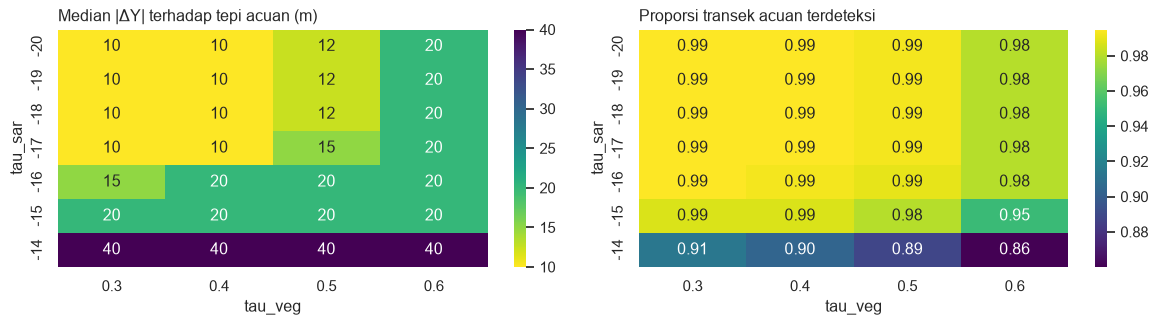

,tau_veg,tau_sar,terdeteksi,selisih_median_m,bias_m,dalam_30m
0,0.3,-20,0.995,10.0,10.0,0.865
1,0.3,-19,0.995,10.0,10.0,0.865
2,0.3,-18,0.995,10.0,10.0,0.865
3,0.3,-17,0.995,10.0,10.0,0.863
7,0.4,-20,0.995,10.0,10.0,0.865
10,0.4,-17,0.995,10.0,10.0,0.860
9,0.4,-18,0.995,10.0,10.0,0.865
8,0.4,-19,0.995,10.0,10.0,0.865


In [5]:
WC_Y, G21_Y, G25_Y = tepi_pertama(WC_M, jmax=JZ), tepi_pertama(GMW[:, :, kol(2021)], jmax=JZ), tepi_pertama(GMW[:, :, kol(2025)], jmax=JZ)
REF = DOMAIN & np.isfinite(WC_Y) & np.isfinite(G21_Y) & (np.abs(WC_Y - G21_Y) <= 30)
iR = np.flatnonzero(REF)

def zona_cari(iset):
    return DIST[None, :] <= BATAS[iset][:, None]

def teramati(iset, bl):
    Mz = zona_cari(iset)
    ok = np.isfinite(NDVI[iset][:, :, bl]) & np.isfinite(VH[iset][:, :, bl]) & Mz[:, :, None]
    return ok.sum(1) / Mz.sum(1)[:, None] >= PARAM["MINVALID"]

def deteksi(tv, ts, iset, bl=None):
    # tepi bulanan [n, bulan] (NaN = tidak ada tepi atau tidak teramati) dan status teramati [n, bulan]
    bl = np.arange(T) if bl is None else bl
    iy = TH_T[bl] - 2021
    M = (NDVI[iset][:, :, bl] > tv) & (VH[iset][:, :, bl] > ts) & ELIG[iset][:, :, iy] & EVER[iset][:, :, iy]
    M &= zona_cari(iset)[:, :, None]
    Y = np.stack([tepi_pertama(M[:, :, k], PARAM["RUN"]) for k in range(M.shape[2])], 1)
    obs = teramati(iset, bl)
    Y[~obs] = np.nan
    return Y, obs

bl21 = np.flatnonzero(TH_T == 2021)
kal = []
for tv in [0.3, 0.4, 0.5, 0.6]:
    for ts in [-20, -19, -18, -17, -16, -15, -14]:
        Y21, _ = deteksi(tv, ts, iR, bl21)
        ok = np.isfinite(Y21).sum(1) >= 3
        med = np.where(ok, np.nanmedian(Y21, 1), np.nan)
        d = med - WC_Y[iR]
        kal.append(dict(tau_veg=tv, tau_sar=ts, terdeteksi=ok.mean(), selisih_median_m=np.nanmedian(np.abs(d)),
                        bias_m=np.nanmedian(d), dalam_30m=np.nanmean(np.abs(d) <= 30)))
kal = pd.DataFrame(kal)
# aturan pilih: selisih median terkecil (terdeteksi >= 90%); di antara yang setara (proporsi dalam 30 m selisih <= 0,01),
# pilih ambang paling konservatif (τ_SAR lalu τ_veg tertinggi) supaya deteksi palsu paling sedikit
ok_ = kal[kal.terdeteksi >= 0.9]
terbaik = ok_[ok_.selisih_median_m == ok_.selisih_median_m.min()]
setara = terbaik[terbaik.dalam_30m >= terbaik.dalam_30m.max() - 0.01]
pilih = setara.sort_values(["tau_sar", "tau_veg"], ascending=False).iloc[0]
PARAM["TAU_VEG"], PARAM["TAU_SAR"] = float(pilih.tau_veg), float(pilih.tau_sar)
print(f"Transek acuan: {len(iR)}; ambang terpilih τ_veg = {PARAM['TAU_VEG']}, τ_SAR = {PARAM['TAU_SAR']} dB")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
sns.heatmap(kal.pivot(index="tau_sar", columns="tau_veg", values="selisih_median_m"), annot=True, fmt=".0f", cmap="viridis_r", ax=ax[0])
ax[0].set_title("Median |ΔY| terhadap tepi acuan (m)", loc="left")
sns.heatmap(kal.pivot(index="tau_sar", columns="tau_veg", values="terdeteksi"), annot=True, fmt=".2f", cmap="viridis", ax=ax[1])
ax[1].set_title("Proporsi transek acuan terdeteksi", loc="left")
plt.tight_layout(); simpan("03_kalibrasi"); plt.show()
tabel(kal.sort_values("selisih_median_m").head(8).round(3), "03_kalibrasi")

### 3.4 Tepi bulanan dan dua jenis kekosongan

$Y_{i,t}$ = `dist_m` titik pertama dari laut yang mengawali ≥ 3 titik berturut-turut yang lolos ambang, di dalam batas
pencarian. Nilai **naik = tepi mundur ke darat**. Setiap transek-bulan diberi status:

- **terukur**: zona pencarian teramati dan tepi ditemukan;
- **teramati, mangrove tidak ada**: zona teramati (≥ 80% titik punya NDVI dan VH) tetapi tidak ada tepi. Ini **kejadian**,
  bukan data hilang, dan ditangani terpisah (Bagian 4 dan 6);
- **tidak teramati**: awan atau tidak ada lintasan radar. Ini data hilang yang dilewati model.

Pencilan (lompatan deteksi sesaat) dibuang dengan filter Hampel (jendela 7 bulan, 3 MAD).

In [6]:
Y_raw, OBS = deteksi(PARAM["TAU_VEG"], PARAM["TAU_SAR"], iD)
ABSEN = OBS & np.isnan(Y_raw)

def hampel(Y, w=7, k=3.0):
    df = pd.DataFrame(Y.T)
    med = df.rolling(w, center=True, min_periods=3).median()
    mad = (df - med).abs().rolling(w, center=True, min_periods=3).median() * 1.4826
    out = ((df - med).abs() > k * mad.clip(lower=STEP)).to_numpy().T
    Y2 = Y.copy(); Y2[out] = np.nan
    return Y2, out

Y, PENCILAN = hampel(Y_raw)
st = pd.DataFrame({"wilayah": REG_D, "terukur": np.isfinite(Y).mean(1), "teramati_tanpa_mangrove": ABSEN.mean(1),
                   "tidak_teramati": (~OBS).mean(1), "pencilan": PENCILAN.mean(1)})
print(f"Transek-bulan domain: {ND * T:,}; terukur {np.isfinite(Y).mean():.0%}, teramati tanpa mangrove {ABSEN.mean():.1%}, "
      f"tidak teramati {(~OBS).mean():.0%}, pencilan dibuang {PENCILAN.mean():.1%}")
tabel(st.groupby("wilayah").mean().reindex(REG).round(3), "03_status_bulan")

Transek-bulan domain: 62,560; terukur 85%, teramati tanpa mangrove 6.1%, tidak teramati 8%, pencilan dibuang 1.8%


,terukur,teramati_tanpa_mangrove,tidak_teramati,pencilan
wilayah,,,,
PKL,0.616,0.195,0.158,0.031
SEM,0.777,0.112,0.088,0.023
CIR,0.763,0.142,0.082,0.014
SBY,0.897,0.021,0.066,0.016
JPR,0.792,0.002,0.149,0.057


### 3.5 Validasi independen posisi tepi

Tepi tahunan Sentinel (median bulan terukur) dibandingkan dengan tepi GMW **pada transek dan tahun yang tidak dipakai
kalibrasi**: 2021 pada transek non-acuan, dan 2025 pada semua transek domain. GMW beresolusi 30 m, jadi selisih ≤ 30 m
dianggap cocok.

In [7]:
def tepi_tahunan(Yb, y, minbulan=3):
    m = TH_T == y
    ok = np.isfinite(Yb[:, m]).sum(1) >= minbulan
    return np.where(ok, np.nanmedian(Yb[:, m], 1), np.nan)

YTH = np.stack([tepi_tahunan(Y, y) for y in TAHUN], 1)           # [ND, 6]
val = []
for nama, y_s, ref, pilih_k in [("2021 vs GMW 2021 (non-acuan)", YTH[:, 0], G21_Y[iD], ~REF[iD]),
                                 ("2021 vs WorldCover 2021 (non-acuan)", YTH[:, 0], WC_Y[iD], ~REF[iD]),
                                 ("2025 vs GMW 2025 (semua domain)", YTH[:, 4], G25_Y[iD], np.ones(ND, bool))]:
    b = pilih_k & np.isfinite(y_s) & np.isfinite(ref)
    d = y_s[b] - ref[b]
    val.append(dict(pembanding=nama, n=int(b.sum()), selisih_median_m=np.median(np.abs(d)), bias_m=np.median(d),
                    dalam_30m=np.mean(np.abs(d) <= 30), spearman=spearmanr(y_s[b], ref[b])[0]))
tabel(pd.DataFrame(val).set_index("pembanding").round(2), "03_validasi")

,n,selisih_median_m,bias_m,dalam_30m,spearman
pembanding,,,,,
2021 vs GMW 2021 (non-acuan),414,20.0,10.0,0.64,0.78
2021 vs WorldCover 2021 (non-acuan),199,70.0,-20.0,0.38,0.39
2025 vs GMW 2025 (semua domain),877,20.0,20.0,0.74,0.88


### 3.6 Penghalang keras $B^{hard}_{i,t}$

Penghalang keras tahun $y$ = titik darat pertama **di belakang tepi** berupa ≥ 2 titik berturut-turut dengan P(terbangun)
> τ_built, atau persilangan OSM (jalan, rel, tanggul, tol, termasuk ruas konstruksi) dan struktur baru dengan
`tahun_mulai` ≤ $y$. **[Penyesuaian]** Piksel terbangun Dynamic World hanya dihitung bila juga terbangun pada tahun
sebelum atau sesudahnya (menyaring kedipan kelas, masalah M11). Transek tanpa penghalang sampai ujung darat ditandai
**tersensor**. Untuk transek di luar domain, titik acuannya adalah garis pantai basis (500 m).

In [8]:
YREF = np.full((N, len(TAHUN)), float(LEN_SEA))
yd = pd.DataFrame(YTH).ffill(axis=1).bfill(axis=1).to_numpy()
awal = np.where(np.isfinite(G21_Y[iD]), G21_Y[iD], np.where(np.isfinite(WC_Y[iD]), WC_Y[iD], LEN_SEA))
YREF[iD] = np.where(np.isfinite(yd), yd, awal[:, None])
PSN = np.isin(IDS, BAR[BAR.jenis.str.contains("motorway|construction", na=False)].transek_id.unique())

def penghalang_keras(tau_built, yref):
    Hy = DW[..., 3] > tau_built
    prev = np.concatenate([np.zeros_like(Hy[..., :1]), Hy[..., :-1]], -1)
    nxt = np.concatenate([Hy[..., 1:], np.zeros_like(Hy[..., :1])], -1)
    Hy = Hy & (prev | nxt)
    Hy = Hy & np.concatenate([Hy[:, 1:], np.zeros_like(Hy[:, :1])], 1)
    B = np.full((N, len(TAHUN)), float(DIST[-1])); sens = np.ones((N, len(TAHUN)), bool)
    for a, y in enumerate(TAHUN):
        H = Hy[:, :, a].copy()
        br = BAR[BAR.tahun <= y]; H[br.i.to_numpy(), br.j.to_numpy()] = True
        H &= DIST[None, :] > yref[:, a][:, None]
        ada = H.any(1); B[:, a] = np.where(ada, H.argmax(1) * STEP, DIST[-1]); sens[:, a] = ~ada
    return B, sens

B_HARD, B_SENS = penghalang_keras(PARAM["TAU_BUILT"], YREF)
bh = pd.DataFrame({"wilayah": REG_I, "domain": DOMAIN, "jarak_2026_m": B_HARD[:, -1] - YREF[:, -1], "tersensor": B_SENS[:, -1],
                   "maju": (B_HARD[:, 0] - B_HARD[:, -1]) > 0})
tabel(bh.groupby(["domain", "wilayah"]).agg(transek=("tersensor", "size"), jarak_median_m=("jarak_2026_m", "median"),
                                            tersensor=("tersensor", "mean"), penghalang_maju_2021_2026=("maju", "mean")).round(2), "03_penghalang")

transek  jarak_median_m  tersensor  penghalang_maju_2021_2026
domain wilayah                                                               
False  CIR          260          3000.0       0.52                       0.20
       JPR          182           990.0       0.20                       0.26
       PKL          245           660.0       0.11                       0.25
       SBY          563           180.0       0.09                       0.28
       SEM          195          1520.0       0.35                       0.30
True   CIR          145          2550.0       0.44                       0.25
       JPR            8          2855.0       0.62                       0.00
       PKL           45          2380.0       0.38                       0.18
       SBY          602          1490.0       0.35                       0.22
       SEM          120          2690.0       0.57                       0.12

### 3.7 Tutupan lahan per titik, jendela hidroperiode, dan ruang peluang

**Jendela hidroperiode** = persentil 5–95 frekuensi genangan pada dataran pasang-surut 0–50 m di depan tepi transek
yang stabil (Bagian 3.5 notebook sebelumnya; radar tidak melihat genangan di bawah kanopi). **Tutupan lahan per titik**
(layer 2 dashboard) memakai GMW 2025, Dynamic World 2025–2026, dan pola pengelolaan tambak dari MNDWI bulanan:

| Label | Aturan |
|---|---|
| mangrove | GMW 2025 |
| terbangun / terbangun baru | terbangun 2025 dan 2026; *baru* bila tidak terbangun 2021 dan 2022 |
| tambak aktif | kandidat tambak (air ≥ 4 dari 6 tahun, di darat) yang dikeringkan ≥ 0,5 kali/th dan tidak mengikuti pasang |
| tambak tergenang | kandidat tambak yang jarang dikeringkan dan tidak mengikuti pasang (*indikasi* tidak dikelola) |
| tambak terhubung pasang | kandidat tambak yang airnya mengikuti pasang (`tide_coupling` > 0,05): pematang terbuka/jebol |
| tambak mulai bervegetasi | kandidat tambak tertutup yang NDVI-nya naik > 0,2 (2021→2026) |
| dataran lumpur | titik non-mangrove di depan garis pantai basis yang mengikuti pasang atau genangannya dalam jendela |
| perairan | air lain (laut, sungai) |
| sawah / vegetasi darat / lahan terbuka | kelas Dynamic World 2026 |

**Ruang peluang** di antara tepi (atau garis pantai basis) dan penghalang keras:
*siap* = dataran lumpur, tambak terhubung pasang/bervegetasi, atau lahan terbuka yang genangannya **dalam** jendela;
*perlu pengaturan air* = tambak non-aktif di luar jendela; *silvofishery* = tambak aktif.

In [9]:
# jendela hidroperiode
Y_lr = np.array([np.polyfit(np.flatnonzero(np.isfinite(y)) / 12, y[np.isfinite(y)], 1)[0] if np.isfinite(y).sum() > 24 else np.nan for y in Y])
depan = []
for k in np.flatnonzero(np.abs(Y_lr) < 5):
    i = iD[k]; y0 = YREF[i, -1]
    depan.append(INUND[i, (DIST >= y0 - 50) & (DIST < y0) & (TIDEC[i] > 0.05)])
depan = np.concatenate(depan); depan = depan[np.isfinite(depan)]
JENDELA = tuple(np.quantile(depan, [0.05, 0.95]))
print(f"Jendela hidroperiode: {JENDELA[0]:.2f} – {JENDELA[1]:.2f} ({depan.size} titik dataran pasang-surut di depan {np.sum(np.abs(Y_lr) < 5)} tepi stabil)")

# pola tambak
MANG25 = GMW[:, :, kol(2025)]
darat = (DIST >= LEN_SEA)[None, :]
BUILT = DOM == 3
KAND = darat & ((DOM == 0).sum(-1) >= 4) & ~(MANG25 | GMW[:, :, kol(2021)] | WC_M)
ii, jj = np.nonzero(KAND)
Mw = MNDWI[ii, jj, :]; Vw = np.isfinite(Mw)
prev = pd.DataFrame(np.where(Vw, (Mw > 0).astype(float), np.nan)).ffill(axis=1).shift(1, axis=1).to_numpy()
drain = (Vw & (Mw <= 0) & (prev == 1)).sum(1)                      # kejadian basah -> kering antar bulan teramati
drain_th = drain / np.maximum(Vw.sum(1) / 12, 0.5)
dndvi = NDVI_MED_Y[ii, jj, 5] - NDVI_MED_Y[ii, jj, 0]
tc = TIDEC[ii, jj]
pola = np.select([tc > 0.05, drain_th >= 0.5, dndvi > 0.2], ["tambak terhubung pasang", "tambak aktif", "tambak mulai bervegetasi"], "tambak tergenang")

LAHAN = np.full((N, P), "", dtype=object)
d26 = np.array(KELAS_DW)[DOM[:, :, 5]]
LAHAN[:] = np.select([d26 == "crops", np.isin(d26, ["trees", "floodveg"]), d26 == "bare", d26 == "water"],
                     ["sawah", "vegetasi darat", "lahan terbuka", "perairan"], "perairan")
laut_non = (DIST < LEN_SEA)[None, :] & ~MANG25 & np.isin(DOM[:, :, 5], [0, 4])
LAHAN[laut_non & ((TIDEC > 0.05) | ((INUND >= JENDELA[0]) & (INUND <= JENDELA[1])))] = "dataran lumpur"
LAHAN[ii, jj] = pola
BARU_BANGUN = ~BUILT[..., 0] & ~BUILT[..., 1] & BUILT[..., 4] & BUILT[..., 5]
LAHAN[BUILT[..., 4] & BUILT[..., 5]] = "terbangun"
LAHAN[BARU_BANGUN] = "terbangun baru"
LAHAN[MANG25] = "mangrove"
URUT_LAHAN = ["mangrove", "dataran lumpur", "tambak terhubung pasang", "tambak mulai bervegetasi", "tambak tergenang", "tambak aktif",
              "lahan terbuka", "sawah", "vegetasi darat", "terbangun", "terbangun baru", "perairan"]
komp = pd.DataFrame({r: pd.Series(LAHAN[REG_I == r].ravel()).value_counts(normalize=True) for r in REG}).T.reindex(columns=URUT_LAHAN).fillna(0)
display(tabel(komp.round(3), "03_komposisi_lahan"))

# ruang peluang per transek (antara acuan tepi/garis pantai dan penghalang keras 2026)
DALAM_J = (INUND >= JENDELA[0]) & (INUND <= JENDELA[1])
SIAP = np.isin(LAHAN, ["dataran lumpur", "tambak terhubung pasang", "tambak mulai bervegetasi", "lahan terbuka"]) & DALAM_J
PERLU_AIR = np.isin(LAHAN, ["tambak terhubung pasang", "tambak mulai bervegetasi", "tambak tergenang"]) & ~DALAM_J
SILVO = LAHAN == "tambak aktif"
TAMBAK = np.isin(LAHAN, ["tambak aktif", "tambak tergenang", "tambak terhubung pasang", "tambak mulai bervegetasi"])
belakang = (DIST[None, :] > YREF[:, -1][:, None]) & (DIST[None, :] < B_HARD[:, -1][:, None])
depan_m = DIST[None, :] < YREF[:, -1][:, None]
OPP_SIAP = (SIAP & belakang).sum(1) * STEP; OPP_AIR = (PERLU_AIR & belakang).sum(1) * STEP; OPP_SILVO = (SILVO & belakang).sum(1) * STEP
LUMPUR_DEPAN = ((LAHAN == "dataran lumpur") & depan_m).sum(1) * STEP
OPP = OPP_SIAP + OPP_AIR
HYD = np.where(OPP > 0, OPP_SIAP / np.maximum(OPP, 1), 0.0)
nt = (TAMBAK & belakang).sum(1)
SIAP_TAMBAK = np.where(nt > 0, (np.isin(LAHAN, ["tambak terhubung pasang", "tambak mulai bervegetasi", "tambak tergenang"]) & belakang).sum(1) / np.maximum(nt, 1), 0.0)
# penghalang fungsional (skenario): tambak berpematang yang masih dikelola/tertutup, atau penghalang keras
tutup = np.isin(LAHAN, ["tambak aktif", "tambak tergenang"]) & (DIST[None, :] > YREF[:, -1][:, None])
B_FUNC = np.minimum(np.where(tutup.any(1), tutup.argmax(1) * STEP, DIST[-1]), B_HARD[:, -1])
ringkas = pd.DataFrame({"wilayah": REG_I, "domain": DOMAIN, "peluang_siap_m": OPP_SIAP, "perlu_pengaturan_air_m": OPP_AIR,
                        "silvofishery_m": OPP_SILVO, "lumpur_depan_m": LUMPUR_DEPAN, "tambak_nonaktif": SIAP_TAMBAK})
tabel(ringkas.groupby(["domain", "wilayah"]).median().round(2), "03_ruang_peluang")

Jendela hidroperiode: 0.04 – 0.81 (998 titik dataran pasang-surut di depan 470 tepi stabil)


,mangrove,dataran lumpur,tambak terhubung pasang,tambak mulai bervegetasi,tambak tergenang,tambak aktif,lahan terbuka,sawah,vegetasi darat,terbangun,terbangun baru,perairan
PKL,0.015,0.011,0.049,0.007,0.107,0.050,0.001,0.241,0.198,0.147,0.008,0.167
SEM,0.073,0.058,0.101,0.023,0.211,0.070,0.003,0.041,0.127,0.148,0.016,0.130
CIR,0.042,0.029,0.112,0.015,0.131,0.130,0.002,0.134,0.130,0.129,0.007,0.140
SBY,0.082,0.103,0.061,0.005,0.068,0.036,0.005,0.045,0.300,0.230,0.008,0.057
JPR,0.006,0.104,0.018,0.002,0.016,0.025,0.002,0.224,0.278,0.257,0.009,0.059


peluang_siap_m  perlu_pengaturan_air_m  silvofishery_m  lumpur_depan_m  tambak_nonaktif
domain wilayah                                                                                         
False  CIR               290.0                   100.0           295.0            90.0             0.58
       JPR                 0.0                    10.0            10.0           405.0             0.39
       PKL                10.0                    30.0            70.0            30.0             0.57
       SBY                 0.0                    10.0            10.0           410.0             0.25
       SEM               120.0                   150.0           100.0           210.0             0.78
True   CIR               290.0                   130.0           230.0            70.0             0.67
       JPR                90.0                   675.0            40.0           435.0             0.90
       PKL               190.0                   300.0           120.0            20.0             0.81
       SBY                85.0                    45.0            50.0           390.0             0.65
       SEM               220.0                   335.0           110.0           130.0             0.87

**Interpretasi.**

- **Domain naik dari 702 menjadi 920 transek**: SBY 602, CIR 145, SEM 120, PKL 45, JPR 8. Kenaikan terbesar ada di CIR
  (40 → 145) dan PKL (17 → 45), tempat WorldCover banyak melewatkan tegakan. Sebanyak 291 transek hanya bermangrove di peta
  (tidak terkonfirmasi Sentinel), dan 41 transek hilang sebelum 2021.
- **Batas pencarian** sekarang lebih jauh ke darat daripada batas lama pada 58% transek domain, sehingga tepi yang mundur
  di dalam sabuk historis tetap terukur.
- **Kalibrasi**: di bawah −17 dB, ambang VH hampir tidak berpengaruh, karena syarat kelas Dynamic World dan hijau sepanjang tahun
  sudah menyaring. Semua kombinasi terbaik memberi selisih median 10 m terhadap tepi acuan. Dipilih yang paling konservatif:
  **τ_veg = 0,4 dan τ_SAR = −17 dB**.
- **Validasi independen**: tepi Sentinel 2025 berselisih median **20 m** dari GMW 2025 (74% dalam 30 m, ρ = 0,88), dan tepi
  2021 pada transek non-acuan 20 m dari GMW 2021. Pada transek yang sama, selisih dengan WorldCover 70 m. Artinya, ketika
  kedua peta berselisih, sinyal Sentinel berpihak pada GMW.
- **Dua jenis kekosongan (radar multi-orbit)**: **85%** transek-bulan terukur (sebelumnya 61% dengan satu orbit), **6,1%
  teramati tetapi tanpa mangrove** (PKL 19,5%, CIR 14%, SEM 11%), dan hanya **8% tidak teramati** (SBY turun dari 40% ke 6,6%).
- **Lahan**: tambak tidak dikelola intensif (tergenang, terhubung pasang, bervegetasi) mendominasi di belakang tegakan SEM
  dan CIR. Ruang peluang *siap* (dalam jendela hidroperiode) median 290 m di CIR dan 190 m di PKL.

## 4. Dinamika mangrove dan laju jangka panjang (GMW)

### 4.1 Dinamika per titik dan per transek (layer 1 dashboard)

Setiap titik diberi status 2021 → 2025 dari GMW: **stabil**, **ekspansi**, **hilang**, **hilang sebelum 2021**
(bermangrove di tahun mana pun 2000–2020, tidak lagi 2021 maupun 2025), atau **tidak pernah**. Ekspansi dan kehilangan
dianggap **terkonfirmasi** bila sinyal Sentinel bergerak searah: NDVI naik (turun) > 0,2 atau VH naik (turun) > 1,5 dB
antara 2021 dan 2025. Status transek diturunkan dari jumlah titik terkonfirmasi (≥ 3 titik = 30 m).

In [10]:
nd21, nd25 = NDVI_MED_Y[:, :, 0], NDVI_MED_Y[:, :, 4]
vh21, vh25 = VH_MED_Y[:, :, 0], VH_MED_Y[:, :, 4]
naik = ((nd25 - nd21) > 0.2) | ((vh25 - vh21) > 1.5)
turun = ((nd21 - nd25) > 0.2) | ((vh21 - vh25) > 1.5)
G21, G25 = GMW[:, :, kol(2021)], GMW[:, :, kol(2025)]
G_HIST = GMW[:, :, kol(2000): kol(2020) + 1].any(-1)
DIN_TITIK = np.select([G21 & G25, G25 & ~G21, G21 & ~G25, G_HIST & ~G21 & ~G25],
                      ["stabil", "ekspansi", "hilang", "hilang sebelum 2021"], "tidak pernah").astype(object)
KONF_TITIK = np.where(DIN_TITIK == "ekspansi", naik, np.where(DIN_TITIK == "hilang", turun, True))
zona = ZONA & np.ones((N, 1), bool)
n_eksp = ((DIN_TITIK == "ekspansi") & KONF_TITIK & zona).sum(1)
n_hil = ((DIN_TITIK == "hilang") & KONF_TITIK & zona).sum(1)
DINAMIKA = np.select(
    [STATUS_PETA == "hilang sebelum 2021", ~PETA_2125, ~TERKONF, (n_hil >= 3) & (n_hil >= n_eksp), n_eksp >= 3],
    ["hilang sebelum 2021", "tidak pernah bermangrove", "peta saja (tidak terkonfirmasi)", "kehilangan 2021–2025", "ekspansi 2021–2025"],
    "stabil").astype(object)
LEBAR = GMW[:, :JZ, :].sum(1) * STEP                                 # lebar sabuk GMW (m) [N, 41]
dt = pd.DataFrame({"wilayah": REG_I, "dinamika": DINAMIKA, "dlebar": LEBAR[:, kol(2025)] - LEBAR[:, kol(2021)]})
din_tab = pd.crosstab(dt.wilayah, dt.dinamika).reindex(REG)
din_tab["perubahan_lebar_total_km"] = dt.groupby("wilayah").dlebar.sum().reindex(REG) / 1000
print(f"Konfirmasi Sentinel: ekspansi {np.mean(KONF_TITIK[(DIN_TITIK == 'ekspansi') & zona]):.0%}, "
      f"hilang {np.mean(KONF_TITIK[(DIN_TITIK == 'hilang') & zona]):.0%} titik (0–1.500 m)")
tabel(din_tab, "04_dinamika_transek")

Konfirmasi Sentinel: ekspansi 71%, hilang 73% titik (0–1.500 m)


dinamika,ekspansi 2021–2025,hilang sebelum 2021,kehilangan 2021–2025,peta saja (tidak terkonfirmasi),stabil,tidak pernah bermangrove,perubahan_lebar_total_km
wilayah,,,,,,,
PKL,16,1,4,39,25,205,7.30
SEM,61,14,24,79,35,102,14.14
CIR,95,4,11,82,39,174,20.34
SBY,252,17,45,85,305,461,44.66
JPR,0,5,0,6,8,171,0.37


### 4.2 Laju jangka panjang tepi dan lebar sabuk (GMW 2015–2025)

Per transek domain dihitung dua laju dengan penduga **Theil–Sen** (median kemiringan antar pasangan tahun; tahan
pencilan dan lompatan piksel 30 m), beserta selang 95%-nya:

- $v^{GMW}_i$: laju **tepi laut** (m/th, + = mundur ke darat), dari tahun-tahun ketika tepi ada;
- $w^{GMW}_i$: laju **lebar sabuk** (m/th, − = menyempit). Tahun tanpa mangrove bernilai lebar 0, sehingga kehilangan
  total ikut terhitung. Ini menutup celah $v$, yang hanya terukur selama tegakan masih ada.

Periode 2015–2025 dipilih karena berada di era Sentinel-2 dan mencakup periode InSAR (2017–2023).

In [11]:
l0, l1 = PARAM["GMW_LAJU"]
th = np.arange(l0, l1 + 1)
GE = np.stack([tepi_pertama(GMW[:, :, kol(y)], jmax=JZ) for y in th], 1)       # tepi laut GMW [N, tahun]
def sen(y, x=th, minn=6):
    ok = np.isfinite(y)
    if ok.sum() < minn or np.ptp(y[ok]) == 0 and ok.sum() >= minn:
        return (0.0, 0.0, 0.0) if ok.sum() >= minn else (np.nan, np.nan, np.nan)
    s, _, lo, hi = stats.theilslopes(y[ok], x[ok], 0.95)
    return s, lo, hi
V_GMW = np.array([sen(GE[i]) for i in range(N)])                               # [N, 3] (laju, bawah, atas)
W_GMW = np.array([sen(LEBAR[i, kol(l0): kol(l1) + 1].astype(float)) for i in range(N)])
lj = pd.DataFrame({"wilayah": REG_D, "v": V_GMW[iD, 0], "v_sig": (V_GMW[iD, 1] > 0) | (V_GMW[iD, 2] < 0),
                   "w": W_GMW[iD, 0], "w_sig": (W_GMW[iD, 1] > 0) | (W_GMW[iD, 2] < 0)})
lj_tab = lj.groupby("wilayah").agg(transek=("v", "size"), v_median=("v", "median"), v_mundur_sig=("v", lambda s: ((s > 0) & lj.loc[s.index, "v_sig"]).mean()),
                                   v_maju_sig=("v", lambda s: ((s < 0) & lj.loc[s.index, "v_sig"]).mean()),
                                   w_median=("w", "median"), w_menyempit_sig=("w", lambda s: ((s < 0) & lj.loc[s.index, "w_sig"]).mean()),
                                   w_melebar_sig=("w", lambda s: ((s > 0) & lj.loc[s.index, "w_sig"]).mean())).reindex(REG)
print(f"Lebar selang 95% laju tepi GMW: median {np.nanmedian(V_GMW[iD, 2] - V_GMW[iD, 1]):.1f} m/th "
      f"(pembanding: simpangan laju Sentinel 5,7 tahun ±20 m/th)")
tabel(lj_tab.round(2), "04_laju_gmw")

Lebar selang 95% laju tepi GMW: median 5.0 m/th (pembanding: simpangan laju Sentinel 5,7 tahun ±20 m/th)


,transek,v_median,v_mundur_sig,v_maju_sig,w_median,w_menyempit_sig,w_melebar_sig
wilayah,,,,,,,
PKL,45,0.0,0.02,0.00,7.14,0.00,0.27
SEM,120,0.0,0.05,0.00,8.33,0.04,0.39
CIR,145,0.0,0.00,0.08,8.75,0.00,0.38
SBY,602,0.0,0.01,0.15,6.67,0.01,0.38
JPR,8,0.0,0.00,0.00,0.00,0.00,0.12


### 4.3 Kejadian kehilangan total (panel GMW)

Untuk model dua bagian (Bagian 6), setiap transek-tahun 2017–2025 yang **bermangrove pada tahun sebelumnya** menjadi
satu pengamatan. **Kejadian** = mangrove tidak ada pada tahun itu **dan** tahun berikutnya (bila tersedia), supaya satu
tahun yang salah klasifikasi tidak terhitung sebagai kehilangan.

In [12]:
panel = []
for y in range(2017, 2026):
    prev, now = ADA_GMW[:, kol(y - 1)], ADA_GMW[:, kol(y)]
    nxt = ADA_GMW[:, kol(y + 1)] if y < 2025 else now
    for i in np.flatnonzero(prev):
        panel.append((i, y, int(~now[i] & ~nxt[i])))
PANEL = pd.DataFrame(panel, columns=["i", "tahun", "hilang"])
PANEL["wilayah"] = REG_I[PANEL.i]
print(f"Panel: {len(PANEL):,} transek-tahun, {PANEL.hilang.sum()} kejadian kehilangan total di {PANEL[PANEL.hilang == 1].i.nunique()} transek")
tabel(PANEL.groupby("wilayah").agg(transek_tahun=("hilang", "size"), kejadian=("hilang", "sum"), laju_per_1000=("hilang", lambda s: 1000 * s.mean())).reindex(REG).round(1), "04_panel_kehilangan")

Panel: 8,673 transek-tahun, 76 kejadian kehilangan total di 76 transek


,transek_tahun,kejadian,laju_per_1000
wilayah,,,
PKL,415,2,4.8
SEM,1402,24,17.1
CIR,1207,12,9.9
SBY,5573,36,6.5
JPR,76,2,26.3


**Interpretasi.**

- **Ekspansi jauh lebih banyak daripada kehilangan.** Ada **424 transek berekspansi** dan **84 transek kehilangan tegakan**
  (2021–2025). 71–73% titik yang berubah terkonfirmasi sinyal Sentinel. Lebar total sabuk bertambah: SBY +44,7 km, CIR +20,3 km,
  SEM +14,1 km, PKL +7,3 km (jumlah lebar semua transek).
- **Laju jangka panjang GMW jauh lebih presisi**: selang 95% median **±5 m/th**, dibanding ±20 m/th dari 5,7 tahun Sentinel.
  Median laju tepi laut 0 di semua wilayah, tetapi **lebar sabuk bertambah** 6,7–8,8 m/th. 27–39% transek melebar secara
  signifikan, dan hanya 0–4% yang menyempit signifikan (tertinggi SEM, 4%). Pertumbuhan terjadi ke arah darat dan ke celah,
  bukan dengan tepi laut maju.
- **Kehilangan total** (tegakan hilang dua tahun berturut-turut): 76 kejadian dalam 8.673 transek-tahun. Laju tertinggi di
  **SEM (17 per 1.000)**, 2–3 kali SBY (6,5) dan PKL (4,8). JPR tinggi secara relatif (26), tetapi hanya dari 2 kejadian.

### 4.4 Gambaran perubahan kawasan per tahun (contoh per wilayah)

Sebagai gambaran visual, setiap wilayah diwakili satu **ruas pantai sekitar 10 km** (40 transek bersambung) dengan perubahan
terbanyak 2021→2025, yaitu titik mangrove yang muncul atau hilang (terkonfirmasi Sentinel) ditambah titik yang menjadi
bangunan. Ruas yang memuat ≥ 10 transek bermangrove diutamakan. Setiap titik sampel
(10 m sepanjang transek × jarak antartransek 250 m ≈ 0,25 ha) diberi kelas tahunan:

- **mangrove**: GMW tahun itu;
- selebihnya kelas dominan Dynamic World tahun itu: air di depan garis pantai basis = **laut**, air di belakangnya =
  **tambak/air darat** (termasuk sungai dan tambak yang sudah tergenang laut), **permukiman/terbangun**, **sawah**,
  **vegetasi lain**, dan **lahan terbuka/lumpur**.

Grafik di kanan: luas mangrove GMW 1990–2025 di ruas yang sama, dengan perubahan luas tambak/air darat, permukiman, dan
sawah 2021→2025 (Dynamic World) di kotak teks. Luas adalah perkiraan dari
sampel transek (0–1.500 m ke darat), bukan pemetaan penuh. Koordinat pusat ruas ditulis di judul grafik supaya lokasinya
bisa dibuka di Google Earth.

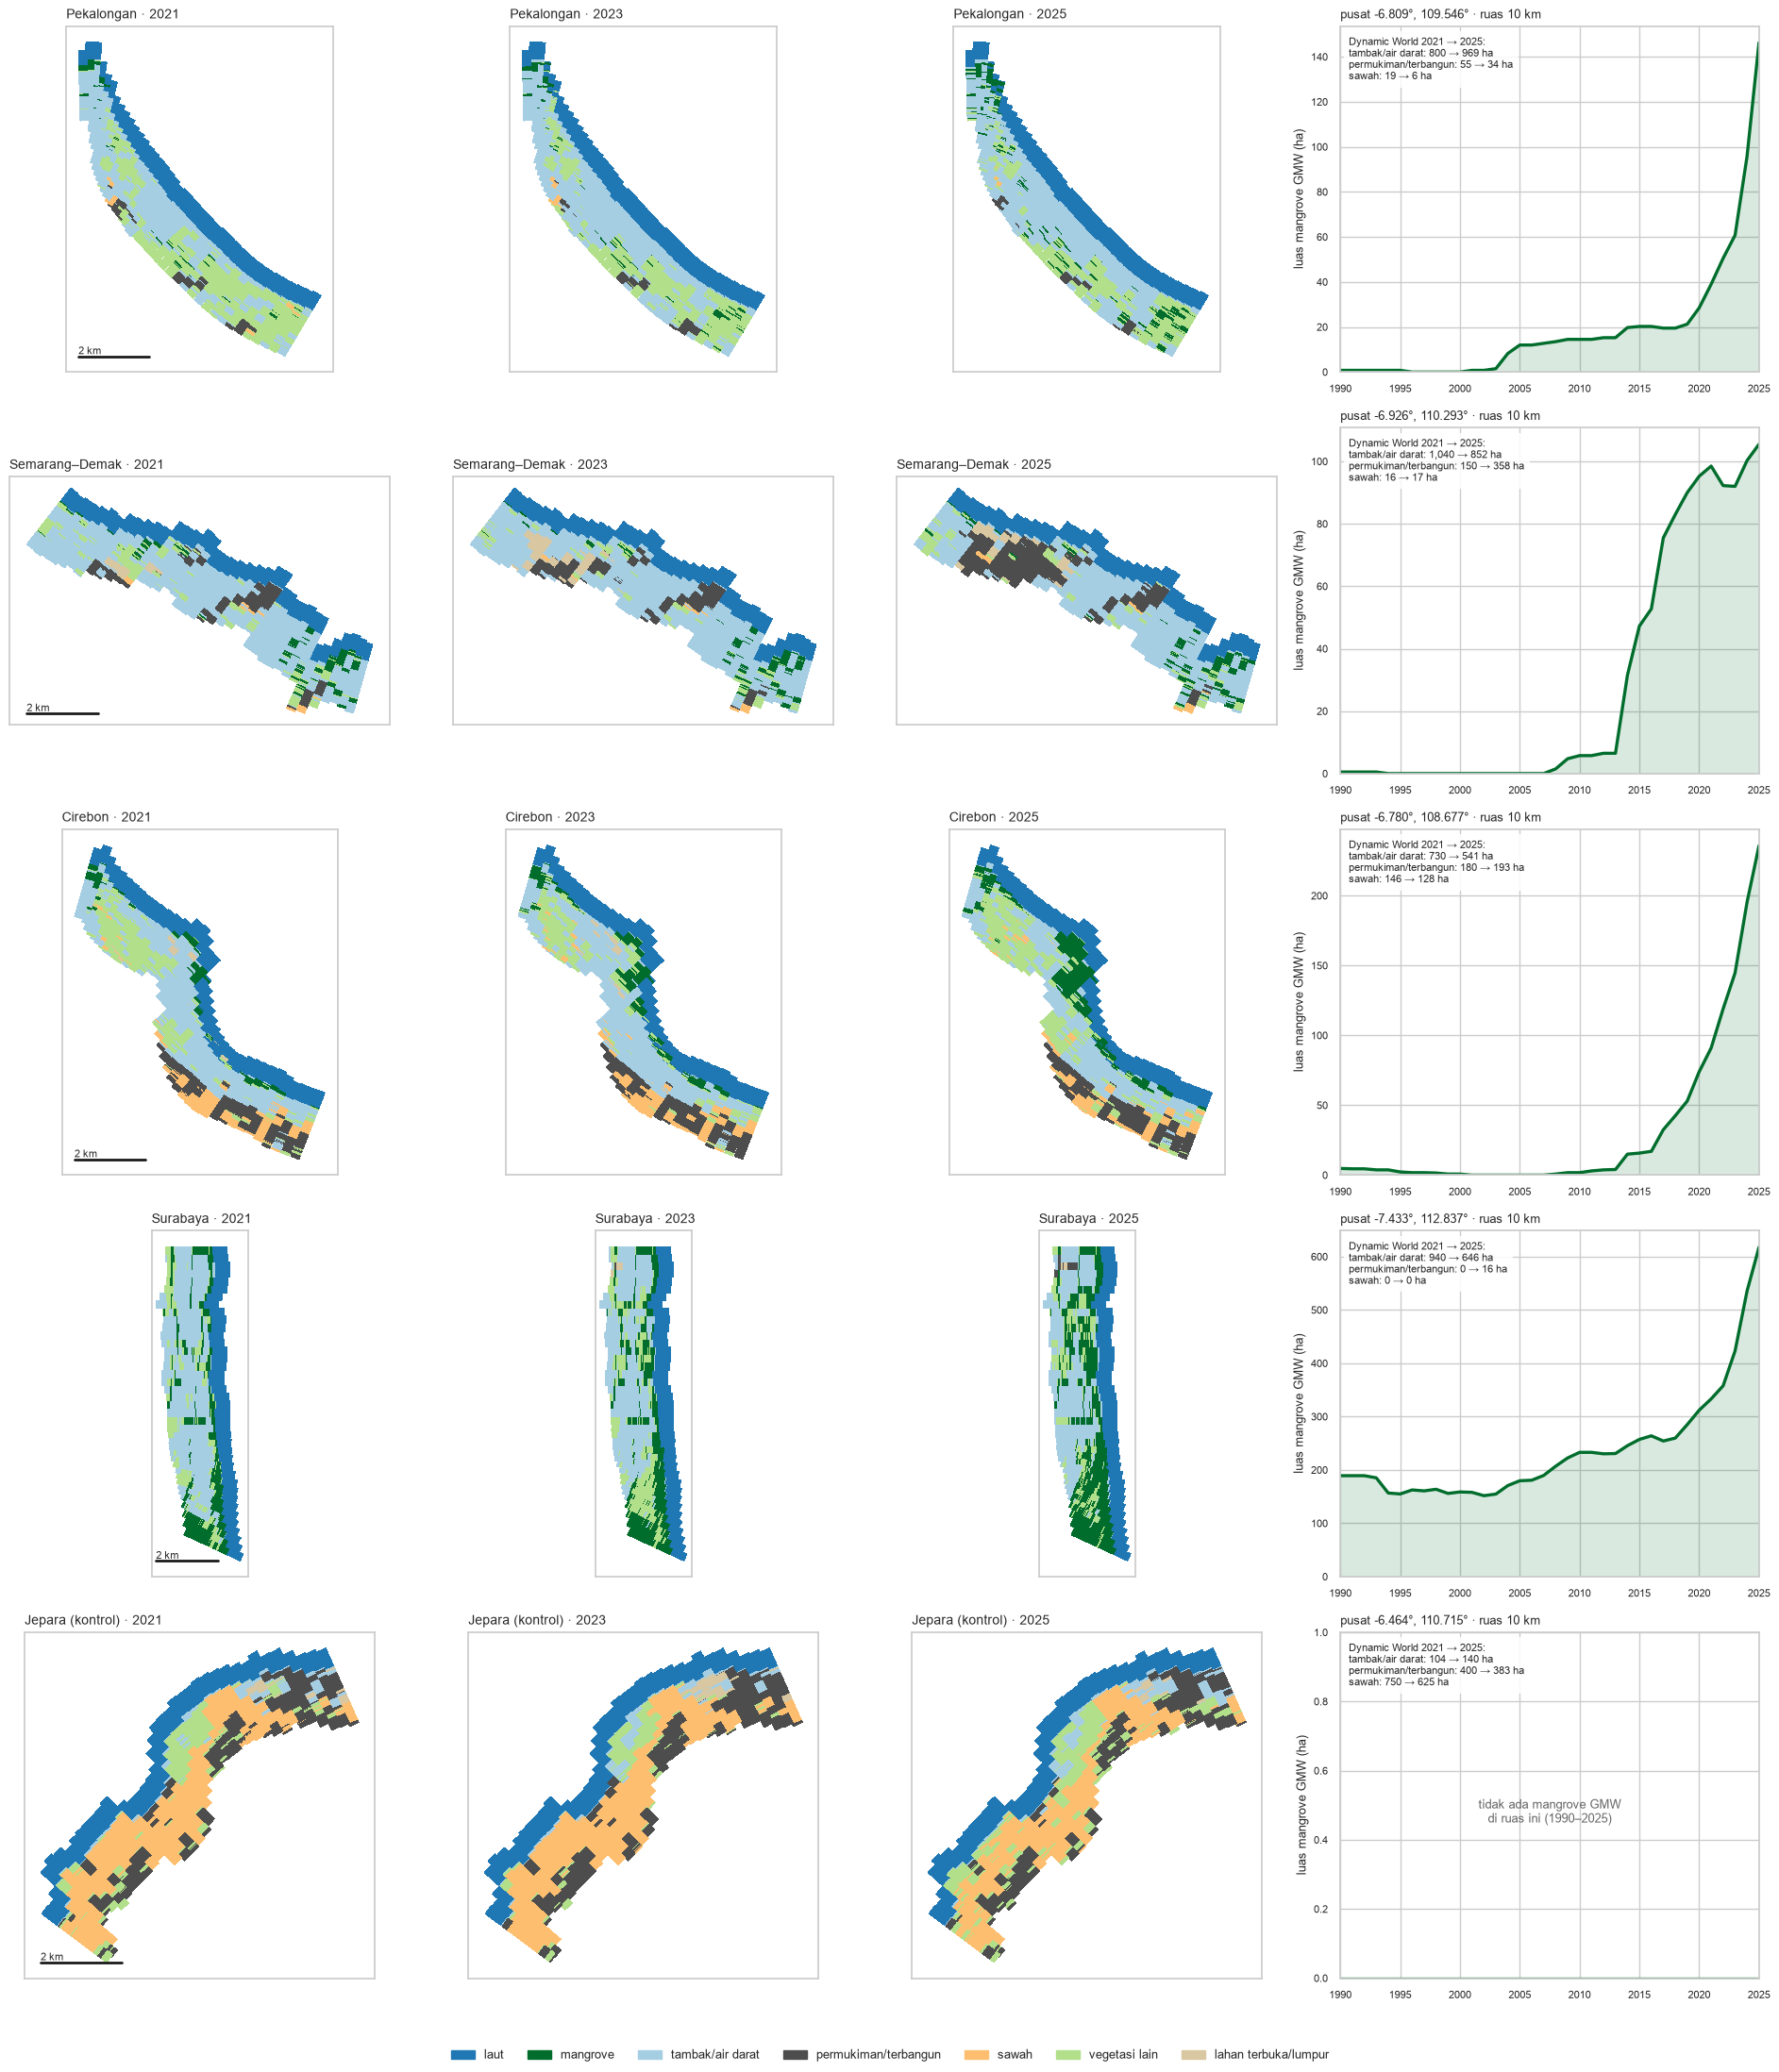

,transek,pusat_lat,pusat_lon,mangrove 1990 (ha),mangrove 2000 (ha),mangrove 2010 (ha),mangrove 2021 (ha),mangrove 2025 (ha),tambak/air darat 2021 → 2025 (ha),permukiman/terbangun 2021 → 2025 (ha),sawah 2021 → 2025 (ha)
wilayah,,,,,,,,,,,
Pekalongan,TRS_PKL_0138 – TRS_PKL_0177,-6.809,109.546,1,0,14,39,146,800 → 969,55 → 34,19 → 6
Semarang–Demak,TRS_SEM_0210 – TRS_SEM_0249,-6.926,110.293,0,0,6,98,106,1040 → 852,150 → 358,16 → 17
Cirebon,TRS_CIR_0187 – TRS_CIR_0226,-6.780,108.677,5,1,2,91,236,730 → 541,180 → 193,146 → 128
Surabaya,TRS_SBY_0015 – TRS_SBY_0054,-7.433,112.837,189,159,233,333,618,940 → 646,0 → 16,0 → 0
Jepara (kontrol),TRS_JPR_0043 – TRS_JPR_0082,-6.464,110.715,0,0,0,0,0,104 → 140,400 → 383,750 → 625


In [13]:
# kelas tutupan tahunan per titik: mangrove dari GMW tahun itu, sisanya kelas dominan Dynamic World
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
KLS_TH = ["laut", "mangrove", "tambak/air darat", "permukiman/terbangun", "sawah", "vegetasi lain", "lahan terbuka/lumpur"]
WARNA_TH = dict(zip(KLS_TH, ["#1f78b4", "#006d2c", "#a6cee3", "#4d4d4d", "#fdbf6f", "#b2df8a", "#d8c7a0"]))
JV = 2000 // STEP + 1                                            # 500 m laut + 1.500 m darat
TH_V = [2021, 2022, 2023, 2024, 2025]
def kelas_tahun(y):
    d = DOM[:, :JV, list(TAHUN).index(y)]
    laut = (DIST[:JV] < LEN_SEA)[None, :]
    return np.select([GMW[:, :JV, kol(y)], (d == 0) & laut, d == 0, d == 3, d == 2, np.isin(d, [1, 5])],
                     [1, 0, 2, 3, 4, 5], 6).astype(np.int8)
KV = np.stack([kelas_tahun(y) for y in TH_V], -1)                # [N, JV, 5]
k21, k25 = KV[..., 0], KV[..., -1]

# ruas contoh: 40 transek bersambung (jarak pusat <= 1 km) dengan perubahan mangrove terkonfirmasi + bangunan baru terbanyak
W_RUAS = 40
cxy_ = TR[["cx", "cy"]].to_numpy()
sambung = np.r_[(REG_I[1:] == REG_I[:-1]) & (np.hypot(*(cxy_[1:] - cxy_[:-1]).T) <= 1000), False]
berubah = np.isin(DIN_TITIK[:, :JV], ["ekspansi", "hilang"]) & KONF_TITIK[:, :JV]
skor_t = berubah.sum(1) + ((k25 == 3) & (k21 != 3)).sum(1)
cs, cl, nd_ = np.r_[0, np.cumsum(skor_t)], np.r_[0, np.cumsum(~sambung)], np.r_[0, np.cumsum(DOMAIN)]
CONTOH = {}
for r in REG:
    for w_ in (W_RUAS, W_RUAS // 2):
        for syarat in (10, 0):                                   # utamakan ruas dengan >= 10 transek bermangrove
            kand = [(cs[i + w_] - cs[i], i) for i in np.flatnonzero(REG_I == r)
                    if i + w_ <= N and cl[i + w_ - 1] - cl[i] == 0 and nd_[i + w_] - nd_[i] >= syarat]
            if kand:
                break
        if kand:
            CONTOH[r] = np.arange(max(kand)[1], max(kand)[1] + w_); break

def petak(ii):
    # petak 10 m (sepanjang transek) x 250 m (antartransek) per titik, koordinat UTM dalam km
    t_ = TR.iloc[ii]; u = t_[["ux", "uy"]].to_numpy()[:, None, :]; v = np.stack([-u[..., 1], u[..., 0]], -1)
    c = (t_[["cx", "cy"]].to_numpy() - LEN_SEA * t_[["ux", "uy"]].to_numpy())[:, None, :] + DIST[:JV][None, :, None] * u
    sudut = [c + s1 * STEP / 2 * u + s2 * 125 * v for s1, s2 in [(-1, -1), (1, -1), (1, 1), (-1, 1)]]
    return np.stack(sudut, -2).reshape(-1, 4, 2) / 1000

HA = 250 * STEP / 1e4                                            # ha per titik sampel
warna_arr = np.array(list(WARNA_TH.values()))
LAT_V = TR.lat.to_numpy(); LON_V = TR.lon.to_numpy()
fig, axs = plt.subplots(len(CONTOH), 4, figsize=(19, 4.4 * len(CONTOH)), gridspec_kw={"width_ratios": [1, 1, 1, 1.1]})
rows = []
for a_, (r, ii) in zip(axs, CONTOH.items()):
    pg = petak(ii)
    for a, y in zip(a_[:3], [2021, 2023, 2025]):
        a.add_collection(PolyCollection(pg, facecolors=warna_arr[KV[ii, :, TH_V.index(y)].ravel()], edgecolors="none", antialiased=False, rasterized=True))
        a.autoscale(); a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
        a.set_title(f"{REG_NAMA[r]} · {y}", loc="left", fontsize=10)
    a_[0].plot([pg[..., 0].min(), pg[..., 0].min() + 2], [pg[..., 1].min()] * 2, color="k", lw=2)
    a_[0].text(pg[..., 0].min(), pg[..., 1].min(), "2 km", fontsize=8, va="bottom")
    ax = a_[3]; g_ = GMW[ii, :JV, :].sum((0, 1)) * HA
    ax.plot(TAHUN_GMW, g_, color=WARNA_TH["mangrove"], lw=2.4)
    ax.fill_between(TAHUN_GMW, 0, g_, color=WARNA_TH["mangrove"], alpha=0.15)
    if g_.max() == 0:
        ax.set_ylim(0, 1); ax.text(0.5, 0.45, "tidak ada mangrove GMW\ndi ruas ini (1990–2025)", transform=ax.transAxes, ha="center", fontsize=9, color="0.4")
    ax.set_xlim(1990, 2025); ax.set_ylim(bottom=0); ax.set_ylabel("luas mangrove GMW (ha)", fontsize=9); ax.tick_params(labelsize=8)
    ax.set_title(f"pusat {LAT_V[ii].mean():.3f}°, {LON_V[ii].mean():.3f}° · ruas {len(ii) * 0.25:.0f} km", loc="left", fontsize=9)
    teks = "Dynamic World 2021 → 2025:\n" + "\n".join(f"{KLS_TH[kk]}: {(k21[ii] == kk).sum() * HA:,.0f} → {(k25[ii] == kk).sum() * HA:,.0f} ha"
                                                      for kk in [2, 3, 4])
    ax.text(0.02, 0.97, teks, transform=ax.transAxes, va="top", fontsize=8, bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))
    row = {"wilayah": REG_NAMA[r], "transek": f"{IDS[ii[0]]} – {IDS[ii[-1]]}", "pusat_lat": round(LAT_V[ii].mean(), 4),
           "pusat_lon": round(LON_V[ii].mean(), 4)}
    row.update({f"mangrove {y} (ha)": round(g_[kol(y)]) for y in (1990, 2000, 2010, 2021, 2025)})
    for kk in [2, 3, 4]:
        row[f"{KLS_TH[kk]} 2021 → 2025 (ha)"] = f"{(k21[ii] == kk).sum() * HA:.0f} → {(k25[ii] == kk).sum() * HA:.0f}"
    rows.append(row)
fig.legend(handles=[Patch(color=c, label=k) for k, c in WARNA_TH.items()], loc="lower center", ncol=7, fontsize=9, frameon=False)
plt.tight_layout(rect=(0, 0.025, 1, 1)); simpan("04_gambaran_kawasan"); plt.show()
tabel(pd.DataFrame(rows).set_index("wilayah"), "04_gambaran_kawasan")

**Interpretasi: gambaran kawasan.** Keempat ruas bermangrove menunjukkan pola yang sama: **mangrove tumbuh di lanskap tambak**,
dan kawasan di belakangnya menentukan apakah pertumbuhan itu bisa berlanjut.

- **Cirebon (−6,780°, 108,677°)**: mangrove hampir nol sampai 2013, lalu naik ke 91 ha (2021) dan **236 ha (2025)**.
  Pertumbuhannya mengisi tambak (tambak/air darat 730 → 541 ha). Di belakangnya ada sawah dan permukiman yang tetap
  (180 → 193 ha), sehingga ruang tumbuh ke darat terbatas pada lajur tambak.
- **Sidoarjo (−7,433°, 112,837°)**: sabuk tertua dan terluas, 189 ha (1990) → 333 ha (2021) → **618 ha (2025)**, tumbuh ke
  arah tambak (940 → 646 ha) tanpa tekanan bangunan. Pantai Sidoarjo menerima lumpur dari Porong dan Brantas; laju
  sedimentasi di muara Porong termasuk yang tertinggi yang pernah diukur di Indonesia (Sidik dkk., 2016).
- **Semarang (−6,926°, 110,293°)**: mangrove muncul sejak 2008 dan stagnan sekitar 100 ha sejak 2020. Dalam
  periode yang sama, **permukiman/terbangun naik 150 → 358 ha** di atas bekas tambak (1.040 → 852 ha). Ini gambaran
  coastal squeeze dari sisi darat: ruang di belakang tegakan berubah menjadi bangunan.
- **Pekalongan (−6,809°, 109,546°)**: GMW mencatat lonjakan 39 → 146 ha (2021–2025), tetapi pertumbuhan GMW di PKL hanya
  lemah terkonfirmasi Sentinel (notebook eksplorasi Bagian 5), jadi angka ini perlu dibaca hati-hati. Luas air di belakang
  pantai naik (800 → 969 ha), sejalan dengan amblesan tinggi di wilayah ini.
- **Jepara (kontrol)**: tidak ada mangrove. Pantainya langsung berbatasan dengan sawah dan permukiman, sehingga tidak ada
  sabuk yang bisa terhimpit.

Luas kelas Dynamic World berfluktuasi antartahun (misalnya sawah Jepara), jadi yang dibaca adalah arah perubahan dan pola
spasialnya, bukan angka hektar per tahun.

## 5. Nowcast dan forecast tepi mangrove

### 5.1 Perbandingan tiga model state-space

Versi sebelumnya memakai *local linear trend* (LLT) dan menghasilkan derau level $\sigma_\eta \approx 25$ m/bulan.
Artinya, tepi "berjalan acak" 25 m setiap bulan, yang tidak masuk akal secara fisik. Kemungkinan penyebabnya adalah galat
deteksi yang **bertahan beberapa bulan** (musim, genangan) sehingga terbaca sebagai gerak tepi. Tiga model dibandingkan
(parameter diestimasi dengan *maximum likelihood* per wilayah; wilayah dengan < 20 transek memakai parameter gabungan):

| Model | Keadaan | Arti |
|---|---|---|
| M1 LLT | level $\mu$, laju $\beta$ | panduan 5.2 (versi sebelumnya) |
| M2 tren + galat AR(1) | $\mu$, $\beta$, galat deteksi $u_t = \phi u_{t-1} + e_t$ | galat deteksi boleh bertahan beberapa bulan |
| M3 tren tetap + AR(1) | seperti M2 dengan $\sigma_\eta = 0$ | tepi bergerak dengan laju tetap; semua fluktuasi = galat deteksi |

Posisi tepi "sebenarnya" adalah $\mu$; komponen $u$ adalah galat deteksi dan **tidak** ikut dalam peluang ruang tertutup.
Parameter diestimasi dengan beberapa titik awal (optimum terbaik diambil), dengan batas bawah galat observasi 2,9 m
(derau kuantisasi piksel 10 m). Model dipilih dengan **skor ramalan di luar sampel** (CRPS t+12 di backtest 5.2); AIC dilaporkan
sebagai pembanding dalam sampel.

In [14]:
SE_MIN = 10 / np.sqrt(12)        # lantai galat observasi: derau kuantisasi piksel 10 m (hindari solusi degeneratif σ_ε = 0)
MODEL = {
    "M1 LLT": dict(k=2, H=np.array([1.0, 0.0]), F=np.array([[1.0, 1.0], [0.0, 1.0]]),
                   theta0=[np.log([25.0, 20.0, 0.3]), np.log([10.0, 5.0, 0.3])], nama_par=["σ_ε", "σ_η", "σ_ζ"]),
    "M2 tren + AR(1)": dict(k=3, H=np.array([1.0, 0.0, 1.0]), F=None,
                            theta0=[np.r_[np.log([10.0, 5.0, 0.1, 25.0]), 1.0], np.r_[np.log([3.0, 1.0, 0.5, 22.0]), np.arctanh(0.95)],
                                    np.r_[np.log([3.0, 20.0, 0.3, 1.0]), 0.0]], nama_par=["σ_ε", "σ_η", "σ_ζ", "σ_u", "φ"]),
    "M3 tren tetap + AR(1)": dict(k=3, H=np.array([1.0, 0.0, 1.0]), F=None,
                                  theta0=[np.r_[np.log([10.0, 0.1, 25.0]), 1.0], np.r_[np.log([3.0, 0.5, 22.0]), np.arctanh(0.95)]], nama_par=["σ_ε", "σ_ζ", "σ_u", "φ"]),
}

def matriks(nama, theta):
    m = MODEL[nama]
    if nama == "M1 LLT":
        se, sn, sz = np.exp(theta); se = SE_MIN + se; F = m["F"]; Q = np.diag([sn ** 2, sz ** 2]); R = se ** 2
        P0 = np.diag([R + 50.0 ** 2, 2.0 ** 2])
    else:
        if nama == "M2 tren + AR(1)":
            se, sn, sz, su = np.exp(theta[:4]); se = SE_MIN + se; phi = np.tanh(theta[4])
        else:
            se, sz, su = np.exp(theta[:3]); se = SE_MIN + se; sn = 0.0; phi = np.tanh(theta[3])
        F = np.array([[1.0, 1.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, phi]])
        Q = np.diag([sn ** 2, sz ** 2, su ** 2]); R = se ** 2
        P0 = np.diag([50.0 ** 2, 2.0 ** 2, su ** 2 / max(1 - phi ** 2, 1e-3)])
    return F, m["H"], Q, R, P0

def kalman(Yn, nama, theta):
    F, H, Q, R, P0 = matriks(nama, theta)
    n, k = Yn.shape[0], F.shape[0]
    first = np.array([y[np.isfinite(y)][0] if np.isfinite(y).any() else LEN_SEA for y in Yn])
    x = np.zeros((n, k)); x[:, 0] = first; Pm = np.tile(P0, (n, 1, 1))
    X = np.zeros((n, Yn.shape[1], k)); PP = np.zeros((n, Yn.shape[1], k, k)); ll = np.zeros(n)
    for t in range(Yn.shape[1]):
        if t > 0:
            x = x @ F.T; Pm = F @ Pm @ F.T + Q
        y = Yn[:, t]; o = np.isfinite(y)
        PH = Pm @ H; S = PH @ H + R
        v = np.where(o, y - x @ H, 0.0); K = PH / S[:, None]
        x = x + K * v[:, None]
        Pm = Pm - o[:, None, None] * (K[:, :, None] * PH[:, None, :])
        ll += np.where(o, -0.5 * (np.log(2 * np.pi * S) + v ** 2 / S), 0.0)
        X[:, t] = x; PP[:, t] = Pm
    return ll, X, PP

def fit(Yn, nama, nmax=250):
    # estimasi pada subsampel acak (maks. 250 transek) supaya cepat; log-likelihood dilaporkan untuk semua transek
    sub = Yn if len(Yn) <= nmax else Yn[np.random.default_rng(0).choice(len(Yn), nmax, replace=False)]
    f = lambda th: -kalman(sub, nama, th)[0].sum()
    hasil_ = [optimize.minimize(f, t0_, method="Nelder-Mead", options=dict(maxiter=2000, xatol=1e-3, fatol=1e-2)) for t0_ in MODEL[nama]["theta0"]]
    r = min(hasil_, key=lambda h_: h_.fun)                       # multi-start: ambil optimum terbaik
    return r.x, kalman(Yn, nama, r.x)[0].sum()

def param_wilayah(Yn, nama):
    th_g, ll_g = fit(Yn, nama); out = {"GABUNGAN": (th_g, ll_g)}
    for r in REG:
        m = REG_D == r
        out[r] = fit(Yn[m], nama) if m.sum() >= 20 else (th_g, kalman(Yn[m], nama, th_g)[0].sum())
    return out

def filter_semua(Yn, nama, par):
    k = MODEL[nama]["k"]
    X = np.zeros((len(Yn), Yn.shape[1], k)); PP = np.zeros((len(Yn), Yn.shape[1], k, k))
    for r in REG:
        m = REG_D == r
        if m.any():
            _, X[m], PP[m] = kalman(Yn[m], nama, par[r][0])
    return X, PP

def ramal(nama, theta, x, Pm, h):
    # rata-rata & varians posisi tepi sebenarnya (mu) dan observasi, h langkah ke depan
    F, H, Q, R, _ = matriks(nama, theta)
    for _ in range(h):
        x = x @ F.T; Pm = F @ Pm @ F.T + Q
    return x[:, 0], Pm[:, 0, 0], x @ H, np.einsum("i,nij,j->n", H, Pm, H) + R, x, Pm

t0 = time.time()
PAR, AIC = {}, {}
for nama in MODEL:
    PAR[nama] = param_wilayah(Y, nama)
    npar = len(MODEL[nama]["theta0"][0]) * (sum((REG_D == r).sum() >= 20 for r in REG) + 1)
    AIC[nama] = -2 * sum(PAR[nama][r][1] for r in REG) + 2 * npar
print(f"estimasi parameter {time.time() - t0:.0f} s")
ptab = []
for nama in MODEL:
    for r in REG + ["GABUNGAN"]:
        th_ = PAR[nama][r][0]; F, H, Q, R, _ = matriks(nama, th_)
        ptab.append(dict(model=nama, wilayah=r, σ_ε=np.sqrt(R), σ_η=np.sqrt(Q[0, 0]), σ_ζ=np.sqrt(Q[1, 1]),
                         σ_u=np.sqrt(Q[2, 2]) if Q.shape[0] == 3 else np.nan, φ=F[2, 2] if F.shape[0] == 3 else np.nan))
display(tabel(pd.DataFrame(ptab).set_index(["model", "wilayah"]).round(3), "05_parameter_model"))
aic = pd.Series(AIC, name="AIC").to_frame(); aic["ΔAIC"] = aic.AIC - aic.AIC.min()
tabel(aic.round(1), "05_aic")

estimasi parameter 400 s


σ_ε     σ_η    σ_ζ     σ_u      φ
model                 wilayah                                       
M1 LLT                PKL        2.887  59.571  0.000     NaN    NaN
                      SEM        2.887  26.317  0.000     NaN    NaN
                      CIR        4.141  30.126  0.000     NaN    NaN
                      SBY       12.627  16.498  0.000     NaN    NaN
                      JPR        2.887  31.911  0.000     NaN    NaN
                      GABUNGAN   2.887  31.911  0.000     NaN    NaN
M2 tren + AR(1)       PKL        2.887  39.008  0.000  44.064  0.866
                      SEM        2.887  26.317  0.000   0.000  1.000
                      CIR        4.386  30.032  0.002   0.839 -0.305
                      SBY       12.660  16.474  0.000   0.000  0.969
                      JPR        2.887  31.911  0.000   0.000  0.723
                      GABUNGAN   2.887  31.911  0.000   0.000  0.723
M3 tren tetap + AR(1) PKL        2.887   0.000  0.789  58.723  0.904
                      SEM        2.887   0.000  0.586  25.867  0.962
                      CIR        2.887   0.000  0.474  29.988  0.956
                      SBY       12.409   0.000  0.000  16.580  0.953
                      JPR        2.887   0.000  0.381  31.301  0.932
                      GABUNGAN   2.887   0.000  0.381  31.301  0.932

,AIC,ΔAIC
M1 LLT,510769.6,1.6
M2 tren + AR(1),510768.0,0.0
M3 tren tetap + AR(1),511521.8,753.8


### 5.2 Backtest rolling-origin

Parameter diestimasi hanya dari data **≤ Agustus 2023**. Origin digeser per bulan sejak Agustus 2023; di setiap origin,
model hanya memakai data sampai bulan itu, lalu meramal **t+6** dan **t+12**. Pembanding: persistensi (nilai teramati
terakhir), OLS drift (garis 24 bulan terakhir), dan gradient boosting (dilatih hanya pada target ≤ Agustus 2023).
Ukuran: RMSE, MAE, CRPS, dan cakupan interval 95%. Beda CRPS antarmodel diuji dengan **bootstrap blok** (klaster =
rangkaian transek bersambung ≤ 1 km), sebagai pengganti uji Diebold–Mariano yang mengasumsikan galat independen.

In [15]:
cxy_all = TR[["cx", "cy"]].to_numpy()
def rangkaian(iset):
    # klaster = rangkaian transek bersambung (jarak pusat <= 1 km) dalam satu wilayah
    c = cxy_all[iset]; r_ = REG_I[iset]; urut = np.lexsort((IDS[iset], r_))
    lompat = np.r_[True, (r_[urut][1:] != r_[urut][:-1]) | (np.hypot(*np.diff(c[urut], axis=0).T) > 1000)]
    out = np.empty(len(iset), int); out[urut] = np.cumsum(lompat); return out
RUN_D = rangkaian(iD)

Yffill = pd.DataFrame(Y.T).ffill().to_numpy().T
def ols_drift(o, h, w=24):
    tt = np.arange(max(0, o - w + 1), o + 1); Yw = Y[:, tt]; m = np.isfinite(Yw)
    n = m.sum(1); tx = np.where(m, tt, 0); ty = np.where(m, Yw, 0)
    sx, sy, sxx, sxy = tx.sum(1), ty.sum(1), (tx ** 2).sum(1), (tx * ty).sum(1)
    b = (n * sxy - sx * sy) / np.where(n * sxx - sx ** 2 == 0, np.nan, n * sxx - sx ** 2)
    a = (sy - b * sx) / np.where(n == 0, np.nan, n)
    return np.where(n >= 6, a + b * (o + h), np.nan), b
def fitur(o):
    _, b12 = ols_drift(o, 0, w=12)
    return np.column_stack([Yffill[:, o], np.nanmean(Y[:, o - 5: o + 1], 1), b12, np.isfinite(Y[:, o - 11: o + 1]).sum(1),
                            SUBS[iD], pd.Categorical(REG_D, categories=REG).codes])
def crps_gauss(y, mu, s):
    z = (y - mu) / s
    return s * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

bt = []
PAR_BT = {nama: param_wilayah(Y[:, : T0_BACKTEST + 1], nama) for nama in MODEL}
FIL_BT = {nama: filter_semua(Y, nama, PAR_BT[nama]) for nama in MODEL}
for h in [6, 12]:
    o_lat = range(11, T0_BACKTEST - h + 1); o_uji = range(T0_BACKTEST, T - h)
    Xl = np.vstack([fitur(o) for o in o_lat]); yl = np.concatenate([Y[:, o + h] - Yffill[:, o] for o in o_lat])
    ml = np.isfinite(yl) & np.isfinite(Xl[:, 0])
    gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, random_state=0).fit(Xl[ml], yl[ml])
    s_lat = {"Persistensi": np.nanstd(np.concatenate([Y[:, o + h] - Yffill[:, o] for o in o_lat])),
             "OLS drift": np.nanstd(np.concatenate([Y[:, o + h] - ols_drift(o, h)[0] for o in o_lat])),
             "Gradient boosting": np.nanstd(yl[ml] - gbm.predict(Xl[ml]))}
    for o in o_uji:
        obs = Y[:, o + h]
        pred = {"Persistensi": (Yffill[:, o], None), "OLS drift": (ols_drift(o, h)[0], None),
                "Gradient boosting": (Yffill[:, o] + gbm.predict(fitur(o)), None)}
        for nama in MODEL:
            X_, P_ = FIL_BT[nama]; mu = np.zeros(ND); sd = np.zeros(ND)
            for r in REG:
                m = REG_D == r
                if m.any():
                    _, _, my, vy, _, _ = ramal(nama, PAR_BT[nama][r][0], X_[m, o], P_[m, o], h)
                    mu[m], sd[m] = my, np.sqrt(vy)
            pred[nama] = (mu, sd)
        for nama, (mu, s) in pred.items():
            s = np.full(ND, s_lat[nama]) if s is None else s
            m = np.isfinite(obs) & np.isfinite(mu)
            bt.append(pd.DataFrame(dict(model=nama, h=h, origin=o, k=np.flatnonzero(m), err=obs[m] - mu[m],
                                        crps=crps_gauss(obs[m], mu[m], s[m]), cov=np.abs(obs[m] - mu[m]) <= 1.96 * s[m])))
bt = pd.concat(bt, ignore_index=True)
skor = bt.groupby(["h", "model"]).agg(n=("err", "size"), RMSE=("err", lambda e: np.sqrt(np.mean(e ** 2))),
                                      MAE=("err", lambda e: np.mean(np.abs(e))), CRPS=("crps", "mean"), cakupan95=("cov", "mean"))
display(tabel(skor.round(2), "05_backtest_skor"))

# bootstrap blok: beda CRPS rata-rata terhadap persistensi
bt["run"] = RUN_D[bt.k]
rng = np.random.default_rng(7); uji = []
for h in [6, 12]:
    base = bt[(bt.h == h) & (bt.model == "Persistensi")].set_index(["origin", "k"]).crps
    for nama in [m for m in skor.loc[h].index if m != "Persistensi"]:
        other = bt[(bt.h == h) & (bt.model == nama)].set_index(["origin", "k"]).crps
        d = (other - base).dropna().reset_index(); d["run"] = RUN_D[d.k]
        per = d.groupby("run")[0 if 0 in d.columns else "crps"].agg(["sum", "size"])
        runs = per.index.to_numpy(); boots = []
        for _ in range(999):
            s_ = per.loc[rng.choice(runs, len(runs))]
            boots.append(s_["sum"].sum() / s_["size"].sum())
        uji.append(dict(h=h, model=nama, beda_CRPS=per["sum"].sum() / per["size"].sum(),
                        CI95_bawah=np.quantile(boots, 0.025), CI95_atas=np.quantile(boots, 0.975)))
tabel(pd.DataFrame(uji).set_index(["h", "model"]).round(2), "05_uji_beda_crps")

n    RMSE    MAE   CRPS  cakupan95
h  model                                                        
6  Gradient boosting      25560   69.76  21.46  23.32       0.96
   M1 LLT                 25637   71.19  15.88  24.24       0.98
   M2 tren + AR(1)        25637   70.99  15.64  23.92       0.98
   M3 tren tetap + AR(1)  25637   79.34  20.54  27.00       0.98
   OLS drift              25388   85.56  24.19  35.46       0.97
   Persistensi            25560   70.29  14.52  27.54       0.99
12 Gradient boosting      20419   84.21  31.63  30.28       0.94
   M1 LLT                 20530   81.98  21.94  33.04       0.98
   M2 tren + AR(1)        20530   81.36  21.54  32.60       0.98
   M3 tren tetap + AR(1)  20530  104.58  31.70  40.54       0.97
   OLS drift              20231  118.90  36.57  53.98       0.97
   Persistensi            20419   78.90  20.05  36.86       0.99

beda_CRPS  CI95_bawah  CI95_atas
h  model                                                  
6  Gradient boosting          -4.22       -5.13      -2.92
   M1 LLT                     -3.42       -4.29      -2.21
   M2 tren + AR(1)            -3.73       -4.54      -2.55
   M3 tren tetap + AR(1)      -0.72       -2.21       1.14
   OLS drift                   8.29        6.50      10.77
12 Gradient boosting          -6.58       -8.63      -3.49
   M1 LLT                     -3.98       -5.43      -2.08
   M2 tren + AR(1)            -4.43       -5.65      -2.74
   M3 tren tetap + AR(1)       3.40        0.71       7.18
   OLS drift                  17.77       14.61      21.47

### 5.3 Nowcast Agustus 2026 dan forecast 6–12 bulan

Model akhir (dipilih di 5.1–5.2) diestimasi dengan seluruh data. Keluaran per transek: posisi tepi sebenarnya
$\hat\mu_{i,T}$ dan simpangannya, laju $v_i = 12\hat\beta_{i,T}$ (m/th, + = mundur) beserta $\sigma_{v,i}$, ramalan
Februari 2027 (t+6) dan Agustus 2027 (t+12) dengan pita 95%, serta **status terkini**: transek yang enam bulan teramati
terakhirnya didominasi "mangrove tidak ada" ditandai *kemungkinan hilang*.

Model dipilih: M2 tren + AR(1) (CRPS t+12 terendah di backtest; AIC terendah dalam sampel: M2 tren + AR(1))


,transek,v_median,sd_v_median,mundur_sig,maju_sig,sd_posisi_12bln,kemungkinan_hilang
wilayah,,,,,,,
PKL,45,0.00,22.26,0.00,0.00,158.69,7
SEM,120,0.50,20.41,0.00,0.02,93.47,11
CIR,145,-0.40,21.12,0.01,0.01,106.26,15
SBY,602,-0.20,17.08,0.01,0.02,60.68,11
JPR,8,0.18,21.39,0.00,0.00,112.63,0


Korelasi Spearman laju Kalman vs laju tepi GMW 2015–2025: 0.52


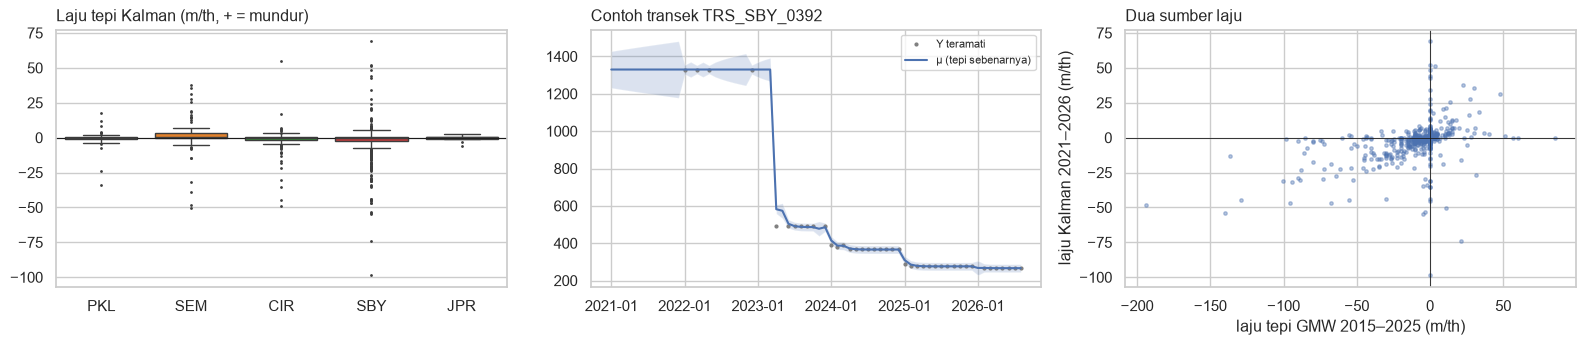

In [16]:
crps12 = skor.loc[12].CRPS.reindex(list(MODEL))
MODEL_PILIH = crps12.idxmin()                              # dipilih dengan skor ramalan di luar sampel (CRPS t+12)
print(f"Model dipilih: {MODEL_PILIH} (CRPS t+12 terendah di backtest; AIC terendah dalam sampel: {aic.AIC.idxmin()})")
X_KF, P_KF = filter_semua(Y, MODEL_PILIH, PAR[MODEL_PILIH])
MU_T, SD_MU = X_KF[:, -1, 0], np.sqrt(P_KF[:, -1, 0, 0])
V_KF, SD_V = 12 * X_KF[:, -1, 1], 12 * np.sqrt(P_KF[:, -1, 1, 1])
FC = {}
for h in [6, 12, 60]:
    mu_h = np.zeros(ND); sd_h = np.zeros(ND)
    for r in REG:
        m = REG_D == r
        if m.any():
            a_, v_, _, _, _, _ = ramal(MODEL_PILIH, PAR[MODEL_PILIH][r][0], X_KF[m, -1], P_KF[m, -1], h)
            mu_h[m], sd_h[m] = a_, np.sqrt(v_)
    FC[h] = (mu_h, sd_h)
# status terkini dari 6 bulan teramati terakhir
frac_absen = np.array([ABSEN[k, np.flatnonzero(OBS[k])[-6:]].mean() if OBS[k].any() else np.nan for k in range(ND)])
KEMUNGKINAN_HILANG = frac_absen >= 0.5
NOW = pd.DataFrame({"transek_id": IDS[iD], "wilayah": REG_D, "mu_T": MU_T, "sd_mu": SD_MU, "v_kf": V_KF, "sd_v": SD_V,
                    "mu_6": FC[6][0], "sd_6": FC[6][1], "mu_12": FC[12][0], "sd_12": FC[12][1], "kemungkinan_hilang": KEMUNGKINAN_HILANG})
ring5 = NOW.groupby("wilayah").agg(transek=("v_kf", "size"), v_median=("v_kf", "median"), sd_v_median=("sd_v", "median"),
                                   mundur_sig=("v_kf", lambda s: ((s - 1.96 * NOW.loc[s.index, "sd_v"]) > 0).mean()),
                                   maju_sig=("v_kf", lambda s: ((s + 1.96 * NOW.loc[s.index, "sd_v"]) < 0).mean()),
                                   sd_posisi_12bln=("sd_12", "median"), kemungkinan_hilang=("kemungkinan_hilang", "sum")).reindex(REG)
display(tabel(ring5.round(2), "05_nowcast_ringkas"))
print(f"Korelasi Spearman laju Kalman vs laju tepi GMW 2015–2025: {spearmanr(V_KF, V_GMW[iD, 0], nan_policy='omit')[0]:.2f}")
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
sns.boxplot(x=REG_D, y=V_KF, order=REG, ax=ax[0], palette=REG_WARNA, fliersize=1); ax[0].axhline(0, c="k", lw=0.8)
ax[0].set_title("Laju tepi Kalman (m/th, + = mundur)", loc="left")
k_ = int(np.nanargmax(np.where(np.isfinite(Y).sum(1) > 40, np.abs(V_KF), -1)))
tt = np.arange(T)
ax[1].plot(tt, Y[k_], ".", c="0.5", ms=4, label="Y teramati"); ax[1].plot(tt, X_KF[k_, :, 0], c="C0", label="μ (tepi sebenarnya)")
ax[1].fill_between(tt, X_KF[k_, :, 0] - 1.96 * np.sqrt(P_KF[k_, :, 0, 0]), X_KF[k_, :, 0] + 1.96 * np.sqrt(P_KF[k_, :, 0, 0]), alpha=0.2)
ax[1].set_title(f"Contoh transek {IDS[iD][k_]}", loc="left"); ax[1].legend(fontsize=8)
ax[1].set_xticks(np.arange(0, T, 12)); ax[1].set_xticklabels(BULAN.astype(str)[::12])
ax[2].scatter(V_GMW[iD, 0], V_KF, s=6, alpha=0.4); ax[2].axhline(0, c="k", lw=0.6); ax[2].axvline(0, c="k", lw=0.6)
ax[2].set_xlabel("laju tepi GMW 2015–2025 (m/th)"); ax[2].set_ylabel("laju Kalman 2021–2026 (m/th)")
ax[2].set_title("Dua sumber laju", loc="left")
plt.tight_layout(); simpan("05_nowcast"); plt.show()

**Interpretasi.**

- **Nowcast kini lebih baik daripada "posisi tetap" secara nyata.** Dengan radar multi-orbit, model M2 (tren + galat AR(1))
  terbaik menurut AIC maupun backtest. CRPS-nya **3,7 m lebih kecil untuk t+6** (selang bootstrap −4,5 s.d. −2,6) dan **4,4 m
  lebih kecil untuk t+12** (32,6 vs 36,9 m; selang −5,7 s.d. −2,7) dibanding persistensi. Dengan satu orbit, keunggulan itu
  hilang pada t+12. Interval 95% terkalibrasi (cakupan 98%).
- **Deret yang lebih rapat menurunkan derau**, terutama di SBY: σ_η 16 m/bulan (sebelumnya 28), dan simpangan posisi 12 bulan
  61 m (sebelumnya 100 m). Wilayah lain masih 26–59 m/bulan, karena lompatan deteksi antar bulan tetap terbaca sebagai
  perubahan posisi. Laju Kalman per transek hampir tidak ada yang signifikan (simpangan ±17–22 m/th), dan berkorelasi sedang
  dengan laju GMW (ρ = 0,52).
- **Pembagian peran**: deret Sentinel bulanan untuk **nowcast posisi dan status terkini**. Ada **44 transek "kemungkinan hilang"**,
  yaitu enam bulan teramati terakhirnya mayoritas tanpa mangrove (CIR 15, SEM 11, SBY 11, PKL 7). **Laju jangka panjang diambil
  dari GMW** (Bagian 4.2).

## 6. Penggerak perubahan: tekanan sisi laut dan sisi darat

Pertanyaan: **seberapa besar perubahan mangrove dijelaskan tekanan sisi laut (amblesan, genangan) dan sisi darat
(kawasan terbangun)?** (panduan 5.3). Model dua bagian menangani kekosongan yang tidak acak:

- **Bagian A: laju** selama tegakan ada. Respons utama adalah laju GMW 2015–2025: tepi laut $v^{GMW}$ dan lebar sabuk
  $w^{GMW}$ (yang juga menangkap kehilangan total). Laju Sentinel 2021–2026 dipakai sebagai uji ulang.
- **Bagian B: kejadian kehilangan total** (panel transek-tahun GMW, Bagian 4.3).

### 6.1 Kovariat dan galat ukur amblesan

- $Subs_i$: amblesan InSAR (cm/th). Transek kosong diisi median transek lain dalam 1 km (2 km, lalu 5 km bila perlu;
  upaya terakhir median wilayah), lalu ditandai sebagai *isian*.
- **Galat ukur** per sumber (dari notebook eksplorasi Bagian 6.1): nilai *pantai* ±(0,2 + 10%) cm/th (selisih dengan GNSS);
  nilai *darat*/*tetangga* ditambah (0,03 + 10%) cm/th; nilai *isian* ditambah dua kalinya.
- $Inund_i$: rerata frekuensi genangan 0–200 m di belakang tepi; $Built_i$: rerata P(terbangun) 2026 0–1 km di belakang tepi.
- $Lumpur_i$: lebar dataran lumpur di depan tepi, log(1 + m) (Bagian 3.7), sebagai **proksi pasokan sedimen**. Di Demak,
  mangrove hanya meluas ke laut bila ada dataran lumpur yang cukup tinggi (van Bijsterveldt dkk., 2020). Proksi ini dipakai
  sebagai **kontrol** di model tambahan untuk menguji apakah efek amblesan hanya cerminan kurangnya sedimen. Model utama
  tidak memakainya, karena dataran lumpur juga bisa merupakan hasil perubahan tepi itu sendiri.
- Genangan diduga merupakan **akibat** amblesan (ρ = 0,39). Karena itu ada dua model: **efek total** amblesan (tanpa
  genangan) dan **efek langsung** (dengan genangan). Memasukkan perantara ke model efek total akan mengecilkan efek amblesan.
- Galat baku **cluster-robust** per rangkaian transek bersambung (≤ 1 km).

In [17]:
SUMBER_SUBS = TR.subs_sumber.fillna("isian").to_numpy()
SUBS_F = SUBS.copy(); kosong = np.isnan(SUBS_F)
for k in np.flatnonzero(kosong):
    d = np.hypot(*(cxy_all - cxy_all[k]).T)
    for Rr in (1000, 2000, 5000):
        nb_ = (d <= Rr) & ~kosong
        if nb_.any():
            SUBS_F[k] = np.median(SUBS[nb_]); break
sisa = np.isnan(SUBS_F)                                  # upaya terakhir: median wilayah
SUBS_F[sisa] = pd.Series(SUBS_F).groupby(REG_I).transform("median").to_numpy()[sisa]
a_ = np.abs(SUBS_F)
SIG_U = np.sqrt((0.2 + 0.1 * a_) ** 2 + np.select([np.isin(SUMBER_SUBS, ["darat", "tetangga"]), SUMBER_SUBS == "isian"],
                                                   [(0.03 + 0.1 * a_) ** 2, (2 * (0.03 + 0.1 * a_)) ** 2], 0.0))
RUN_ALL = rangkaian(np.arange(N))
def rerata_belakang(A, lebar_m, ref):
    m = (DIST[None, :] > ref[:, None]) & (DIST[None, :] <= ref[:, None] + lebar_m)
    return np.nanmean(np.where(m, A, np.nan), 1)
INUND_B = rerata_belakang(INUND, 200, YREF[:, -1]); BUILT_B = rerata_belakang(DW[:, :, 5, 3], 1000, YREF[:, -1])
D6 = pd.DataFrame({"i": iD, "wilayah": REG_D, "run": RUN_ALL[iD], "Subs": SUBS_F[iD], "sig_u": SIG_U[iD], "sumber": SUMBER_SUBS[iD],
                   "Inund": INUND_B[iD], "Built": BUILT_B[iD], "Lumpur": np.log1p(LUMPUR_DEPAN[iD]),
                   "v_gmw": V_GMW[iD, 0], "se_v": (V_GMW[iD, 2] - V_GMW[iD, 1]) / 3.92,
                   "w_gmw": W_GMW[iD, 0], "se_w": (W_GMW[iD, 2] - W_GMW[iD, 1]) / 3.92, "v_s1": Y_lr})
print(f"Amblesan diisi pada {kosong[iD].mean():.0%} transek domain; galat ukur median {np.nanmedian(SIG_U[iD]):.2f} cm/th")
D6.describe().T[["count", "mean", "50%", "min", "max"]].round(2)

Amblesan diisi pada 19% transek domain; galat ukur median 0.27 cm/th


,count,mean,50%,min,max
i,920.0,1274.54,1276.50,4.00,2354.00
run,920.0,33.23,41.00,1.00,53.00
Subs,920.0,1.14,0.50,-0.35,11.36
sig_u,920.0,0.35,0.26,0.20,1.77
Inund,920.0,0.08,0.01,0.00,0.69
Built,920.0,0.11,0.04,0.02,0.63
Lumpur,920.0,5.08,5.67,0.00,6.22
v_gmw,796.0,-6.49,0.00,-194.00,85.56
se_v,796.0,3.67,1.28,0.00,82.48
w_gmw,920.0,13.67,7.32,-64.44,141.11


### 6.2 Model laju (Bagian A)

Tiga penduga dilaporkan berdampingan: **WLS** (bobot 1/(SE² + SE median²) dari selang Theil–Sen, SE minimum 1 m/th sesuai resolusi GMW) dengan galat baku klaster,
**Huber** dengan **bootstrap klaster** (999 ulangan rangkaian transek), dan **WLS + efek tetap wilayah** (membandingkan
transek di dalam wilayah yang sama, untuk memeriksa perancu antarwilayah). Koefisien = perubahan laju (m/th) per kenaikan
1 simpangan baku kovariat.

In [18]:
rng6 = np.random.default_rng(11)
SE_LAJU_MIN = 1.0      # m/th: batas bawah SE laju (piksel GMW 30 m selama 10 tahun); cegah bobot tak hingga pada tepi yang diam
def model_laju(d, y, se, X, B=999):
    d = d.dropna(subset=[y] + X).copy()
    Zs = (d[X] - d[X].mean()) / d[X].std()
    s0 = max(d[se].median(), SE_LAJU_MIN)
    w = 1 / (d[se].fillna(s0).clip(lower=SE_LAJU_MIN) ** 2 + s0 ** 2)
    Xc = sm.add_constant(Zs)
    wls = sm.WLS(d[y], Xc, weights=w).fit(cov_type="cluster", cov_kwds={"groups": d.run})
    fe = sm.WLS(d[y], Xc.join(pd.get_dummies(d.wilayah, drop_first=True, dtype=float)), weights=w).fit(cov_type="cluster", cov_kwds={"groups": d.run})
    hub = sm.RLM(d[y], Xc, M=sm.robust.norms.HuberT()).fit()
    runs = d.run.unique(); idx_run = {r: np.flatnonzero(d.run.to_numpy() == r) for r in runs}; boots = []
    for _ in range(B):
        ii_ = np.concatenate([idx_run[r] for r in rng6.choice(runs, len(runs))])
        try:
            boots.append(sm.RLM(d[y].to_numpy()[ii_], Xc.to_numpy()[ii_], M=sm.robust.norms.HuberT()).fit().params[1:])
        except Exception:
            pass
    boots = np.array(boots)
    rows = []
    for k, x in enumerate(X):
        rows.append({"kovariat": x, "WLS γ": wls.params[x], "WLS p (klaster)": wls.pvalues[x],
                     "Huber γ": hub.params[x], "Huber CI95 bawah": np.quantile(boots[:, k], 0.025), "Huber CI95 atas": np.quantile(boots[:, k], 0.975),
                     "P(γ>0) bootstrap": np.mean(boots[:, k] > 0), "WLS+FE γ": fe.params[x], "WLS+FE p": fe.pvalues[x]})
    return pd.DataFrame(rows).set_index("kovariat"), len(d), d.run.nunique()

KOEF = {}
for resp, se, lab in [("v_gmw", "se_v", "tepi laut GMW (+ = mundur)"), ("w_gmw", "se_w", "lebar sabuk GMW (− = menyempit)")]:
    for model, X in [("efek total", ["Subs", "Built"]), ("efek langsung", ["Subs", "Inund", "Built"]),
                     ("kontrol sedimen", ["Subs", "Built", "Lumpur"])]:
        t_, n_, c_ = model_laju(D6, resp, se, X)
        KOEF[(lab, model)] = t_
        print(f"{lab} | {model}: n = {n_}, {c_} klaster")
koef = pd.concat(KOEF, names=["respons", "model"])
display(tabel(koef.round(3), "06_koefisien_laju"))
D6["se_s1"] = 5.0
t_s1, n_s1, _ = model_laju(D6, "v_s1", "se_s1", ["Subs", "Built"])
print(f"Uji ulang dengan laju Sentinel 2021–2026 (efek total, n = {n_s1}):")
tabel(t_s1.round(3), "06_koefisien_laju_sentinel")

tepi laut GMW (+ = mundur) | efek total: n = 796, 40 klaster


tepi laut GMW (+ = mundur) | efek langsung: n = 796, 40 klaster


tepi laut GMW (+ = mundur) | kontrol sedimen: n = 796, 40 klaster


lebar sabuk GMW (− = menyempit) | efek total: n = 920, 43 klaster


lebar sabuk GMW (− = menyempit) | efek langsung: n = 920, 43 klaster


lebar sabuk GMW (− = menyempit) | kontrol sedimen: n = 920, 43 klaster


WLS γ  WLS p (klaster)  Huber γ  Huber CI95 bawah  Huber CI95 atas  P(γ>0) bootstrap  WLS+FE γ  WLS+FE p
respons                         model           kovariat                                                                                                          
tepi laut GMW (+ = mundur)      efek total      Subs      0.952            0.008    1.876             0.110            4.084             0.983     0.823     0.008
                                                Built     0.063            0.851    0.226            -0.324            2.056             0.675     0.106     0.759
                                efek langsung   Subs      0.940            0.009    1.855            -0.008            3.950             0.971     0.811     0.009
                                                Inund     0.064            0.651    0.432             0.017            1.351             0.977     0.123     0.491
                                                Built     0.076            0.825    0.336            -0.294            2.285             0.780     0.132     0.712
                                kontrol sedimen Subs      0.955            0.012    2.119             0.061            6.190             0.978     0.813     0.007
                                                Built     0.063            0.850    0.241            -0.324            2.313             0.725     0.108     0.756
                                                Lumpur    0.008            0.981    0.853            -0.484           10.038             0.809     0.063     0.862
lebar sabuk GMW (− = menyempit) efek total      Subs     -0.187            0.652   -0.780            -2.740            1.436             0.200    -0.204     0.715
                                                Built    -1.376            0.018   -2.892            -5.328           -1.165             0.000    -1.402     0.022
                                efek langsung   Subs      0.317            0.411    0.022            -1.935            3.046             0.546     0.191     0.740
                                                Inund    -2.115            0.000   -3.289            -4.911           -1.941             0.000    -2.304     0.000
                                                Built    -1.906            0.002   -3.424            -5.748           -1.700             0.000    -1.979     0.002
                                kontrol sedimen Subs     -1.094            0.055   -1.776            -4.422            1.067             0.067    -0.290     0.517
                                                Built    -1.353            0.021   -2.711            -4.966           -0.762             0.001    -1.437     0.024
                                                Lumpur   -2.217            0.032   -2.749            -7.493            0.751             0.056    -2.936     0.027

Uji ulang dengan laju Sentinel 2021–2026 (efek total, n = 885):


,WLS γ,WLS p (klaster),Huber γ,Huber CI95 bawah,Huber CI95 atas,P(γ>0) bootstrap,WLS+FE γ,WLS+FE p
kovariat,,,,,,,,
Subs,4.609,0.144,3.398,0.501,5.823,0.994,5.451,0.179
Built,2.170,0.078,0.065,-0.845,2.131,0.530,2.342,0.063


### 6.3 Galat ukur amblesan (SIMEX) dan transek isian

Galat ukur pada kovariat **mengecilkan** koefisien ke arah nol. **SIMEX** menambahkan galat tiruan bertingkat
($\lambda \sigma_u$, λ = 0,5–2), mengamati bagaimana koefisien mengecil, lalu mengekstrapolasi ke kondisi tanpa galat
(λ = −1). Uji kedua mengulang model tanpa transek yang amblesannya diisi (bukan ukuran langsung di transek itu).

In [19]:
def wls_subs(d, y, se, subs):
    s0 = max(d[se].median(), SE_LAJU_MIN)
    w = 1 / (d[se].fillna(s0).clip(lower=SE_LAJU_MIN) ** 2 + s0 ** 2)
    X = sm.add_constant(np.column_stack([subs, (d.Built - d.Built.mean()) / d.Built.std()]))
    return sm.WLS(d[y].to_numpy(), X, weights=w).fit().params[1]
sim = []
for resp, se in [("v_gmw", "se_v"), ("w_gmw", "se_w")]:
    d = D6.dropna(subset=[resp, "Subs", "Built"])
    lam = [0.0, 0.5, 1.0, 1.5, 2.0]; b_ = []
    for l in lam:
        reps = [wls_subs(d, resp, se, d.Subs + np.sqrt(l) * d.sig_u * rng6.standard_normal(len(d))) for _ in range(1 if l == 0 else 100)]
        b_.append(np.mean(reps))
    kf = np.polyfit(lam, b_, 2); b_simex = np.polyval(kf, -1)
    tanpa = d[d.sumber.isin(["pantai"])]
    sim.append({"respons": resp, "γ naif (per 1 cm/th)": b_[0], "γ SIMEX (per 1 cm/th)": b_simex,
                "koreksi": b_simex / b_[0] - 1 if b_[0] != 0 else np.nan,
                "γ tanpa isian/darat/tetangga": wls_subs(tanpa, resp, se, tanpa.Subs), "n tanpa isian": len(tanpa)})
tabel(pd.DataFrame(sim).set_index("respons").round(3), "06_simex")

,γ naif (per 1 cm/th),γ SIMEX (per 1 cm/th),koreksi,γ tanpa isian/darat/tetangga,n tanpa isian
respons,,,,,
v_gmw,0.707,0.795,0.125,0.336,356
w_gmw,-0.123,-0.138,0.120,-0.005,416


### 6.4 Kejadian kehilangan total (Bagian B) dan bukti non-parametrik

Regresi logistik transek-tahun: peluang tegakan hilang total pada suatu tahun, dengan amblesan, kawasan terbangun, dan efek
tetap wilayah. Galat baku klaster per rangkaian. Bukti non-parametrik: proporsi transek yang **sabuknya menyempit**
($w^{GMW} < 0$) menurut kelas amblesan, dengan selang bootstrap klaster.

In [20]:
PN = PANEL.copy()
PN["Subs"] = SUBS_F[PN.i]; PN["Built"] = BUILT_B[PN.i]; PN["run"] = RUN_ALL[PN.i]
PN = PN.dropna(subset=["Subs", "Built"])
if PN.hilang.sum() >= 20:
    Zp = (PN[["Subs", "Built"]] - PN[["Subs", "Built"]].mean()) / PN[["Subs", "Built"]].std()
    Xp = sm.add_constant(Zp).join(pd.get_dummies(PN.wilayah, drop_first=True, dtype=float))
    lg = sm.GLM(PN.hilang, Xp, family=sm.families.Binomial()).fit(cov_type="cluster", cov_kwds={"groups": PN.run})
    or_ = pd.DataFrame({"odds ratio per SD": np.exp(lg.params[["Subs", "Built"]]), "CI95 bawah": np.exp(lg.conf_int().loc[["Subs", "Built"], 0]),
                        "CI95 atas": np.exp(lg.conf_int().loc[["Subs", "Built"], 1]), "p (klaster)": lg.pvalues[["Subs", "Built"]]})
    print(f"Logistik kehilangan total: {len(PN):,} transek-tahun, {int(PN.hilang.sum())} kejadian")
    display(tabel(or_.round(3), "06_logistik_kehilangan"))
else:
    print(f"Kejadian kehilangan total terlalu sedikit untuk model ({int(PN.hilang.sum())}); dilaporkan deskriptif saja.")

D6["kelas_subs"] = pd.cut(D6.Subs, [-5, 0.5, 1, 2, 4, 20], labels=["≤0,5", "0,5–1", "1–2", "2–4", ">4"])
D6["menyempit"] = (D6.w_gmw < 0).astype(float)
D6["mundur"] = (D6.v_gmw > 0).astype(float)
rows = []
for kls, g_ in D6.dropna(subset=["w_gmw"]).groupby("kelas_subs", observed=True):
    per = g_.groupby("run").menyempit.agg(["sum", "size"]); runs = per.index.to_numpy(); bs = []
    for _ in range(999):
        s_ = per.loc[rng6.choice(runs, len(runs))]
        bs.append(s_["sum"].sum() / s_["size"].sum())
    rows.append({"kelas amblesan (cm/th)": kls, "transek": len(g_), "klaster": len(runs), "menyempit": g_.menyempit.mean(),
                 "CI95 bawah": np.quantile(bs, 0.025), "CI95 atas": np.quantile(bs, 0.975), "tepi mundur": g_.mundur.mean(),
                 "w median (m/th)": g_.w_gmw.median()})
display(tabel(pd.DataFrame(rows).set_index("kelas amblesan (cm/th)").round(3), "06_menyempit_per_kelas"))
dl = D6.dropna(subset=["w_gmw", "Subs"])
lt = sm.GLM(dl.menyempit, sm.add_constant((dl.Subs - dl.Subs.mean()) / dl.Subs.std()), family=sm.families.Binomial()).fit(cov_type="cluster", cov_kwds={"groups": dl.run})
print(f"Uji tren (logistik, klaster): odds ratio menyempit per SD amblesan = {np.exp(lt.params.iloc[1]):.2f}, p = {lt.pvalues.iloc[1]:.3f}")

# perbandingan wilayah: uji permutasi di tingkat klaster (menggantikan Kruskal-Wallis yang menganggap transek independen)
rm = dl.groupby("run").agg(w=("w_gmw", "mean"), wilayah=("wilayah", "first"))
stat = lambda lab: rm.groupby(lab).w.mean().var()
obs_ = stat(rm.wilayah.to_numpy()); perm = [stat(rng6.permutation(rm.wilayah.to_numpy())) for _ in range(1999)]
print(f"Beda rerata laju lebar antarwilayah (tingkat klaster, {len(rm)} klaster): p permutasi = {np.mean(np.array(perm) >= obs_):.3f}")

Logistik kehilangan total: 8,673 transek-tahun, 76 kejadian


,odds ratio per SD,CI95 bawah,CI95 atas,p (klaster)
Subs,1.371,1.040,1.807,0.025
Built,1.474,1.264,1.718,0.000


,transek,klaster,menyempit,CI95 bawah,CI95 atas,tepi mundur,w median (m/th)
kelas amblesan (cm/th),,,,,,,
"≤0,5",462,26,0.056,0.025,0.089,0.028,5.556
"0,5–1",145,17,0.090,0.022,0.177,0.138,10.000
1–2,130,18,0.100,0.039,0.171,0.108,10.625
2–4,143,14,0.035,0.006,0.069,0.210,8.333
>4,40,6,0.250,0.000,0.429,0.400,5.357


Uji tren (logistik, klaster): odds ratio menyempit per SD amblesan = 1.39, p = 0.118


Beda rerata laju lebar antarwilayah (tingkat klaster, 43 klaster): p permutasi = 0.314


**Interpretasi: tekanan laut mendorong tepi laut mundur, tekanan darat membatasi pertumbuhan ke darat, dan keduanya menaikkan
peluang kehilangan total.**

1. **Amblesan → tepi laut mundur (bukti kuat).** Efek total WLS **+0,95 m/th per SD amblesan** (p klaster = 0,008). Di dalam
   wilayah yang sama +0,82 (p = 0,008), jadi efek ini bukan hasil perbedaan antarwilayah. Huber +1,88 dengan P(γ > 0) = 0,98
   (bootstrap klaster). Koreksi galat ukur (SIMEX) **menaikkan** efek 12% (0,71 → 0,80 m/th per cm/th). Efek bertahan tanpa
   transek multi-persilangan (+0,91) dan tanpa PKL (+1,08). Pada transek yang amblesannya diukur langsung, efeknya lebih kecil
   (+0,33) tetapi searah. Bukti non-parametrik: proporsi transek yang tepinya mundur naik dari **3%** (amblesan ≤ 0,5 cm/th) ke
   11–21% (0,5–4 cm/th) dan **40%** (> 4 cm/th). Laju Sentinel 2021–2026 searah (+4,6; Huber P(γ > 0) = 0,99), tetapi terlalu
   berderau untuk signifikan dengan WLS klaster (p = 0,14).
2. **Kawasan terbangun dan genangan → sabuk melebar lebih lambat.** Amblesan tidak memengaruhi laju lebar (p = 0,65). Kawasan
   terbangun di belakang tegakan menurunkan pelebaran **−1,4 m/th per SD** (p = 0,018), dan genangan **−2,1 m/th per SD**
   (p < 0,001). Ini adalah **mekanisme coastal squeeze**: tegakan hanya bisa tumbuh ke darat bila di belakangnya tidak ada bangunan
   dan tanahnya belum terlalu basah.
3. **Kehilangan total dipicu kedua tekanan.** Peluang tegakan hilang total per tahun naik **37% per SD amblesan** (OR 1,37;
   p = 0,025) dan **47% per SD kawasan terbangun** (OR 1,47; p < 0,001), setelah efek tetap wilayah.
4. **Efek amblesan bukan cerminan kurangnya sedimen.** Setelah lebar dataran lumpur di depan tepi (proksi pasokan sedimen)
   dikontrol, efek amblesan pada tepi laut tetap **+0,95 m/th per SD** (p klaster = 0,012; di dalam wilayah +0,81, p = 0,007),
   dan dataran lumpur sendiri tidak berpengaruh pada tepi laut (p = 0,98). Pada laju lebar, dataran lumpur berasosiasi
   negatif (−2,2 m/th per SD, p = 0,03). Ini lebih mungkin akibat daripada penyebab: dataran lumpur lebar sering merupakan
   bekas sabuk yang sudah hilang. Karena itu proksi ini hanya dipakai sebagai uji kontrol.
5. Laju lebar tidak berbeda nyata antarwilayah setelah dependensi spasial diperhitungkan (uji permutasi tingkat klaster,
   p = 0,33). Perbedaan antarwilayah dijelaskan tekanan, bukan label wilayah.

## 7. Risiko: tenggelam, ruang tertutup, keterpaparan, dan kelayakan restorasi

### 7.1 Defisit vertikal

Mangrove bertahan selama permukaan sedimennya naik secepat muka air relatif, yaitu tanah turun ditambah laut naik.
Defisit vertikal $D_i = Subs_i + SLR - A$, dengan kenaikan muka laut absolut $SLR$ = **0,39 ± 0,04 cm/th** (altimetri Laut
Jawa 1993–2015, Kismawardhani dkk., 2018; Indonesia 1992–2020 3,9 ± 0,4 mm/th, Triana & Wahyudi, 2020) dan laju akresi
$A$ = **0,5 cm/th** (uji akresi 0,2–1,5 dan SLR 0–0,5 di Bagian 10). Peluang defisit $P(D_i > 0) = \Phi\big(D_i/\sigma_{D,i}\big)$
dengan $\sigma_{D,i}^2 = \sigma_{u,i}^2 + \sigma_{SLR}^2$. Dihitung untuk **semua** transek.

**Dasar nilai $A$.** Pengukuran Pb-210 di Indonesia berkisar 0,2–0,56 cm/th: 0,21–0,22 cm/th di perairan muara Pemali dan
Nipon, Brebes (Gemilang dkk., 2017), serta 0,37–0,56 cm/th di mangrove terdegradasi Sumatra Utara (Murdiyarso dkk., 2018).
Kenaikan permukaan tanah lebih kecil daripada akresi sedimen karena pemadatan dangkal (Lovelock dkk., 2015:
kenaikan ≈ 0,78 × akresi − 0,44 cm/th). Nilai 0,5 cm/th berada di ujung atas rentang itu, dekat ambang global kegagalan
vertikal mangrove (0,4–0,7 cm/th; Saintilan dkk., 2020, 2023), sehingga defisit yang dihitung **konservatif**.
Skenario 0,2 cm/th (pesimis) dan 1,0–1,5 cm/th (optimis) ada di Bagian 10.2. Akresi ekstrem > 10 cm/th hanya terjadi
dengan pasokan lumpur luar biasa seperti di muara Porong (Sidik dkk., 2016), dan di Demak kenaikan muka laut relatif
sampai empat kali laju akresi dataran di depan tegakan (van Bijsterveldt dkk., 2023).

**Waktu sampai tenggelam.** Mengikuti Lovelock dkk. (2015), modal elevasi = setengah tunggang pasut (model EOT20 per zona
pasut: ≈ 0,46 m CIR, 0,49 m PKL, 0,55 m SEM, 0,58 m JPR, 1,1–1,6 m SBY). Waktu tenggelam $T_i = \text{modal}_i / D_i$ bila
$D_i > 0$. Monte Carlo (2.000 ulangan dari sebaran $D_i$) memberi median $T_i$ dan $P(T_i \le 24)$, yaitu peluang tenggelam
**sebelum 2050**. Ini perkiraan orde besar: umpan balik akresi (sedimen bertambah saat genangan makin dalam) akan
memperlambatnya, sedangkan tegakan yang sudah berada di bawah tengah rentang pasut tenggelam lebih cepat.

### 7.2 Peluang ruang gerak tertutup (horizontal)

$$P(\text{Closed}_h) = 1 - \Phi\!\left(\frac{B^{hard}_i - \hat\mu_{i,T+12h}}{\sqrt{\mathrm{Var}(\mu_{i,T+12h}) + \sigma_B^2}}\right)$$

**[Penyesuaian]** Rata-rata dan varians posisi tepi diambil langsung dari ramalan model state-space terpilih, termasuk
derau proses, ketidakpastian laju, dan kovarians keduanya (panduan hanya memakai $\sigma^2_\mu + h^2\sigma^2_v$).
Transek dengan penghalang **tersensor** (tidak ada penghalang sampai 3,5 km) punya ruang gerak sebenarnya lebih lebar, sehingga
peluangnya adalah **batas atas**. Skenario **penghalang fungsional** memperlakukan tambak berpematang yang masih tertutup
sebagai penghalang. Sebagai pembanding, peluang juga dihitung dengan rumus panduan memakai **laju jangka panjang GMW**
(2015–2025, lebih presisi) sebagai laju penyempitan.

In [21]:
A_, SLR_ = PARAM["AKRESI"], PARAM["SLR"]
SIG_D = np.sqrt(SIG_U ** 2 + PARAM["SLR_SD"] ** 2)          # galat amblesan + ketidakpastian kenaikan muka laut
DEF = SUBS_F + SLR_ - A_
P_DEF = norm.cdf(DEF / SIG_D)
KELAS_DEF = np.select([DEF <= 0, DEF <= 1, DEF <= 3], ["seimbang/surplus (≤ 0)", "defisit ringan (0–1)", "defisit sedang (1–3)"], "defisit berat (> 3)").astype(object)
KELAS_DEF[np.isnan(DEF)] = "tidak ada data"

def p_closed(B, h):
    mu_h = np.zeros(ND); var_h = np.zeros(ND)
    for r in REG:
        m = REG_D == r
        if m.any():
            a_, v_, _, _, _, _ = ramal(MODEL_PILIH, PAR[MODEL_PILIH][r][0], X_KF[m, -1], P_KF[m, -1], 12 * h)
            mu_h[m], var_h[m] = a_, v_
    return 1 - norm.cdf((B - mu_h) / np.sqrt(var_h + PARAM["SIGMA_B"] ** 2)), mu_h, np.sqrt(var_h)
MS_NOW = B_HARD[iD, -1] - MU_T
P1, _, _ = p_closed(B_HARD[iD, -1], 1)
P5, MU5, SD5 = p_closed(B_HARD[iD, -1], 5)
P5_FUNC, _, _ = p_closed(B_FUNC[iD], 5)
POP = TR.pop_2026.to_numpy()
# pembanding: rumus panduan dengan laju jangka panjang GMW (lebih presisi daripada laju Kalman 5,7 tahun)
vg = np.nan_to_num(V_GMW[iD, 0]); se_vg = (V_GMW[iD, 2] - V_GMW[iD, 1]) / 3.92
se_vg = np.where(np.isfinite(se_vg), se_vg, np.nanmedian(se_vg))
P5_GMW = 1 - norm.cdf((B_HARD[iD, -1] - (MU_T + 5 * vg)) / np.sqrt(SD_MU ** 2 + 25 * se_vg ** 2 + PARAM["SIGMA_B"] ** 2))
PERI = P5 * np.log10(POP[iD] + 1); PERI_FUNC = P5_FUNC * np.log10(POP[iD] + 1)
R7 = pd.DataFrame({"i": iD, "transek_id": IDS[iD], "wilayah": REG_D, "MS_now": MS_NOW, "tersensor": B_SENS[iD, -1],
                   "MS_func": B_FUNC[iD] - MU_T, "P1": P1, "P5": P5, "P5_func": P5_FUNC, "P5_gmw": P5_GMW, "sd_posisi_5th": SD5,
                   "PERI": PERI, "PERI_func": PERI_FUNC, "P_def": P_DEF[iD]})
ring7 = R7.groupby("wilayah").agg(MS_median=("MS_now", "median"), MS_func_median=("MS_func", "median"), tersensor=("tersensor", "mean"),
                                  sd_posisi_5th=("sd_posisi_5th", "median"), P5_gt_07=("P5", lambda p: (p > 0.7).mean()),
                                  P5_func_gt_07=("P5_func", lambda p: (p > 0.7).mean()), P5_maks=("P5", "max"),
                                  P5_gmw_gt_07=("P5_gmw", lambda p: (p > 0.7).mean()), P5_gmw_maks=("P5_gmw", "max"),
                                  P_def_gt_05=("P_def", lambda p: (p > 0.5).mean())).reindex(REG)
display(tabel(ring7.round(3), "07_risiko_domain"))
defw = pd.crosstab(pd.Series(REG_I, name="wilayah"), pd.Series(KELAS_DEF, name="defisit vertikal")).reindex(REG)
display(tabel(defw, "07_defisit_vertikal_semua"))

# waktu sampai tenggelam (Lovelock dkk. 2015): modal elevasi = setengah tunggang pasut, dibagi defisit vertikal
TZ = pd.read_csv(md.DS / "pasut_statistik.csv").set_index("tide_zone").rentang_penuh_m
MODAL = TR.tide_zone.map(TZ).to_numpy() * 100 / 2                    # cm
d_s = DEF[:, None] + SIG_D[:, None] * np.random.default_rng(7).standard_normal((N, 2000))
t_s = np.where(d_s > 0, MODAL[:, None] / np.maximum(d_s, 1e-6), np.inf)
ada_t = np.isfinite(MODAL) & np.isfinite(DEF)
T_TGL = np.where(ada_t, np.median(t_s, 1), np.nan); TAHUN_TGL = 2026 + T_TGL
P_TGL50 = np.where(ada_t, (t_s <= 2050 - 2026).mean(1), np.nan)
def p_tenggelam(tahun, slr=None, akresi=None):
    # P(T <= tahun - 2026) = P(D >= modal / horizon); tahun = inf memberi aturan lama P(D > 0)
    d_ = SUBS_F + (SLR_ if slr is None else slr) - (A_ if akresi is None else akresi)
    ambang = np.nan_to_num(MODAL / (tahun - 2026), nan=0.0)
    return norm.sf((ambang - d_) / SIG_D)
P_TGL = p_tenggelam(PARAM["TGL_TAHUN"])
R7["tahun_tgl"], R7["P_tgl50"] = TAHUN_TGL[iD], P_TGL50[iD]
dom_ = np.zeros(N, bool); dom_[iD] = True
tg = pd.DataFrame({"wilayah": REG_I, "bermangrove": np.where(dom_, "bermangrove", "tanpa mangrove"), "modal": MODAL,
                   "T": T_TGL, "P50": P_TGL50})
tgl = tg.groupby(["bermangrove", "wilayah"]).agg(transek=("T", "size"), modal_elevasi_cm=("modal", "median"),
                                                 tahun_tenggelam_median=("T", lambda t: 2026 + np.median(t)),
                                                 P_sebelum_2050_gt_05=("P50", lambda p: (p > 0.5).mean()),
                                                 tenggelam_sebelum_2100=("T", lambda t: (t <= 74).mean()))
tabel(tgl.round(2), "07_waktu_tenggelam")

,MS_median,MS_func_median,tersensor,sd_posisi_5th,P5_gt_07,P5_func_gt_07,P5_maks,P5_gmw_gt_07,P5_gmw_maks,P_def_gt_05
wilayah,,,,,,,,,,
PKL,2367.240,182.942,0.378,333.806,0.0,0.000,0.153,0.0,0.000,0.911
SEM,2684.986,189.993,0.567,228.003,0.0,0.008,0.470,0.0,0.582,0.958
CIR,2550.000,179.996,0.441,255.522,0.0,0.007,0.292,0.0,0.000,0.986
SBY,1490.030,369.945,0.354,154.234,0.0,0.007,0.454,0.0,0.357,0.904
JPR,2835.161,345.000,0.625,269.347,0.0,0.000,0.308,0.0,0.000,0.000


defisit vertikal,defisit berat (> 3),defisit ringan (0–1),defisit sedang (1–3),seimbang/surplus (≤ 0)
wilayah,,,,
PKL,101,12,36,141
SEM,129,66,104,16
CIR,48,137,191,29
SBY,0,925,72,168
JPR,0,3,0,187


transek  modal_elevasi_cm  tahun_tenggelam_median  P_sebelum_2050_gt_05  tenggelam_sebelum_2100
bermangrove    wilayah                                                                                                 
bermangrove    CIR          145             46.10                 2049.26                  0.56                    0.77
               JPR            8             57.55                     inf                  0.00                    0.00
               PKL           45             47.90                 2040.21                  0.80                    0.91
               SBY          602            123.45                 2466.89                  0.00                    0.00
               SEM          120             54.80                 2060.54                  0.42                    0.82
tanpa mangrove CIR          260             45.85                 2067.13                  0.44                    0.55
               JPR          182             57.55                     inf                  0.00                    0.00
               PKL          245             47.90                     inf                  0.34                    0.40
               SBY          563            123.45                 2513.45                  0.00                    0.00
               SEM          195             54.80                 2046.01                  0.59                    0.89

### 7.3 Kelayakan restorasi (RFI) dan ketahanan bobotnya

**[Penyesuaian]** Komponen $(1 - P(\text{Closed}_1))$ dari panduan hampir konstan (≈ 1 di semua transek), sehingga tidak
membedakan apa-apa. Komponen itu diganti **kesiapan tambak** (proporsi tambak di ruang peluang yang sudah tidak dikelola
intensif atau terhubung pasang). RFI dihitung untuk **semua** transek (titik acuan = tepi mangrove atau garis pantai basis):

$$RFI_i = \tfrac14\big[\text{rank}(Space_{opp}) + HydroSuit + (1 - \text{rank}(Subs)) + \text{KesiapanTambak}\big]$$

Ketahanan bobot diuji dengan 1.000 bobot acak Dirichlet(1,1,1,1).

In [22]:
KOMP = np.column_stack([rk(OPP), HYD, 1 - rk(np.nan_to_num(SUBS_F, nan=np.nanmedian(SUBS_F))), SIAP_TAMBAK])
RFI = KOMP.mean(1)
Wd = np.random.default_rng(5).dirichlet(np.ones(4), 1000)
top = RFI >= np.quantile(RFI, 0.8); jac, rho = [], []
for w_ in Wd:
    r_ = KOMP @ w_; t_ = r_ >= np.quantile(r_, 0.8)
    jac.append((top & t_).sum() / (top | t_).sum()); rho.append(spearmanr(RFI, r_)[0])
print(f"Ketahanan bobot RFI: Spearman median {np.median(rho):.2f} (P5 {np.quantile(rho, 0.05):.2f}); "
      f"irisan 20% teratas (Jaccard) median {np.median(jac):.2f} (P5 {np.quantile(jac, 0.05):.2f})")
tabel(pd.DataFrame({"wilayah": REG_I, "domain": DOMAIN, "RFI": RFI}).groupby(["domain", "wilayah"]).RFI.describe()[["count", "25%", "50%", "75%"]].round(2), "07_rfi")

Ketahanan bobot RFI: Spearman median 0.90 (P5 0.46); irisan 20% teratas (Jaccard) median 0.47 (P5 0.29)


count   25%   50%   75%
domain wilayah                         
False  CIR      260.0  0.48  0.56  0.61
       JPR      182.0  0.26  0.41  0.55
       PKL      245.0  0.38  0.49  0.56
       SBY      563.0  0.20  0.31  0.56
       SEM      195.0  0.42  0.54  0.60
True   CIR      145.0  0.50  0.56  0.61
       JPR        8.0  0.27  0.67  0.69
       PKL       45.0  0.36  0.50  0.55
       SBY      602.0  0.22  0.57  0.66
       SEM      120.0  0.50  0.56  0.62

**Interpretasi.**

- **Ancaman utama adalah vertikal, dan terkonsentrasi di Jawa Tengah dan Cirebon.** Setelah kenaikan muka laut dihitung,
  muka air relatif naik lebih cepat daripada akresi pada 91–99% transek bermangrove PKL, SEM, dan CIR, dan 90% di SBY.
  Tetapi besarnya berbeda jauh: defisit berat (> 3 cm/th) ada di 129 transek SEM, 101 PKL, dan 48 CIR, sedangkan hampir semua
  transek SBY hanya defisit ringan (0–1 cm/th).
- **Waktu tenggelam membedakan keduanya.** Dengan modal elevasi setengah tunggang pasut, median tahun tenggelam tegakan adalah
  **2040 di PKL, 2049 di CIR, dan 2061 di SEM**. Tegakan yang diperkirakan tenggelam sebelum 2100 mencapai 91% transek PKL,
  82% SEM, dan 77% CIR, dan sebelum 2050 80%, 42%, dan 56%. SBY punya tunggang pasut sekitar 2,5 m, sehingga dengan defisit
  ringan tegakannya baru tenggelam setelah 2400. Pantai tanpa mangrove di SEM juga terancam (89% sebelum 2100), sehingga
  penanaman tanpa penangkap sedimen di sana kemungkinan sia-sia.
- **Coastal squeeze horizontal belum mendesak dalam 5 tahun.** Tidak ada transek dengan P(Closed₅) > 0,7, baik dengan varians
  Kalman penuh (maksimum 0,47) maupun dengan laju GMW (maksimum 0,58). Ruang gerak median 1,5–2,8 km. Kesimpulan ini tidak
  bergantung pada pilihan model laju. Penghalang tersensor membuat angka ini **batas atas**.
- **Tambak berpematang adalah penghalang yang nyata.** Bila tambak yang masih tertutup dihitung sebagai penghalang, ruang gerak
  median menyusut menjadi **180–370 m**. Karena tepi saat ini hampir tidak bergeser ke darat, peluang tertutup 5 tahun tetap
  kecil (≤ 0,8% transek > 0,7). Tetapi tanpa pembukaan pematang, tegakan tidak punya tempat mundur ketika bagian depannya
  tenggelam.
- **RFI** stabil secara umum (Spearman median 0,90 terhadap bobot acak), tetapi **daftar 20% teratasnya peka bobot**
  (Jaccard median 0,47). RFI dipakai untuk mengurutkan di dalam kelas rekomendasi, bukan sebagai satu-satunya dasar
  memilih lokasi.

## 8. Label berlapis dan rekomendasi untuk semua transek

Setiap transek mendapat label di empat layer independen. Layer 1–2 juga tersedia per titik/segmen untuk dashboard.

| Layer | Isi | Bagian |
|---|---|---|
| 1 Dinamika mangrove | stabil · ekspansi · kehilangan 2021–2025 · hilang sebelum 2021 · tidak pernah · peta saja | 4.1 |
| 2 Tutupan lahan | mangrove · dataran lumpur · 4 status tambak · sawah · vegetasi darat · terbangun (baru) · perairan | 3.7 |
| 3 Tekanan | defisit vertikal · jarak penghalang keras · PSN | 7.1, 3.6 |
| 4 Rekomendasi | tipologi 4 aksi (bermangrove) · 7 rekomendasi untuk pantai tanpa mangrove | 8.2–8.3 |

### 8.1 Layer tekanan

In [23]:
JARAK_B = B_HARD[:, -1] - YREF[:, -1]
KELAS_B = np.select([B_SENS[:, -1], JARAK_B <= 250, JARAK_B <= 500, JARAK_B <= 1000],
                    ["tersensor (> 3 km)", "≤ 250 m", "250–500 m", "500–1.000 m"], "> 1.000 m").astype(object)
LAUT_T = (P_TGL > 0.5) | (INUND_B > JENDELA[1])
DARAT_T = ((JARAK_B <= PARAM["MS_DEKAT"]) & ~B_SENS[:, -1]) | PSN
L3 = pd.DataFrame({"wilayah": REG_I, "defisit": KELAS_DEF, "penghalang": KELAS_B, "PSN": PSN})
display(pd.crosstab(L3.wilayah, L3.defisit).reindex(REG))
tabel(pd.crosstab(L3.wilayah, L3.penghalang).reindex(REG), "08_layer_tekanan_penghalang")

defisit,defisit berat (> 3),defisit ringan (0–1),defisit sedang (1–3),seimbang/surplus (≤ 0)
wilayah,,,,
PKL,101,12,36,141
SEM,129,66,104,16
CIR,48,137,191,29
SBY,0,925,72,168
JPR,0,3,0,187


penghalang,250–500 m,500–1.000 m,> 1.000 m,tersensor (> 3 km),≤ 250 m
wilayah,,,,,
PKL,47,37,96,44,66
SEM,25,34,77,136,43
CIR,26,35,120,198,26
SBY,133,168,217,264,383
JPR,15,21,53,41,60


### 8.2 Tipologi 4 aksi untuk transek bermangrove (dengan peluang kelas)

Sumbu panduan 6.2 dioperasionalkan secara eksplisit:

- **Tekanan laut tinggi**: tegakan diperkirakan **tenggelam sebelum 2100** ($P(T_i \le 74) > 0{,}5$, Bagian 7.1), **atau**
  genangan di belakang tepi di atas batas atas jendela hidroperiode;
- **Tekanan darat tinggi**: penghalang keras ≤ 500 m di belakang tepi (tidak tersensor), **atau** transek memotong tol/
  tanggul laut (PSN).

**[Penyesuaian]** Tekanan laut memakai **waktu tenggelam**, bukan sekadar ada-tidaknya defisit ($P(D_i > 0) > 0{,}5$).
Aturan ada-tidaknya defisit mengabaikan besar defisit dan modal elevasi: setelah kenaikan muka laut dihitung, hampir semua
transek SBY punya defisit ringan (0–1 cm/th), tetapi dengan tunggang pasut sekitar 2,5 m tegakannya baru tenggelam
berabad-abad lagi. Horizon 2100 adalah horizon perencanaan kenaikan muka laut yang umum. Horizon 2050 dan aturan lama diuji
di Bagian 10.2.

**[Penyesuaian]** Kelas tidak ditentukan sekali, tetapi dengan **Monte Carlo** (2.000 ulangan): amblesan diambil dari
sebaran galat ukurnya dan posisi tepi dari sebaran posterior Kalman. Setiap transek mendapat peluang untuk keempat kelas.
Kelas akhir adalah yang paling mungkin, dan **tingkat keyakinan** = peluang kelas itu. Kriteria angka panduan
(P(Closed₁) > 0,6 untuk RED; P(Closed₅) > 0,7 dan RFI > 0,6 untuk ORANGE) dipakai sebagai cek koherensi.

In [24]:
rng8 = np.random.default_rng(8); S = 2000
sub_s = SUBS_F[iD][:, None] + SIG_D[iD][:, None] * rng8.standard_normal((ND, S))
AMBANG_V = MODAL / (PARAM["TGL_TAHUN"] - 2026)                    # cm/th: defisit yang menenggelamkan sebelum horizon
laut_s = ((sub_s + SLR_ - A_) >= AMBANG_V[iD][:, None]) | (INUND_B[iD] > JENDELA[1])[:, None]
ms_s = MS_NOW[:, None] + np.sqrt(SD_MU ** 2 + PARAM["SIGMA_B"] ** 2)[:, None] * rng8.standard_normal((ND, S))
darat_s = ((ms_s <= PARAM["MS_DEKAT"]) & ~B_SENS[iD, -1][:, None]) | PSN[iD][:, None]
URUT_T = ["RED", "ORANGE", "YELLOW", "GREEN"]
PK = np.stack([(laut_s & darat_s).mean(1), (laut_s & ~darat_s).mean(1), (~laut_s & darat_s).mean(1), (~laut_s & ~darat_s).mean(1)], 1)
TIPE = np.array(URUT_T)[PK.argmax(1)]; YAKIN = PK.max(1)
R7["tipe"], R7["yakin"] = TIPE, YAKIN
for k, t_ in enumerate(URUT_T):
    R7[f"P_{t_}"] = PK[:, k]
R7["RFI"] = RFI[iD]; R7["P_tgl"] = P_TGL[iD]
display(pd.crosstab(R7.wilayah, R7.tipe).reindex(index=REG, columns=URUT_T, fill_value=0))
koh = R7.groupby("tipe").agg(n=("P5", "size"), yakin_median=("yakin", "median"), yakin_lt_07=("yakin", lambda s: (s < 0.7).mean()),
                             MS_median=("MS_now", "median"), P5_median=("P5", "median"), P5_func_median=("P5_func", "median"),
                             P_def_median=("P_def", "median"), P_tgl_median=("P_tgl", "median"), RFI_median=("RFI", "median"),
                             kriteria_panduan_RED=("P1", lambda p: (p > 0.6).mean()),
                             kriteria_panduan_ORANGE=("P5", lambda p: ((p > 0.7) & (R7.RFI[p.index] > 0.6)).mean())).reindex(URUT_T)
tabel(koh.round(3), "08_koherensi_tipologi")

tipe,RED,ORANGE,YELLOW,GREEN
wilayah,,,,
PKL,3,38,4,0
SEM,8,91,1,20
CIR,4,108,11,22
SBY,0,5,134,463
JPR,0,0,3,5


,n,yakin_median,yakin_lt_07,MS_median,P5_median,P5_func_median,P_def_median,P_tgl_median,RFI_median,kriteria_panduan_RED,kriteria_panduan_ORANGE
tipe,,,,,,,,,,,
RED,15,1.000,0.067,310.004,0.153,0.252,1.000,1.000,0.070,0.0,0.0
ORANGE,242,0.999,0.083,2729.997,0.000,0.203,1.000,0.999,0.553,0.0,0.0
YELLOW,153,1.000,0.052,270.247,0.040,0.125,0.716,0.000,0.213,0.0,0.0
GREEN,510,1.000,0.029,2408.957,0.000,0.001,0.860,0.000,0.617,0.0,0.0


### 8.3 Rekomendasi untuk pantai tanpa mangrove

Transek di luar domain (tidak bermangrove, hilang sebelum 2021, atau hanya bermangrove di peta) dinilai dengan dua sumbu,
sejajar dengan tipologi mangrove: **jenis lahan peluang** (layer 2) × **ancaman tenggelam sebelum 2100** (layer 3, sama dengan sumbu laut tipologi). Jenis lahan ditentukan
berurutan: pantai terbangun (penghalang ≤ 100 m dari garis pantai atau ≥ 50% zona 0–1 km terbangun) → dataran lumpur
≥ 100 m di depan garis pantai → tambak mayoritas tidak dikelola intensif dengan ruang peluang ≥ 200 m → tambak aktif
≥ 200 m → lahan darat.

| Jenis lahan | Tidak terancam tenggelam sebelum 2100 | Terancam tenggelam sebelum 2100 ($P(T_i \le 74) > 0{,}5$) |
|---|---|---|
| Dataran lumpur | **Restorasi alami di dataran lumpur** | **Penangkap sedimen + penanaman di dataran lumpur** |
| Tambak terbengkalai | **Restorasi hidrologis tambak terbengkalai** | **Restorasi hidrologis + penangkap sedimen** |
| Tambak aktif | **Silvofishery pada tambak aktif** | (sama) |
| Pantai terbangun | **Perlindungan pantai terbangun** | (sama) |
| Lahan darat | **Lahan darat, tidak prioritas** | (sama) |

Overlay yang berlaku untuk semua transek: **ancaman konversi** (≥ 30 m bangunan baru tetap dalam 1 km di belakang
tepi/garis pantai, atau mangrove GMW 2021 yang menjadi bangunan) dan **kemungkinan hilang** (nowcast, Bagian 5.3).

In [25]:
z1k = (DIST[None, :] >= YREF[:, -1][:, None]) & (DIST[None, :] <= YREF[:, -1][:, None] + 1000)
porsi_bangun = (np.isin(LAHAN, ["terbangun", "terbangun baru"]) & z1k).sum(1) / np.maximum(z1k.sum(1), 1)
LAHAN_UTAMA = np.select([((JARAK_B <= 100) & ~B_SENS[:, -1]) | (porsi_bangun >= 0.5), LUMPUR_DEPAN >= 100,
                         (OPP >= 200) & (SIAP_TAMBAK >= 0.5), OPP_SILVO >= 200],
                        ["pantai terbangun", "dataran lumpur", "tambak terbengkalai", "tambak aktif"], "lahan darat")
REK_NONMANGROVE = ["Penangkap sedimen + penanaman di dataran lumpur", "Restorasi hidrologis + penangkap sedimen",
                   "Restorasi alami di dataran lumpur", "Restorasi hidrologis tambak terbengkalai", "Silvofishery pada tambak aktif",
                   "Perlindungan pantai terbangun", "Lahan darat, tidak prioritas"]
def rekom_non(defisit):
    return np.select([LAHAN_UTAMA == "pantai terbangun",
                      (LAHAN_UTAMA == "dataran lumpur") & defisit, LAHAN_UTAMA == "dataran lumpur",
                      (LAHAN_UTAMA == "tambak terbengkalai") & defisit, LAHAN_UTAMA == "tambak terbengkalai",
                      LAHAN_UTAMA == "tambak aktif"],
                     ["Perlindungan pantai terbangun", REK_NONMANGROVE[0], REK_NONMANGROVE[2], REK_NONMANGROVE[1], REK_NONMANGROVE[3],
                      REK_NONMANGROVE[4]], "Lahan darat, tidak prioritas").astype(object)
REK_NON = rekom_non(P_TGL > 0.5)
NAMA_TIPE = {"RED": "RED · rekayasa hibrida", "ORANGE": "ORANGE · managed realignment",
             "YELLOW": "YELLOW · pengayaan sabuk hijau", "GREEN": "GREEN · konservasi ketat"}
REKOM = REK_NON.copy(); REKOM[iD] = [NAMA_TIPE[t] for t in TIPE]
YAKIN_ALL = np.full(N, np.nan); YAKIN_ALL[iD] = YAKIN
ANCAMAN = ((BARU_BANGUN & z1k).sum(1) >= 3) | ((G21 & ~G25 & BUILT[..., 4] & BUILT[..., 5]).sum(1) >= 3)
HILANG_NOW = np.zeros(N, bool); HILANG_NOW[iD] = KEMUNGKINAN_HILANG
URUT_REK = list(NAMA_TIPE.values()) + REK_NONMANGROVE
rek_tab = pd.crosstab(pd.Series(REG_I, name="wilayah"), pd.Series(REKOM, name="rekomendasi")).reindex(index=REG, columns=URUT_REK, fill_value=0).T
rek_tab["TOTAL"] = rek_tab.sum(axis=1)
display(tabel(rek_tab, "08_rekomendasi"))
print(f"Overlay ancaman konversi: {ANCAMAN.sum()} transek {pd.Series(REG_I[ANCAMAN]).value_counts().reindex(REG).fillna(0).astype(int).to_dict()}; "
      f"kemungkinan hilang (nowcast): {HILANG_NOW.sum()} transek")

wilayah,PKL,SEM,CIR,SBY,JPR,TOTAL
rekomendasi,,,,,,
RED · rekayasa hibrida,3,8,4,0,0,15
ORANGE · managed realignment,38,91,108,5,0,242
YELLOW · pengayaan sabuk hijau,4,1,11,134,3,153
GREEN · konservasi ketat,0,20,22,463,5,510
Penangkap sedimen + penanaman di dataran lumpur,4,89,31,1,0,125
Restorasi hidrologis + penangkap sedimen,66,31,90,0,0,187
Restorasi alami di dataran lumpur,8,15,77,230,130,460
Restorasi hidrologis tambak terbengkalai,1,5,0,4,0,10
Silvofishery pada tambak aktif,15,0,27,1,2,45


Overlay ancaman konversi: 221 transek {'PKL': 26, 'SEM': 32, 'CIR': 23, 'SBY': 123, 'JPR': 17}; kemungkinan hilang (nowcast): 44 transek


**Interpretasi.**

- **Transek bermangrove (920)**:
  - **ORANGE 242**: CIR 108, SEM 91, PKL 38, SBY 5. Terancam tenggelam sebelum 2100 dengan ruang darat lapang, sehingga
    prioritasnya membuka pematang agar tegakan bisa mundur.
  - **RED 15**: SEM 8, CIR 4, PKL 3. Terancam tenggelam dan terhimpit penghalang dekat.
  - **YELLOW 153**: SBY 134, CIR 11. Penghalang dekat, tidak terancam tenggelam sebelum 2100.
  - **GREEN 510**: SBY 463, CIR 22, SEM 20.

  Tingkat keyakinan median ≥ 0,99, dan hanya 3–8% transek per kelas punya keyakinan < 0,7. Kelas koheren: RED punya ruang
  tersempit (median 310 m) dan P(Closed₅) tertinggi (median 0,15).
- **Pantai tanpa mangrove (1.445)** tidak lagi abu-abu:
  - **Perlindungan pantai terbangun 486**, terutama SBY;
  - **Restorasi alami di dataran lumpur 460**: SBY 230, JPR 130, CIR 77;
  - **Restorasi hidrologis + penangkap sedimen 187**: CIR 90, PKL 66, SEM 31;
  - **Penangkap sedimen + penanaman di dataran lumpur 125**: SEM 89, CIR 31;
  - silvofishery 45, restorasi hidrologis tanpa ancaman tenggelam 10, lahan darat 132.

  Tambak terbengkalai di CIR dan PKL hampir selalu berada di zona yang terancam tenggelam, jadi pembukaan pematang perlu
  disertai penangkap sedimen.
- **Overlay**: **221 transek dengan ancaman konversi** (SBY 123) dan **44 transek kemungkinan hilang** (nowcast).
- Status tambak diturunkan dari citra satelit dan **belum divalidasi lapangan**, sehingga rekomendasi berbasis status tambak
  (restorasi hidrologis, silvofishery) bersifat **indikatif** dan perlu verifikasi lokasi sebelum implementasi.

## 9. Hotspot keterpaparan dan kawasan prioritas

### 9.1 Hotspot keterpaparan (Getis-Ord Gi*) dengan koreksi uji berganda

Dua indeks diuji: **PERI** panduan = P(Closed₅) × log₁₀(Pop + 1) (ancaman horizontal) dan **PERI vertikal** =
P(tenggelam sebelum 2050) × log₁₀(Pop + 1). **[Penyesuaian]** PERI vertikal ditambahkan karena P(Closed₅) hampir nol di
mana-mana (Bagian 7.2), sedangkan ancaman utama adalah vertikal (Bagian 7.1).

Bobot `DistanceBand` biner 1.000 m antar pusat transek domain (panduan 6.1). **[Penyesuaian]** Hotspot ditentukan dari
**p permutasi** (9.999 permutasi bersyarat), bukan z pendekatan normal, karena PERI sangat miring (hampir nol di sebagian besar
transek). Karena ada ratusan uji sekaligus, dipakai koreksi **Benjamini–Hochberg (FDR 5%)**. Radius 500–1.500 m diuji
sebagai sensitivitas.

In [26]:
from libpysal.weights import DistanceBand
from esda.getisord import G_Local
from statsmodels.stats.multitest import multipletests
cxy_d = cxy_all[iD]
def gi_hotspot(val, radius, perm=9999, seed=42):
    w = DistanceBand(cxy_d, threshold=radius, binary=True, silence_warnings=True)
    iso = np.array([w.cardinalities[k] == 0 for k in range(ND)])
    gl = G_Local(val, w, transform="B", star=True, permutations=perm, seed=seed)
    z = np.where(iso, np.nan, gl.Zs); p = np.where(iso | (gl.Zs <= 0), 1.0, gl.p_sim)
    rej = multipletests(p, alpha=0.05, method="fdr_bh")[0] & ~iso
    return z, p, rej, iso, (z > 1.96) & ~iso
GI_Z, GI_P, HOT, ISO, HOT_LAMA = gi_hotspot(PERI, 1000)
R7["Gi_z"], R7["Gi_p"], R7["hotspot"] = GI_Z, GI_P, HOT
print(f"Isolat: {ISO.sum()} transek; hotspot FDR 5%: {HOT.sum()} (dengan aturan lama z > 1,96: {HOT_LAMA.sum()})")
sens_r = []
for rad in [500, 750, 1000, 1500]:
    _, _, h_, iso_, _ = gi_hotspot(PERI, rad, perm=4999)
    sens_r.append(dict(radius_m=rad, isolat=int(iso_.sum()), hotspot=int(h_.sum()),
                       jaccard_vs_1000=(h_ & HOT).sum() / max((h_ | HOT).sum(), 1)))
display(tabel(pd.DataFrame(sens_r).set_index("radius_m").round(2), "09_sensitivitas_radius"))
# PERI vertikal: peluang tenggelam sebelum 2050 x penduduk
PERI_V = np.nan_to_num(P_TGL50[iD]) * np.log10(POP[iD] + 1)
GI_ZV, GI_PV, HOT_V, _, HOT_V_LAMA = gi_hotspot(PERI_V, 1000)
R7["PERI_v"], R7["Gi_z_v"], R7["hotspot_tenggelam"] = PERI_V, GI_ZV, HOT_V
print(f"Hotspot PERI vertikal FDR 5%: {HOT_V.sum()} (aturan lama z > 1,96: {HOT_V_LAMA.sum()})")
sens_v = []
for rad in [500, 750, 1000, 1500]:
    _, _, h_, iso_, _ = gi_hotspot(PERI_V, rad, perm=4999)
    sens_v.append(dict(radius_m=rad, hotspot=int(h_.sum()), jaccard_vs_1000=(h_ & HOT_V).sum() / max((h_ | HOT_V).sum(), 1)))
display(tabel(pd.DataFrame(sens_v).set_index("radius_m").round(2), "09_sensitivitas_radius_vertikal"))
tabel(R7.groupby("wilayah").agg(hotspot_PERI=("hotspot", "sum"), hotspot_tenggelam=("hotspot_tenggelam", "sum"),
                                proporsi_tenggelam=("hotspot_tenggelam", "mean")).reindex(REG).round(3), "09_hotspot")

C:\Users\ASUS\Documents\Lomba\ARSEN 2026\mangrove\code\data_acquisition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Isolat: 43 transek; hotspot FDR 5%: 8 (dengan aturan lama z > 1,96: 65)


,isolat,hotspot,jaccard_vs_1000
radius_m,,,
500,107,4,0.09
750,62,5,0.62
1000,43,8,0.78
1500,22,13,0.50


Hotspot PERI vertikal FDR 5%: 46 (aturan lama z > 1,96: 78)


,hotspot,jaccard_vs_1000
radius_m,,
500,0,0.00
750,19,0.38
1000,46,1.00
1500,64,0.69


,hotspot_PERI,hotspot_tenggelam,proporsi_tenggelam
wilayah,,,
PKL,0,5,0.111
SEM,0,17,0.142
CIR,4,24,0.166
SBY,4,0,0.000
JPR,0,0,0.000


### 9.2 Kawasan prioritas

Aturan panduan 6.3 dengan tiga **[Penyesuaian]**: (1) semua transek ikut dinilai, sehingga pantai tanpa mangrove tidak
lagi abu-abu; (2) panjang minimum kawasan **500 m** (2 transek) sesuai skala intervensi (blok tambak, ruas penangkap
sedimen), dengan 1 km diuji di Bagian 10; (3) transek **RED** tidak ikut dilebur, sehingga
tetap tampil sebagai titik aksi walau pendek. Celah > 1 km memutus rangkaian, dan tipologi dihaluskan dengan modus 5
transek (seri → kelas lebih mendesak).

wilayah,PKL,SEM,CIR,SBY,JPR,TOTAL km,kawasan
rekomendasi,,,,,,,
RED · rekayasa hibrida,1.00,3.00,1.50,0.00,0.00,5.50,9
ORANGE · managed realignment,8.00,30.75,28.75,1.50,0.00,69.00,30
YELLOW · pengayaan sabuk hijau,0.75,0.00,3.00,37.25,0.50,41.50,23
GREEN · konservasi ketat,0.00,6.00,3.00,113.75,1.75,124.50,40
Penangkap sedimen + penanaman di dataran lumpur,0.75,19.75,5.75,0.00,0.00,26.25,17
Restorasi hidrologis + penangkap sedimen,18.75,4.25,24.75,0.00,0.00,47.75,22
Restorasi alami di dataran lumpur,1.00,2.75,22.00,59.00,34.25,119.00,57
Restorasi hidrologis tambak terbengkalai,0.00,1.00,0.00,0.50,0.00,1.50,2
Silvofishery pada tambak aktif,3.25,0.00,5.00,0.00,0.00,8.25,3


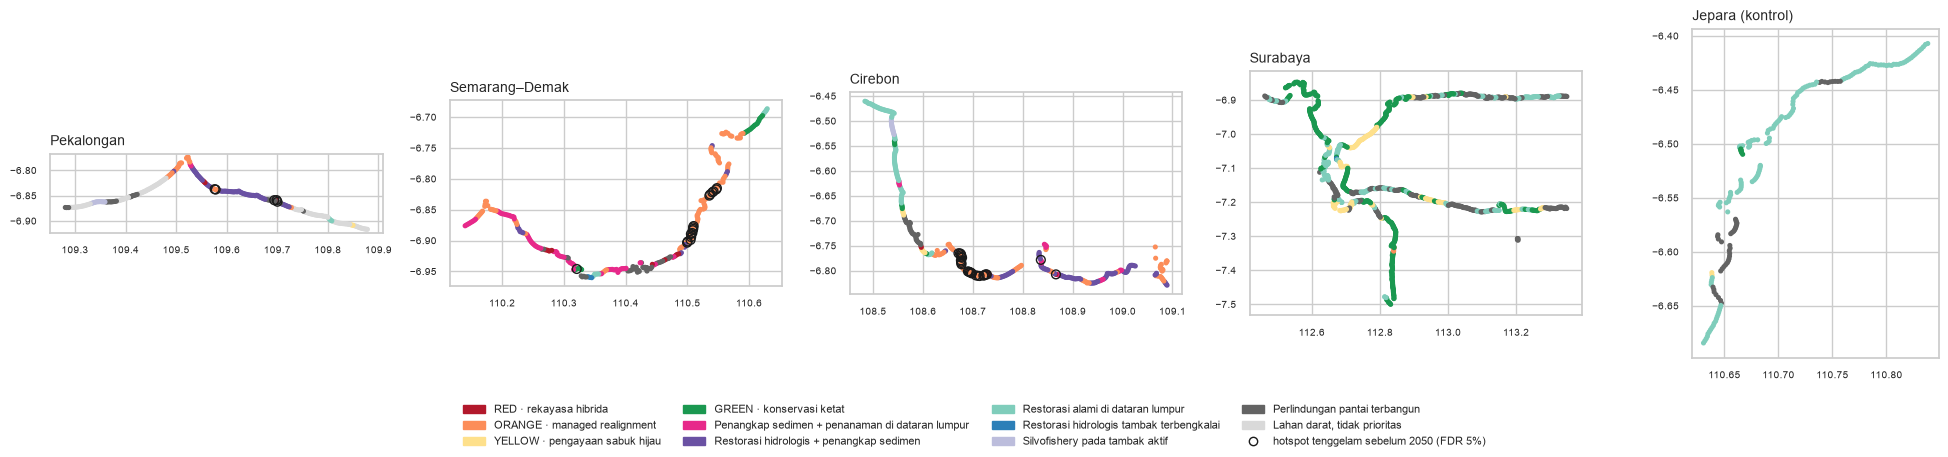

In [27]:
PRIOR = {r: k for k, r in enumerate(reversed(["RED · rekayasa hibrida", "ORANGE · managed realignment", "Penangkap sedimen + penanaman di dataran lumpur",
                                              "Restorasi hidrologis + penangkap sedimen", "YELLOW · pengayaan sabuk hijau",
                                              "Restorasi hidrologis tambak terbengkalai", "Restorasi alami di dataran lumpur",
                                              "Silvofishery pada tambak aktif", "GREEN · konservasi ketat",
                                              "Perlindungan pantai terbangun", "Lahan darat, tidak prioritas"]))}
KUNCI = {"RED · rekayasa hibrida"}
def kawasan(label, gap_m=1000, window=5, min_len=2):
    df = TR[["region_code", "cx", "cy"]].reset_index().assign(typ=label).sort_values(["region_code", "transek_id"])
    step = np.hypot(df.cx.diff(), df.cy.diff())
    df["run_id"] = ((df.region_code != df.region_code.shift()) | (step > gap_m)).cumsum()
    def smooth(typ):
        h = window // 2; out = []
        for k in range(len(typ)):
            if typ[k] in KUNCI:
                out.append(typ[k]); continue
            c = pd.Series(typ[max(0, k - h): k + h + 1]).value_counts()
            out.append(max(c[c == c.max()].index, key=PRIOR.get))
        return out
    def merge_short(typ):
        typ = list(typ)
        while True:
            blocks = []
            for k, c in enumerate(typ):
                if blocks and blocks[-1][2] == c: blocks[-1][1] = k + 1
                else: blocks.append([k, k + 1, c])
            short = [b for b in blocks if b[1] - b[0] < min_len and b[2] not in KUNCI]
            if len(blocks) == 1 or not short: return typ
            b = min(short, key=lambda x: x[1] - x[0]); i = blocks.index(b)
            nb_ = [blocks[j] for j in (i - 1, i + 1) if 0 <= j < len(blocks)]
            tgt = max(nb_, key=lambda x: (x[1] - x[0], PRIOR[x[2]]))
            typ[b[0]: b[1]] = [tgt[2]] * (b[1] - b[0])
    df["typ_smooth"] = df.groupby("run_id").typ.transform(lambda t: smooth(list(t)))
    df["typ_kawasan"] = df.groupby("run_id").typ_smooth.transform(merge_short)
    ch = (df.run_id != df.run_id.shift()) | (df.typ_kawasan != df.typ_kawasan.shift())
    df["kawasan_id"] = df.region_code + "_K" + ch.cumsum().astype(str).str.zfill(3)
    return df.set_index("transek_id").loc[IDS]
KAW = kawasan(REKOM)
TR["_P5"] = np.nan; TR.loc[IDS[iD], "_P5"] = P5
kaw = KAW.assign(pop=POP, P5=TR._P5.to_numpy(), RFI=RFI, hot=np.isin(IDS, IDS[iD][HOT]), ancaman=ANCAMAN).groupby("kawasan_id").agg(
    wilayah=("region_code", "first"), rekomendasi=("typ_kawasan", "first"), transek=("typ", "size"), pop=("pop", "sum"),
    P5_median=("P5", "median"), RFI_median=("RFI", "median"), hotspot=("hot", "sum"), ancaman_konversi=("ancaman", "mean"))
kaw["panjang_km"] = kaw.transek * 0.25
ks = kaw.groupby(["rekomendasi", "wilayah"]).panjang_km.sum().unstack(fill_value=0).reindex(index=URUT_REK, columns=REG, fill_value=0)
ks["TOTAL km"] = ks.sum(axis=1); ks["kawasan"] = kaw.groupby("rekomendasi").size().reindex(URUT_REK).fillna(0).astype(int)
display(tabel(ks.round(2), "09_kawasan_ringkas"))
tabel(kaw.round(3), "09_kawasan_prioritas")

WARNA_REK = {"RED · rekayasa hibrida": "#b2182b", "ORANGE · managed realignment": "#fc8d59",
             "YELLOW · pengayaan sabuk hijau": "#fee08b", "GREEN · konservasi ketat": "#1a9850",
             "Penangkap sedimen + penanaman di dataran lumpur": "#e7298a", "Restorasi hidrologis + penangkap sedimen": "#6a51a3",
             "Restorasi alami di dataran lumpur": "#7fcdbb", "Restorasi hidrologis tambak terbengkalai": "#2c7fb8",
             "Silvofishery pada tambak aktif": "#bcbddc", "Perlindungan pantai terbangun": "#636363", "Lahan darat, tidak prioritas": "#d9d9d9"}
fig, axs = plt.subplots(1, 5, figsize=(20, 4.6))
for a, r in zip(axs, REG):
    s = KAW[KAW.region_code == r]; t_ = TR.loc[s.index]
    a.scatter(t_.lon, t_.lat, c=s.typ_kawasan.map(WARNA_REK), s=7)
    hh = TR.loc[IDS[iD][HOT_V & (REG_D == r)]]
    a.scatter(hh.lon, hh.lat, facecolors="none", edgecolors="k", s=40, lw=1.0)
    a.set_title(REG_NAMA[r], loc="left", fontsize=10); a.set_aspect("equal"); a.tick_params(labelsize=7)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=c, label=k) for k, c in WARNA_REK.items()] + [plt.Line2D([], [], marker="o", mfc="none", mec="k", ls="", label="hotspot tenggelam sebelum 2050 (FDR 5%)")],
           loc="lower center", ncol=4, fontsize=8, frameon=False)
plt.tight_layout(rect=(0, 0.12, 1, 1)); simpan("09_peta_rekomendasi"); plt.show()

**Interpretasi.**

- **Hotspot horizontal (PERI panduan) tidak kokoh.** Dengan p permutasi dan FDR 5%, hanya **8 transek** lolos (CIR 4, SBY 4).
  Aturan lama (z > 1,96) menghasilkan 65, jadi hampir semuanya kemungkinan palsu akibat uji berganda. Lokasinya juga peka
  terhadap ambang deteksi (Bagian 10.1). Penyebabnya, P(Closed₅) rendah di mana-mana, sehingga PERI hampir tidak punya variasi
  yang bisa mengelompok. Hotspot ini dilaporkan sebagai **indikatif**.
- **Hotspot tenggelam (PERI vertikal) lebih bermakna.** Ada **46 transek** yang lolos FDR 5%: CIR 24, SEM 17, PKL 5, dan
  tidak ada di SBY. Di sinilah penduduk terbanyak tinggal di belakang mangrove yang kemungkinan tenggelam sebelum 2050. Indeks
  ini tidak bergantung pada ambang deteksi tepi, dan cukup stabil terhadap radius (irisan 0,69 dengan radius 1.500 m, 0,38
  dengan 750 m; pada 500 m sebagian besar transek tidak bertetangga). Layer ini dipakai sebagai overlay prioritas anggaran.
- **Kawasan**: panjang per rekomendasi:
  - GREEN 125 km (SBY 114);
  - Restorasi alami di dataran lumpur 119 km;
  - Perlindungan pantai terbangun 118 km;
  - **ORANGE 69 km** (SEM 31, CIR 29, PKL 8, SBY 1,5);
  - Restorasi hidrologis + penangkap sedimen 48 km (CIR 25, PKL 19);
  - YELLOW 42 km (SBY 37);
  - Penangkap sedimen + penanaman di dataran lumpur 26 km (SEM 20, CIR 6);
  - **RED 5,5 km dalam 9 ruas pendek** yang tetap tampil sebagai titik aksi.

## 10. Uji sensitivitas dan ketahanan

Ketahanan diukur dengan **irisan himpunan** (indeks Jaccard) transek yang paling penting untuk kebijakan (RED ∪ ORANGE,
hotspot, 10% PERI tertinggi) dan kesamaan kelas, bukan korelasi peringkat seluruh transek. Korelasi peringkat menyesatkan
di sini karena sebagian besar P(Closed) hampir nol, sehingga urutan di antara nilai-nilai itu tidak bermakna.

### 10.1 Ambang deteksi (36 skenario panduan)

τ_veg × τ_SAR × τ_built (3 × 4 × 3) di sekitar nilai terkalibrasi. Setiap skenario mengulang rantai Y → Kalman
(parameter tetap) → penghalang → P(Closed₅) → PERI → tipologi → hotspot.

In [28]:
jac = lambda a, b: (a & b).sum() / max((a | b).sum(), 1)
def tipologi_pusat(laut, ms, sens, psn):
    darat = ((ms <= PARAM["MS_DEKAT"]) & ~sens) | psn
    return np.select([laut & darat, laut & ~darat, ~laut & darat], ["RED", "ORANGE", "YELLOW"], "GREEN")
LAUT_D = LAUT_T[iD]
TIPE_PUSAT = tipologi_pusat(LAUT_D, MS_NOW, B_SENS[iD, -1], PSN[iD])
print(f"Kesamaan tipologi Monte Carlo vs nilai pusat: {np.mean(TIPE_PUSAT == TIPE):.1%}")
def rantai(tv, ts, tb):
    Yr, obs_ = deteksi(tv, ts, iD); Yc, _ = hampel(Yr)
    yth = np.stack([tepi_tahunan(Yc, y) for y in TAHUN], 1)
    yref = YREF.copy(); yd_ = pd.DataFrame(yth).ffill(axis=1).bfill(axis=1).to_numpy()
    yref[iD] = np.where(np.isfinite(yd_), yd_, YREF[iD])
    Bh, Bs = penghalang_keras(tb, yref)
    X_, P_ = filter_semua(Yc, MODEL_PILIH, PAR[MODEL_PILIH])
    mu5 = np.zeros(ND); v5 = np.zeros(ND)
    for r in REG:
        m = REG_D == r
        if m.any():
            a_, vv_, _, _, _, _ = ramal(MODEL_PILIH, PAR[MODEL_PILIH][r][0], X_[m, -1], P_[m, -1], 60)
            mu5[m], v5[m] = a_, vv_
    p5 = 1 - norm.cdf((Bh[iD, -1] - mu5) / np.sqrt(v5 + PARAM["SIGMA_B"] ** 2)); peri = p5 * np.log10(POP[iD] + 1)
    tipe = tipologi_pusat(LAUT_D, Bh[iD, -1] - X_[:, -1, 0], Bs[iD, -1], PSN[iD])
    _, _, hot, _, _ = gi_hotspot(peri, 1000, perm=999)
    return dict(p5=p5, peri=peri, tipe=tipe, hot=hot, obs=np.isfinite(Yc).mean())
t0 = time.time()
tv0, ts0 = PARAM["TAU_VEG"], PARAM["TAU_SAR"]
g_veg = sorted({round(max(0.2, tv0 - 0.1), 1), tv0, round(tv0 + 0.1, 1)}) if tv0 > 0.2 else [tv0, tv0 + 0.1, tv0 + 0.2]
g_sar = [ts0 - 1, ts0, ts0 + 1, ts0 + 2]
dasar = dict(p5=P5, peri=PERI, tipe=TIPE_PUSAT, hot=HOT)
top10 = PERI >= np.quantile(PERI, 0.9)
ro0 = np.isin(TIPE_PUSAT, ["RED", "ORANGE"])
SENS = []
for tv in g_veg:
    for ts in g_sar:
        for tb in [0.4, 0.5, 0.6]:
            r_ = rantai(tv, ts, tb)
            SENS.append(dict(tau_veg=tv, tau_sar=ts, tau_built=tb, tipologi_sama=np.mean(r_["tipe"] == dasar["tipe"]),
                             jaccard_RED_ORANGE=jac(np.isin(r_["tipe"], ["RED", "ORANGE"]), ro0), jaccard_hotspot=jac(r_["hot"], HOT),
                             jaccard_top10_PERI=jac(r_["peri"] >= np.quantile(r_["peri"], 0.9), top10), P5_gt_07=np.mean(r_["p5"] > 0.7), Y_terukur=r_["obs"]))
SENS = pd.DataFrame(SENS)
print(f"36 skenario dalam {time.time() - t0:.0f} s")
display(SENS.describe().loc[["min", "50%", "max"], ["tipologi_sama", "jaccard_RED_ORANGE", "jaccard_hotspot", "jaccard_top10_PERI", "P5_gt_07", "Y_terukur"]].round(3))
tabel(SENS.round(3), "10_sensitivitas_36")

Kesamaan tipologi Monte Carlo vs nilai pusat: 99.7%


36 skenario dalam 158 s


,tipologi_sama,jaccard_RED_ORANGE,jaccard_hotspot,jaccard_top10_PERI,P5_gt_07,Y_terukur
min,0.976,1.0,0.0,0.752,0.000,0.708
50%,0.985,1.0,0.0,0.878,0.000,0.818
max,1.000,1.0,0.0,1.000,0.001,0.869


,tau_veg,tau_sar,tau_built,tipologi_sama,jaccard_RED_ORANGE,jaccard_hotspot,jaccard_top10_PERI,P5_gt_07,Y_terukur
0,0.3,-18.0,0.4,0.988,1.0,0.0,0.917,0.000,0.869
1,0.3,-18.0,0.5,1.000,1.0,0.0,0.978,0.000,0.869
2,0.3,-18.0,0.6,0.984,1.0,0.0,0.804,0.000,0.869
3,0.3,-17.0,0.4,0.988,1.0,0.0,0.917,0.000,0.859
4,0.3,-17.0,0.5,1.000,1.0,0.0,0.978,0.000,0.859
5,0.3,-17.0,0.6,0.984,1.0,0.0,0.822,0.000,0.859
6,0.3,-16.0,0.4,0.985,1.0,0.0,0.897,0.000,0.827
7,0.3,-16.0,0.5,0.998,1.0,0.0,0.957,0.000,0.827
8,0.3,-16.0,0.6,0.983,1.0,0.0,0.822,0.000,0.827
9,0.3,-15.0,0.4,0.977,1.0,0.0,0.822,0.001,0.743


### 10.2 Ambang yang menentukan warna

Satu per satu: laju akresi $A$ (0,2 / **0,5** / 1,0 / 1,5 cm/th), kenaikan muka laut (0 / **0,39** / 0,5 cm/th), horizon tenggelam (2050 / **2100** / aturan lama defisit > 0), jarak penghalang dekat (250 / 500 / 1.000 m), dan batas atas
jendela hidroperiode (persentil 90 / 95 / 99). Setiap skenario mengulang tipologi Monte Carlo transek bermangrove dan
rekomendasi transek tanpa mangrove.

In [29]:
def rekom_skenario(akresi=A_, ms_dekat=PARAM["MS_DEKAT"], j_atas=JENDELA[1], slr=SLR_, tahun=PARAM["TGL_TAHUN"]):
    pdef = p_tenggelam(tahun, slr, akresi)
    amb = np.nan_to_num(MODAL / (tahun - 2026), nan=0.0)[iD][:, None]
    darat = ((ms_s <= ms_dekat) & ~B_SENS[iD, -1][:, None]) | PSN[iD][:, None]
    sub_ = SUBS_F[iD][:, None] + SIG_D[iD][:, None] * np.random.default_rng(8).standard_normal((ND, S))
    laut_ = ((sub_ + slr - akresi) >= amb) | (INUND_B[iD] > j_atas)[:, None]
    pk = np.stack([(laut_ & darat).mean(1), (laut_ & ~darat).mean(1), (~laut_ & darat).mean(1), (~laut_ & ~darat).mean(1)], 1)
    tipe = np.array(URUT_T)[pk.argmax(1)]
    rek = rekom_non(pdef > 0.5)
    rek[iD] = [NAMA_TIPE[t] for t in tipe]
    return tipe, rek
sk = []
jd = {q: np.quantile(depan, q) for q in [0.9, 0.95, 0.99]}
for nama, kw in [("akresi 0,2", dict(akresi=0.2)), ("akresi 0,5 (dasar)", {}), ("akresi 1,0", dict(akresi=1.0)), ("akresi 1,5", dict(akresi=1.5)),
                 ("tanpa kenaikan muka laut", dict(slr=0.0)), ("kenaikan muka laut 0,5", dict(slr=0.5)),
                 ("horizon tenggelam 2050", dict(tahun=2050)), ("aturan lama: defisit > 0", dict(tahun=np.inf)),
                 ("penghalang dekat 250 m", dict(ms_dekat=250)), ("penghalang dekat 1.000 m", dict(ms_dekat=1000)),
                 ("jendela atas P90", dict(j_atas=jd[0.9])), ("jendela atas P99", dict(j_atas=jd[0.99]))]:
    tipe_, rek_ = rekom_skenario(**kw)
    row = {"skenario": nama, **{t: int((tipe_ == t).sum()) for t in URUT_T}, "tipologi_sama": np.mean(tipe_ == TIPE),
           "jaccard_RED_ORANGE": jac(np.isin(tipe_, ["RED", "ORANGE"]), np.isin(TIPE, ["RED", "ORANGE"])),
           "rekomendasi_sama (semua transek)": np.mean(rek_ == REKOM),
           "penangkap sedimen (tanpa mangrove)": int(np.isin(rek_, REK_NONMANGROVE[:2]).sum())}
    sk.append(row)
tabel(pd.DataFrame(sk).set_index("skenario").round(3), "10_sensitivitas_warna")

,RED,ORANGE,YELLOW,GREEN,tipologi_sama,jaccard_RED_ORANGE,rekomendasi_sama (semua transek),penangkap sedimen (tanpa mangrove)
skenario,,,,,,,,
"akresi 0,2",23,261,144,492,0.970,0.905,0.970,354
"akresi 0,5 (dasar)",15,242,153,510,1.000,1.000,1.000,312
"akresi 1,0",13,195,155,557,0.947,0.809,0.965,279
"akresi 1,5",13,177,155,575,0.927,0.739,0.949,259
tanpa kenaikan muka laut,13,212,155,540,0.965,0.875,0.975,284
"kenaikan muka laut 0,5",21,252,147,500,0.983,0.941,0.986,329
horizon tenggelam 2050,13,155,155,597,0.903,0.654,0.932,241
aturan lama: defisit > 0,149,696,19,56,0.361,0.304,0.639,577
penghalang dekat 250 m,9,248,87,576,0.922,1.000,0.970,312


### 10.3 Parameter kawasan dan uji ulang efek total amblesan (laju tepi dan lebar)

In [30]:
kw_ = []
for win in [3, 5, 7]:
    for ml in [1, 2, 4]:
        k_ = kawasan(REKOM, window=win, min_len=ml)
        kw_.append(dict(jendela=win, panjang_min_transek=ml, sama_dengan_dasar=np.mean(k_.typ_kawasan.to_numpy() == KAW.typ_kawasan.to_numpy()),
                        kawasan=k_.kawasan_id.nunique()))
display(tabel(pd.DataFrame(kw_).pivot(index="jendela", columns="panjang_min_transek", values="sama_dengan_dasar").round(3), "10_sensitivitas_kawasan"))
uji = {}
for nama, mask in [("semua", np.ones(len(D6), bool)), ("tanpa multi-persilangan", TR.n_silang_pantai.to_numpy()[D6.i] <= 1),
                   ("tanpa PKL", D6.wilayah.to_numpy() != "PKL"), ("hanya amblesan terukur langsung (pantai)", D6.sumber.to_numpy() == "pantai")]:
    for resp, se in [("v_gmw", "se_v"), ("w_gmw", "se_w")]:
        t_, n_, _ = model_laju(D6[mask], resp, se, ["Subs", "Built"], B=499)
        uji[(resp, nama, n_)] = t_.loc["Subs", ["WLS γ", "WLS p (klaster)", "Huber γ", "P(γ>0) bootstrap", "WLS+FE γ", "WLS+FE p"]]
tabel(pd.DataFrame(uji).T.rename_axis(["respons", "uji", "n"]).round(3), "10_uji_ulang_penggerak")

panjang_min_transek,1,2,4
jendela,,,
3,0.897,0.915,0.898
5,0.981,1.000,0.953
7,0.933,0.940,0.921


,,,WLS γ,WLS p (klaster),Huber γ,P(γ>0) bootstrap,WLS+FE γ,WLS+FE p
respons,uji,n,,,,,,
v_gmw,semua,796,0.952,0.008,1.876,0.992,0.823,0.008
w_gmw,semua,920,-0.187,0.652,-0.780,0.242,-0.204,0.715
v_gmw,tanpa multi-persilangan,734,0.906,0.013,1.618,0.988,0.807,0.016
w_gmw,tanpa multi-persilangan,845,-0.171,0.688,-0.429,0.232,-0.032,0.952
v_gmw,tanpa PKL,771,1.082,0.003,2.028,0.966,1.031,0.001
w_gmw,tanpa PKL,875,-0.135,0.798,-0.877,0.238,-0.417,0.550
v_gmw,hanya amblesan terukur langsung (pantai),356,0.332,0.000,0.755,0.972,0.476,0.054
w_gmw,hanya amblesan terukur langsung (pantai),416,-0.005,0.993,0.211,0.551,-1.228,0.010


**Interpretasi.**

- **Ambang deteksi (36 skenario)**: tipologi ≥ 97,6% sama, himpunan RED ∪ ORANGE **identik** di semua skenario, dan 10% PERI
  tertinggi beririsan ≥ 0,75. **Hotspot PERI horizontal tidak kokoh** (irisan 0 di semua skenario). Hotspot tenggelam tidak
  bergantung pada deteksi tepi.
- **Ambang warna**: dengan sumbu laut berbasis waktu tenggelam, tipologi **tidak lagi bergantung kuat pada asumsi akresi**.
  Pada akresi 0,2–1,5 cm/th, RED 13–23 dan ORANGE 177–261, kesamaan tipologi 93–97%, dan irisan RED ∪ ORANGE 0,74–0,91.
  Kenaikan muka laut 0–0,5 cm/th: ORANGE 212–252, irisan ≥ 0,88. Pilihan yang paling berpengaruh sekarang adalah **horizon
  perencanaan**: dengan horizon 2050, ORANGE turun ke 155 (irisan 0,65). Ini pilihan kebijakan, bukan parameter yang tidak
  pasti. Jarak penghalang dekat (250/1.000 m) mengubah 8–14% kelas. Batas atas jendela hidroperiode tidak berpengaruh.
- **Aturan lama (cukup ada defisit)** memberi RED 149 dan ORANGE 696, karena hampir semua transek SBY ikut terhitung setelah
  kenaikan muka laut dimasukkan (irisan 0,30). Aturan itu peka terhadap perubahan kecil pada defisit, sehingga tidak dipakai.
- **Kawasan**: jendela penghalusan 3–7 dan panjang minimum 1–4 transek menghasilkan peta 90–100% sama.
- **Efek amblesan pada tepi laut** bertahan di semua uji ulang: +0,91 tanpa multi-persilangan, +1,08 tanpa PKL, +0,95 dengan
  kontrol dataran lumpur, dan +0,33 (searah) bila hanya memakai amblesan terukur langsung. Efeknya pada lebar tetap nol.

## 11. Sintesis dan ekspor

### 11.1 Ringkasan angka

In [31]:
S_ = {}
S_["transek total / domain analisis tepi"] = f"{N} / {ND} (versi WorldCover 2021 saja: {ADA_WC.sum()})"
S_["validasi tepi 2025 vs GMW 2025"] = f"median |ΔY| {val[2]['selisih_median_m']:.0f} m, {val[2]['dalam_30m']:.0%} dalam 30 m, ρ = {val[2]['spearman']:.2f}"
S_["dinamika transek (ekspansi / kehilangan / stabil)"] = " / ".join(str(int((DINAMIKA == k).sum())) for k in ["ekspansi 2021–2025", "kehilangan 2021–2025", "stabil"])
S_["model nowcast terpilih"] = MODEL_PILIH
S_["CRPS t+12 model terpilih vs persistensi (m)"] = f"{skor.loc[(12, MODEL_PILIH), 'CRPS']:.1f} vs {skor.loc[(12, 'Persistensi'), 'CRPS']:.1f}"
kv = koef.loc[("tepi laut GMW (+ = mundur)", "efek total", "Subs")]
S_["efek total amblesan pada laju tepi laut (m/th per SD, + = mundur)"] = f"WLS {kv['WLS γ']:+.2f} (p klaster {kv['WLS p (klaster)']:.3f}); Huber P(γ>0) {kv['P(γ>0) bootstrap']:.2f}; dalam wilayah {kv['WLS+FE γ']:+.2f} (p {kv['WLS+FE p']:.3f})"
ke = koef.loc[("lebar sabuk GMW (− = menyempit)", "efek total", "Subs")]
S_["efek total amblesan pada laju lebar sabuk (m/th per SD)"] = f"WLS {ke['WLS γ']:+.2f} (p klaster {ke['WLS p (klaster)']:.3f}); Huber P(γ>0) {ke['P(γ>0) bootstrap']:.2f}; dalam wilayah {ke['WLS+FE γ']:+.2f}"
S_["transek domain dengan P(Closed₅) > 0,7 (penghalang keras / fungsional)"] = f"{np.mean(P5 > 0.7):.1%} / {np.mean(P5_FUNC > 0.7):.1%}"
S_["transek dengan defisit vertikal P(D > 0) > 0,5 (semua / domain)"] = f"{np.mean(P_DEF > 0.5):.0%} / {np.mean(P_DEF[iD] > 0.5):.0%}"
S_["tipologi RED / ORANGE / YELLOW / GREEN"] = " / ".join(str(int((TIPE == t).sum())) for t in URUT_T)
S_["transek domain dengan P(tenggelam sebelum 2050 / 2100) > 0,5"] = f"{np.mean(P_TGL50[iD] > 0.5):.0%} / {np.mean(P_TGL[iD] > 0.5):.0%}"
kl = koef.loc[("tepi laut GMW (+ = mundur)", "kontrol sedimen", "Subs")]
S_["efek amblesan pada tepi laut setelah kontrol dataran lumpur"] = f"WLS {kl['WLS γ']:+.2f} (p klaster {kl['WLS p (klaster)']:.3f}); dalam wilayah {kl['WLS+FE γ']:+.2f}"
S_["hotspot PERI (FDR 5%)"] = f"{HOT.sum()} transek"
S_["hotspot PERI vertikal (FDR 5%)"] = f"{HOT_V.sum()} transek"
S_["rekomendasi pantai tanpa mangrove"] = "; ".join(f"{k}: {int((REKOM == k).sum())}" for k in URUT_REK[4:])
S_["overlay ancaman konversi"] = f"{ANCAMAN.sum()} transek"
tabel(pd.Series(S_, name="nilai").to_frame(), "11_ringkasan")

,nilai
transek total / domain analisis tepi,2365 / 920 (versi WorldCover 2021 saja: 702)
validasi tepi 2025 vs GMW 2025,"median |ΔY| 20 m, 74% dalam 30 m, ρ = 0.88"
dinamika transek (ekspansi / kehilangan / stabil),424 / 84 / 412
model nowcast terpilih,M2 tren + AR(1)
CRPS t+12 model terpilih vs persistensi (m),32.6 vs 36.9
"efek total amblesan pada laju tepi laut (m/th per SD, + = mundur)",WLS +0.95 (p klaster 0.008); Huber P(γ>0) 0.98...
efek total amblesan pada laju lebar sabuk (m/th per SD),WLS -0.19 (p klaster 0.652); Huber P(γ>0) 0.20...
"transek domain dengan P(Closed₅) > 0,7 (penghalang keras / fungsional)",0.0% / 0.7%
"transek dengan defisit vertikal P(D > 0) > 0,5 (semua / domain)",77% / 92%
tipologi RED / ORANGE / YELLOW / GREEN,15 / 242 / 153 / 510


### 11.2 Jawaban atas pertanyaan penelitian

1. **Di mana mangrove berubah?** Secara bersih, mangrove Pantura **bertambah**: 424 transek berekspansi dan 84 kehilangan
   tegakan (2021–2025), terkonfirmasi Sentinel. Pertumbuhan terjadi ke arah darat dan ke celah sabuk. Tepi laut rata-rata
   diam, tetapi **mundur di zona amblesan tinggi**. Kehilangan total paling sering terjadi di Semarang–Demak (17 per 1.000
   transek-tahun). Nowcast Agustus 2026 menandai 44 transek *kemungkinan hilang*. Untuk 6–12 bulan, model state-space dengan
   radar multi-orbit meramal posisi tepi **lebih baik daripada posisi tetap** (CRPS t+12 32,6 vs 36,9 m).
2. **Apa penggeraknya?** **Amblesan** mendorong tepi laut mundur (+0,95 m/th per SD, p = 0,008, bertahan di dalam wilayah dan
   di semua uji ulang) dan menaikkan peluang kehilangan total (OR 1,37). **Kawasan terbangun** membatasi pertumbuhan ke darat
   (−1,4 m/th per SD) dan menaikkan peluang kehilangan total (OR 1,47). Kedua tekanan bekerja dari arah berlawanan: inilah
   coastal squeeze.
3. **Di mana ruang akan habis?** **Secara horizontal belum dalam 5 tahun** (tidak ada P(Closed₅) > 0,7), tetapi bila tambak
   berpematang dihitung sebagai penghalang, ruang gerak nyata hanya 180–370 m. **Secara vertikal sudah berjalan**: tanah turun
   ditambah laut naik melampaui akresi pada 91–99% transek bermangrove PKL, SEM, dan CIR, dan tegakannya diperkirakan tenggelam
   sebelum 2100 pada 77–91% transek (median 2040 PKL, 2049 CIR, 2061 SEM). Mangrove SBY tidak terancam tenggelam sebelum 2100
   karena tunggang pasutnya besar dan defisitnya ringan.
4. **Intervensi apa?** Lihat layer rekomendasi. Prioritas program:
   - ORANGE (242 transek, 69 km di SEM, CIR, PKL: buka pematang di belakang tegakan);
   - restorasi hidrologis + penangkap sedimen di tambak terbengkalai CIR dan PKL (48 km);
   - penangkap sedimen + penanaman di dataran lumpur SEM (26 km);
   - 15 titik RED (5,5 km) untuk rekayasa hibrida;
   - 46 transek hotspot tenggelam (CIR, SEM, PKL) sebagai prioritas anggaran;
   - pengendalian konversi di 221 transek berancaman, terutama SBY.

### 11.3 Ekspor untuk dashboard

| Berkas (`analisis/hasil/dashboard/`) | Isi |
|---|---|
| `master_transek_pantura.csv` | format panduan Bagian 9 + kolom baru (dinamika, defisit, peluang, keyakinan, overlay) |
| `transek.geojson` | garis transek (ujung laut → ujung darat) dengan semua atribut transek |
| `segmen_lahan.geojson` | segmen sepanjang transek per label tutupan lahan (layer 2) dan kategori peluang |
| `segmen_dinamika.geojson` | segmen per status dinamika mangrove 2021→2025 (layer 1) |
| `kawasan.geojson` | kawasan prioritas sebagai garis sepanjang pantai |
| `pantura_mangrove.gpkg` | keempat layer di atas dalam satu GeoPackage |
| `kamus_label.csv` | kode, nama, warna, arti, dasar data, dan teks rekomendasi setiap label |

In [32]:
from shapely.geometry import LineString
LON, LAT = md.koordinat_titik(TR)
def isi(nilai_d, isi_=np.nan):
    a = np.full(N, isi_, dtype=float if isinstance(isi_, float) else object); a[iD] = nilai_d; return a
M = pd.DataFrame({
    "transek_id": IDS, "wilayah": REG_I, "lat": TR.lat.round(6).to_numpy(), "lon": TR.lon.round(6).to_numpy(),
    "status_peta": STATUS_PETA, "domain_mangrove": DOMAIN, "dinamika": DINAMIKA,
    "Y_now_m": isi(MU_T), "v_edge_m_yr": isi(V_KF), "v_gmw_m_yr": V_GMW[:, 0], "w_gmw_m_yr": W_GMW[:, 0],
    "MS_current_m": isi(MS_NOW), "MS_uncertainty": isi(SD_MU), "MS_pred_6m": isi(B_HARD[iD, -1] - FC[6][0]), "MS_pred_12m": isi(B_HARD[iD, -1] - FC[12][0]),
    "B_hard_tersensor": B_SENS[:, -1], "jarak_penghalang_m": JARAK_B, "kelas_penghalang": KELAS_B,
    "opp_space_m": OPP, "peluang_siap_m": OPP_SIAP, "perlu_pengaturan_air_m": OPP_AIR, "silvofishery_m": OPP_SILVO, "lumpur_depan_m": LUMPUR_DEPAN,
    "v_closure_m_yr": isi(V_KF), "P_closed_1yr": isi(P1), "P_closed_5yr": isi(P5), "P_closed_5yr_fungsional": isi(P5_FUNC), "P_closed_5yr_gmw": isi(P5_GMW),
    "lahan_utama": LAHAN_UTAMA,
    "subs_cm_yr": SUBS_F, "subs_sumber": SUMBER_SUBS, "subs_sigma": SIG_U, "defisit_vertikal_cm_yr": DEF, "P_defisit": P_DEF, "kelas_defisit": KELAS_DEF,
    "modal_elevasi_cm": MODAL, "tahun_tenggelam_median": np.where(ada_t, np.minimum(TAHUN_TGL, 2200), np.nan), "P_tenggelam_2050": P_TGL50, "P_tenggelam_2100": P_TGL,
    "RFI_score": RFI, "PERI_index": isi(PERI), "Gi_Zscore": isi(GI_Z), "Gi_p": isi(GI_P), "hotspot": isi(HOT.astype(float)) == 1,
    "PERI_vertikal": isi(PERI_V), "hotspot_tenggelam": isi(HOT_V.astype(float)) == 1,
    "n_silang_pantai": TR.n_silang_pantai.to_numpy(), "PSN_overlap": PSN,
    "Intervention_Type": isi(TIPE, ""), "keyakinan_tipologi": YAKIN_ALL,
    **{f"P_{t}": isi(PK[:, k]) for k, t in enumerate(URUT_T)},
    "rekomendasi": REKOM, "ancaman_konversi": ANCAMAN, "kemungkinan_hilang": HILANG_NOW,
    "kawasan_id": KAW.kawasan_id.to_numpy(), "typ_kawasan": KAW.typ_kawasan.to_numpy(), "pop_2026": POP,
})
M.to_csv(DASH / "master_transek_pantura.csv", index=False)
geo_tr = gpd.GeoDataFrame(M, geometry=[LineString([(LON[i, 0], LAT[i, 0]), (LON[i, -1], LAT[i, -1])]) for i in range(N)], crs=4326)
geo_tr.to_file(DASH / "transek.geojson", driver="GeoJSON")

def segmen(L, nama_kolom, lewati=()):
    rows = []
    for i in range(N):
        lab = L[i]; batas = np.flatnonzero(np.r_[True, lab[1:] != lab[:-1], True])
        for a, b in zip(batas[:-1], batas[1:]):
            if lab[a] in lewati:
                continue
            j1 = min(b, P - 1)
            rows.append((IDS[i], REG_I[i], lab[a], int(DIST[a]), int(DIST[j1]), (b - a) * STEP,
                         LineString([(round(LON[i, a], 6), round(LAT[i, a], 6)), (round(LON[i, j1], 6), round(LAT[i, j1], 6))])))
    return gpd.GeoDataFrame(pd.DataFrame(rows, columns=["transek_id", "wilayah", nama_kolom, "dari_m", "sampai_m", "panjang_m", "geometry"]), crs=4326)
PELUANG = np.select([SIAP, PERLU_AIR, SILVO], ["siap", "perlu pengaturan air", "silvofishery"], "").astype(object)
seg_l = segmen(np.char.add(np.char.add(LAHAN.astype(str), "|"), PELUANG.astype(str)), "kode")
seg_l[["tutupan_lahan", "peluang"]] = seg_l.kode.str.split("|", expand=True); seg_l = seg_l.drop(columns="kode")
seg_l.to_file(DASH / "segmen_lahan.geojson", driver="GeoJSON")
seg_d = segmen(DIN_TITIK.astype(str), "dinamika", lewati=("tidak pernah",))
seg_d.to_file(DASH / "segmen_dinamika.geojson", driver="GeoJSON")
kw_rows = []
for kid, g_ in KAW.assign(lon=TR.lon.to_numpy(), lat=TR.lat.to_numpy()).groupby("kawasan_id", sort=False):
    pts = list(zip(g_.lon.round(6), g_.lat.round(6)))
    kw_rows.append(dict(kawasan_id=kid, geometry=LineString(pts if len(pts) > 1 else pts * 2)))
geo_kw = gpd.GeoDataFrame(pd.DataFrame(kw_rows).merge(kaw.reset_index(), on="kawasan_id"), crs=4326)
geo_kw.to_file(DASH / "kawasan.geojson", driver="GeoJSON")
gpk = DASH / "pantura_mangrove.gpkg"
if gpk.exists(): gpk.unlink()
for nama, g_ in [("transek", geo_tr), ("segmen_lahan", seg_l), ("segmen_dinamika", seg_d), ("kawasan", geo_kw)]:
    g_.to_file(gpk, layer=nama, driver="GPKG")

KAMUS = [
    ("1 dinamika", "stabil", "#1a9850", "bermangrove GMW 2021 dan 2025", "GMW v4.1.12", "pertahankan, pantau nowcast"),
    ("1 dinamika", "ekspansi", "#66bd63", "mangrove baru 2021→2025 (terkonfirmasi NDVI/VH naik)", "GMW + Sentinel", "lindungi tegakan muda; jadikan contoh keberhasilan"),
    ("1 dinamika", "hilang", "#d73027", "mangrove 2021 yang hilang di 2025 (terkonfirmasi NDVI/VH turun)", "GMW + Sentinel", "selidiki penyebab: tenggelam, abrasi, atau konversi"),
    ("1 dinamika", "hilang sebelum 2021", "#f46d43", "bermangrove 2000–2020, tidak lagi sejak 2021", "GMW", "kandidat pemulihan bila tekanan memungkinkan"),
    ("2 lahan", "mangrove", "#1a9850", "tegakan mangrove GMW 2025", "GMW", "-"),
    ("2 lahan", "dataran lumpur", "#c7eae5", "lumpur/air dangkal yang mengikuti pasang di depan pantai", "S1 genangan + tide coupling", "kolonisasi alami / penanaman"),
    ("2 lahan", "tambak terhubung pasang", "#2c7fb8", "air tambak mengikuti pasang: pematang terbuka/jebol (indikasi)", "S1 tide coupling", "restorasi hidrologis"),
    ("2 lahan", "tambak mulai bervegetasi", "#41b6c4", "tambak tertutup yang mulai ditumbuhi vegetasi (indikasi)", "S2 NDVI", "percepat suksesi alami"),
    ("2 lahan", "tambak tergenang", "#a6bddb", "tambak jarang dikuras dan tertutup pematang (indikasi tidak dikelola)", "S2 MNDWI bulanan", "verifikasi status; restorasi hidrologis bila terbengkalai"),
    ("2 lahan", "tambak aktif", "#8c6bb1", "tambak dikuras berkala, tertutup pematang", "S2 MNDWI bulanan", "silvofishery / wanamina"),
    ("2 lahan", "sawah", "#e49635", "pertanian", "Dynamic World 2026", "-"),
    ("2 lahan", "vegetasi darat", "#397d49", "pohon/semak non-mangrove", "Dynamic World 2026", "-"),
    ("2 lahan", "lahan terbuka", "#a59b8f", "tanah terbuka", "Dynamic World 2026", "-"),
    ("2 lahan", "terbangun", "#636363", "terbangun 2025 dan 2026", "Dynamic World", "-"),
    ("2 lahan", "terbangun baru", "#e31a1c", "terbangun 2025–2026, tidak 2021–2022 (pembukaan lahan)", "Dynamic World", "pengendalian tata ruang"),
    ("2 lahan", "perairan", "#419bdf", "laut, sungai, air lain", "Dynamic World", "-"),
    ("2 peluang", "siap", "#7fcdbb", "lahan peluang dengan genangan dalam jendela hidroperiode", "S1 genangan", "bisa ditanami/dibuka segera"),
    ("2 peluang", "perlu pengaturan air", "#2c7fb8", "tambak non-aktif dengan genangan di luar jendela", "S1 genangan", "atur ulang tata air sebelum penanaman"),
    ("2 peluang", "silvofishery", "#8c6bb1", "tambak aktif", "S2 MNDWI", "wanamina tanpa menghentikan produksi"),
    ("3 tekanan", "defisit vertikal", "-", "amblesan + kenaikan muka laut − akresi (cm/th); kelas ≤0, 0–1, 1–3, >3", "InSAR 2017–2023 + altimetri", "-"),
    ("3 tekanan", "tahun tenggelam", "-", "setengah tunggang pasut / defisit vertikal (median Monte Carlo); 2200 = tidak tenggelam sebelum 2200", "InSAR + EOT20", "-"),
    ("3 tekanan", "jarak penghalang", "-", "jarak penghalang keras di belakang tepi/garis pantai", "OSM + Dynamic World", "-"),
] + [("4 rekomendasi", k, WARNA_REK[k], a, b, c) for k, a, b, c in [
    ("RED · rekayasa hibrida", "bermangrove; terancam tenggelam sebelum 2100 dan penghalang dekat", "tipologi Monte Carlo", "struktur penangkap sedimen permeabel sebelum revegetasi"),
    ("ORANGE · managed realignment", "bermangrove; terancam tenggelam sebelum 2100, ruang darat lapang", "tipologi Monte Carlo", "buka pematang tambak di belakang tegakan"),
    ("YELLOW · pengayaan sabuk hijau", "bermangrove; penghalang dekat, tidak terancam tenggelam sebelum 2100", "tipologi Monte Carlo", "penanaman pengayaan jenis berakar kokoh"),
    ("GREEN · konservasi ketat", "bermangrove; tekanan rendah", "tipologi Monte Carlo", "perlindungan kawasan inti + pemantauan"),
    ("Penangkap sedimen + penanaman di dataran lumpur", "tanpa mangrove; dataran lumpur, terancam tenggelam sebelum 2100", "aturan 8.3", "penangkap sedimen permeabel dulu, penanaman kemudian"),
    ("Restorasi hidrologis + penangkap sedimen", "tanpa mangrove; tambak terbengkalai, terancam tenggelam sebelum 2100", "aturan 8.3", "buka pematang bertahap + perangkap sedimen"),
    ("Restorasi alami di dataran lumpur", "tanpa mangrove; dataran lumpur, tidak terancam tenggelam", "aturan 8.3", "kolonisasi alami / penanaman di lumpur"),
    ("Restorasi hidrologis tambak terbengkalai", "tanpa mangrove; tambak mayoritas tidak dikelola, tidak terancam tenggelam", "aturan 8.3", "buka pematang, pulihkan pasang-surut"),
    ("Silvofishery pada tambak aktif", "tanpa mangrove; tambak aktif", "aturan 8.3", "wanamina"),
    ("Perlindungan pantai terbangun", "tanpa mangrove; pantai terbangun", "aturan 8.3", "perlindungan pantai, bukan restorasi"),
    ("Lahan darat, tidak prioritas", "tanpa mangrove; sawah/kebun/permukiman", "aturan 8.3", "-")]] + [
    ("overlay", "hotspot PERI", "#969696", "klaster keterpaparan ruang tertutup (Gi*, FDR 5%; indikatif, tidak kokoh)", "Bagian 9.1", "-"),
    ("overlay", "hotspot tenggelam", "#000000", "klaster penduduk terpapar mangrove yang mungkin tenggelam sebelum 2050 (Gi*, FDR 5%)", "Bagian 9.1", "prioritas anggaran"),
    ("overlay", "ancaman konversi", "#e31a1c", "bangunan baru atau mangrove menjadi bangunan dalam 1 km", "Dynamic World + GMW", "pengawasan tata ruang"),
    ("overlay", "kemungkinan hilang", "#d73027", "6 bulan teramati terakhir mayoritas tanpa mangrove", "nowcast Sentinel", "cek lapangan segera")]
pd.DataFrame(KAMUS, columns=["layer", "label", "warna", "arti", "dasar_data", "rekomendasi"]).to_csv(DASH / "kamus_label.csv", index=False)
pd.DataFrame(Y, index=IDS[iD], columns=BULAN.astype(str)).to_parquet(md.TUR / "Y_bulanan.parquet")
print("berkas dashboard:", sorted(f.name for f in DASH.iterdir()))
print(f"segmen lahan: {len(seg_l):,}; segmen dinamika: {len(seg_d):,}; kawasan: {len(geo_kw)}")

berkas dashboard: ['kamus_label.csv', 'kawasan.geojson', 'master_transek_pantura.csv', 'pantura_mangrove.gpkg', 'segmen_dinamika.geojson', 'segmen_lahan.geojson', 'transek.geojson']
segmen lahan: 115,739; segmen dinamika: 8,247; kawasan: 259


### 11.4 Keterbatasan

| Keterbatasan | Dampak | Arah bias / penanganan |
|---|---|---|
| Laju akresi mangrove diasumsikan 0,5 cm/th (literatur Pb-210 Indonesia 0,2–0,56 cm/th; belum ada pengukuran di lantai mangrove Pantura) | dengan sumbu laut berbasis waktu tenggelam, pengaruhnya kecil (RED 13–23, ORANGE 177–261) | uji 0,2–1,5 di Bagian 10.2; nilai dasar di ujung atas rentang literatur, sehingga defisit cenderung diremehkan |
| Horizon perencanaan 2100 untuk tekanan laut | horizon 2050 menurunkan ORANGE dari 242 ke 155 | pilihan kebijakan; keduanya dilaporkan, dan P(tenggelam sebelum 2050) tersedia per transek |
| Deteksi tepi bulanan berderau (σ_η 16–59 m/bulan) | laju per transek dari Sentinel tidak signifikan | laju jangka panjang dari GMW; Sentinel untuk nowcast |
| GMW 30 m dan sebagian artefak di PKL | laju tepi terkuantisasi 30 m; ekspansi PKL terkonfirmasi lemah | Theil–Sen, konfirmasi Sentinel, uji ulang tanpa PKL |
| Amblesan InSAR 2017–2023, diremehkan di titik ekstrem (PKL −9,2 vs GNSS −11,6) | efek amblesan cenderung terlalu kecil | SIMEX menaikkan efek 12% |
| Status tambak dari MNDWI bulanan, belum divalidasi lapangan | pengeringan singkat bisa terlewat; akurasi label belum diketahui | label dan rekomendasi tambak *indikatif*; verifikasi lokasi sebelum implementasi |
| Kenaikan muka laut satu nilai regional (0,39 cm/th, 1993–2015) | percepatan kenaikan muka laut ke depan tidak dimodelkan | uji 0–0,5 cm/th di Bagian 10.2; waktu tenggelam cenderung terlalu lama |
| Akresi seragam, tanpa data sedimen tersuspensi per lokasi | lokasi dekat muara berlumpur bisa lebih tahan daripada perkiraan | dataran lumpur sebagai proksi kontrol di Bagian 6; skenario akresi 0,2–1,5 |
| Waktu tenggelam = setengah tunggang pasut / defisit | tidak memodelkan umpan balik akresi dan elevasi awal tegakan | dilaporkan sebagai orde besar, bukan tahun pasti |
| Penghalang > 3,5 km tidak teramati | P(Closed) batas atas | dilaporkan sebagai batas atas |
| Hotspot tidak kokoh | tidak ada klaster keterpaparan yang stabil | tidak dipakai untuk prioritas; dilaporkan indikatif |
| Transek hanya 500 m ke laut | kehilangan historis di pantai yang sudah mundur jauh (Sayung) tidak terukur | dinyatakan; kelas "hilang sebelum 2021" hanya mencakup jangkauan transek |

**Rujukan defisit vertikal (Bagian 6–7)**

- Gemilang, W.A., dkk. (2017). Laju sedimentasi di perairan Brebes, Jawa Tengah menggunakan metode isotop ²¹⁰Pb. *Jurnal Geologi Kelautan*.
- Kismawardhani, R.A., dkk. (2018). Sea level rise in the Java Sea based on altimetry satellites data over 1993–2015. *IOP Conf. Ser.: Earth Environ. Sci.* 165, 012006. doi:10.1088/1755-1315/165/1/012006
- Lovelock, C.E., dkk. (2015). The vulnerability of Indo-Pacific mangrove forests to sea-level rise. *Nature* 526, 559–563. doi:10.1038/nature15538
- Murdiyarso, D., Hanggara, B.B., Lubis, A.A. (2018). Sedimentation and soil carbon accumulation in degraded mangrove forests of North Sumatra, Indonesia. *bioRxiv*. doi:10.1101/325191
- Saintilan, N., dkk. (2020). Thresholds of mangrove survival under rapid sea level rise. *Science* 368, 1118–1121. doi:10.1126/science.aba2656
- Saintilan, N., dkk. (2023). Widespread retreat of coastal habitat is likely at warming levels above 1.5 °C. *Nature* 621, 112–119. doi:10.1038/s41586-023-06448-z
- Triana, K., Wahyudi, A.J. (2020). Sea level rise in Indonesia: the drivers and the combined impacts from land subsidence. *ASEAN J. Sci. Technol. Dev.* 37. doi:10.29037/ajstd.627
- Sidik, F., Neil, D., Lovelock, C.E. (2016). Effect of high sedimentation rates on surface sediment dynamics and mangrove growth in the Porong River, Indonesia. *Marine Pollution Bulletin* 107, 355–363. doi:10.1016/j.marpolbul.2016.02.048
- van Bijsterveldt, C.E.J., dkk. (2020). How to restore mangroves for greenbelt creation along eroding coasts with abandoned aquaculture ponds. *Estuar. Coast. Shelf Sci.* 235, 106576.
- van Bijsterveldt, C.E.J., dkk. (2023). Subsidence reveals potential impacts of future sea level rise on inhabited mangrove coasts. *Nature Sustainability* 6, 1565–1577. doi:10.1038/s41893-023-01226-1
